# 창원국가산단 업종별 산업·고용 진단: 분석 근거본

2022년 1분기~2026년 2분기 KICOX 생산·고용 자료로 10개 제조업종의 상태·규모·시간을 분석하고, 이를 선제점검 단계분류(Triage) 규칙으로 묶어 분기별 점검 단계를 정한다. 결과는 업종 단위 관측 자료의 확인 순서이며 기업별 원인이나 위기 판정으로 확대하지 않는다.

**해석 원칙.** 생산은 명목 금액이고 가격효과가 섞여 있다. 외부자료는 판정을 바꾸지 않고 확인 질문만 보강한다. 분석 판정과 담당자의 행정 판단은 구분한다.

| 단계 | 질문 | 역할 |
|---|---|---|
| **Q1 상태** | 같은 고용 변화라도 생산 방향은 다른가? | 생산·고용 국면 분류 |
| **Q2 규모** | 고용 변화는 어느 업종에 몰려 있는가? | 인원·비중·기여 |
| **Q3 시간** | 그 국면이 이어지는가, 바뀌는가? | 지속·전환 |
| **Triage** | 이번 분기에 무엇을 먼저 확인할까? | 관찰·추가확인·우선점검 |

Q1~Q3를 차례로 본 뒤 Triage에서 세 결과를 한 규칙으로 묶는다. 다기준 범주분류(ELECTRE TRI-B)와 파라미터 민감도 분석(SMAA-TRI)은 추가확인 사례만 다시 보는 보조모형이다. 본문에는 결과를 먼저 두고 세부 검증은 Appendix에 둔다.

**자료 사용 원칙.** 저장소에 이미 계산된 산출물을 불러와 쓴다. 새로 계산한 값이 기존 값과 다르면 덮어쓰지 않는다.

## 분석 대상과 범위

| 항목 | 내용 |
|---|---|
| 기간 | 본 분석 2022년 1분기~2026년 2분기(18분기), 참고기간 2018년 1분기~2026년 2분기(34분기) |
| 업종 | 기계·전기전자·운송장비·철강·음식료·석유화학·목재종이·비금속·기타·섬유의복(10개) |
| 분석단위 | 업종×분기. 본 분석 180행 |
| 핵심 데이터 | KICOX 업종별 명목 생산액(억원)·고용(명). 연간보정본 우선 |
| 보조 데이터 | PPI·EIS(교차확인), 수출입·전력·BSI·노동이동·공장등록·고용24(맥락) |

```text
Data 구축·QA(§2) → EDA(§3)
  → Q1 상태(§4) → Q2 규모(§5) → Q3 시간(§6) → 통합(§7)
  → Triage 주모형: 180행 전체 판정(§8·§9)
  → ELECTRE TRI-B / SMAA-TRI 보조모형: 추가확인 35행만 재검토(§8·§12)
  → 검증(§10) → 외부근거(External Evidence, §11)
  → 담당자 확인·지원연계(§12·§13)
```

## 해석 원칙

1. 관찰 자료다. KICOX 분기 집계를 그대로 읽는다.
2. 인과가 아니다. 생산과 고용이 함께 움직여도 한쪽을 다른 쪽의 원인으로 쓰지 않는다.
3. 생산은 명목 금액이다. 생산 증가를 물량 증가로 읽지 않는다.
4. 업종 단위다. 업종 결과를 개별 기업의 상태로 옮기지 않는다.
5. 외부근거는 판정을 바꾸지 않는다. 확인 질문과 맥락만 보강한다.
6. 분석 판정과 행정 판단은 다르다. 단계는 확인 순서이고 지원 여부는 담당자가 정한다.

## 기법 사용 상태

| 기법 | 상태 | 위치 |
|---|---|---|
| Q1 국면 분류(S1~S4, 중립구간 ±0.5·1·2%) | 수행 | §4, App D |
| Q2 증감 인원·비중·기여율·비례배분 기준선 | 수행 | §5 |
| Q3 지속기간·전환행렬 | 수행 | §6 |
| Triage 규칙(주모형) | 수행. 15개 사양 재실행 대조 | §9, §10, App G |
| ELECTRE TRI-B / SMAA-TRI(보조모형) | 수행. 추가확인 35행 한정 | §8, §12, App F |
| 시점분리 검증 | 수행. 저장 결과 인용 | §10, App H |
| PPI 조정 비교·EIS 방향 비교 | 수행. 교차확인 | §11 |
| KEPCO 전력 교차확인 | 수행. 맥락 | §11, App I |
| 단일 변화점 순열검정 | 수행. 저장 요약 인용 | App F |
| 패널 고정효과 회귀 | 미수행 | — |
| Isolation Forest | 미수행 | — |

## 실행 환경과 수치 등록부

첫 코드 셀은 저장소 루트와 표시 함수를 준비한다. 두 번째 셀은 이 문서가 인용하는 핵심 수치를 저장 산출물에서 다시 읽어 assert로 대조한다. 하나라도 다르면 실행이 멈춘다.

In [1]:
# 저장소 루트, 표시 헬퍼(show_table/show_image), 배색 상수를 준비한다
from pathlib import Path
import sys, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown, Image

ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'src').is_dir()), None)
if ROOT is None:
    raise SystemExit('이 노트북은 저장소 루트(src 포함)에서 재실행합니다. 검토 패키지에는 실행 결과가 저장돼 있어 '
                     '재실행 없이 열람할 수 있습니다. 재실행: https://github.com/lcsvvo/Changwon-Industry-Employment-Monitor '
                     '를 내려받아 저장소 루트에서 notebooks/07_professor_review_master.ipynb 를 실행하세요.')
sys.path.insert(0, str(ROOT / 'src'))
from utils import notebook_config as config
from core.analysis.config import setup_matplotlib
setup_matplotlib()

pd.set_option('display.max_columns', 40)
pd.set_option('display.max_colwidth', 120)

def _md_value(value, digits=2):
    if value is None or (isinstance(value, float) and pd.isna(value)):
        return '—'
    if isinstance(value, (float, np.floating)):
        return f'{value:,.{digits}f}'
    return str(value).replace('|', '\\|').replace('\n', ' / ')

def show_table(frame, max_rows=30, digits=2):
    view = frame.head(max_rows)
    header = '| ' + ' | '.join(map(str, view.columns)) + ' |'
    rule = '| ' + ' | '.join(['---'] * len(view.columns)) + ' |'
    rows = ['| ' + ' | '.join(_md_value(v, digits) for v in row) + ' |'
            for row in view.itertuples(index=False, name=None)]
    note = f'\n\n*상위 {max_rows}행만 표시*' if len(frame) > max_rows else ''
    display(Markdown('\n'.join([header, rule, *rows]) + note))

def show_image(relpath, width=900):
    display(Image(filename=str(ROOT / relpath), width=width))
    display(Markdown(f'*{relpath}*'))

def rd(relpath):
    return pd.read_csv(ROOT / relpath, encoding='utf-8-sig')

STAGE_ORDER = ['관찰', '추가확인', '우선점검', '자료확인']
STAGE_COLORS = {'관찰': '#7895A8', '추가확인': '#D39A2C', '우선점검': '#C5523F', '자료확인': '#777777'}
STATE_ORDER = ['S1', 'S2', 'S3', 'S4', 'N', 'INVALID']
STATE_COLORS = {'S1': '#4C78A8', 'S2': '#72B7B2', 'S3': '#F2CF5B', 'S4': '#B279A2', 'N': '#BDBDBD', 'INVALID': '#F2F2F2'}

print(f'ROOT={ROOT.name} | pandas {pd.__version__}')

ROOT=Changwon-Industry-Employment-Monitor | pandas 3.0.3


# 1. 문제정의와 분석단위 — 기능은 있고 연결이 약하다

## 분석 질문

창원국가산단의 업종별 생산·고용 신호를 어떤 단위로 읽어야 현장 확인과 기존 지원기능으로 이어지는가?

창원에는 산업동향, 위기진단, 기업지원, 고용·훈련 기능이 이미 있다. 이 분석이 다루는 문제는 기능의 부재가 아니라 기관별 자료 단위와 업무 진입경로가 달라 신호가 인계로 이어지기 어렵다는 점이다. 분석단위는 업종×분기다. 한 행은 한 업종의 한 분기 생산·고용과 전년동기 대비 변화다. 결과는 업종 단위 점검 순서이며 법정 위기 지정이나 기업별 지원대상 확정이 아니다.

## 기존 기능과 인계 지점

- **인계 지도는 6개 기능으로 구성된다.**
- 기능마다 다루는 단위가 지역·산업·기업으로 다르다.

아래 표는 저장된 인계 기관 지도를 그대로 보여준다. 기관명과 운영 여부는 인계 시점에 다시 확인하는 값이다.

In [3]:
# 인계 기관 지도(기능·기관·단위·내용)를 표로 확인한다
routing = rd('outputs/final_model/05_handoff/tables/institution_routing_map.csv')
routing_view = routing[['role', 'institution', 'unit', 'function']].rename(
    columns={'role': '기능', 'institution': '기관', 'unit': '단위', 'function': '내용'})
show_table(routing_view, max_rows=len(routing_view))
print(f'인계 기관 지도 {len(routing_view)}행')

| 기능 | 기관 | 단위 | 내용 |
| --- | --- | --- | --- |
| 산업·경제동향 | 창원상공회의소 | 지역·산단·업종 | 정기 경제동향 |
| 산업·고용동향 | 창원산업진흥원 | 지역·산업 | 산업·경제동향 및 고용동향 자료 |
| 지역 위기진단 | 경남TP 위기지원센터 | 중소기업 밀집지역·기업 | 모니터링·심층현장조사·맞춤지원 |
| 기업 진단·고용지원 | 창원고용복지+센터 | 기업·구직자 | 기업 도약보장 패키지 등 진단·연계(운영 공지 시점 확인 필요) |
| 기업 현장지원 | 창원산업진흥원 기업지원 기능·마이스터센터 | 기업 | 현장애로 컨설팅·기술지원 |
| 인력·훈련 연계 | 경남지역인적자원개발위원회 | 산업·기업 인력수요 | 수요조사·맞춤형 훈련 연계 |

인계 기관 지도 6행


**여섯 기능은 다루는 단위와 입력 경로가 서로 다르다.** 이 표로 각 기관의 실제 접수 절차나 기관 간 합의 여부는 알 수 없다.

## 결과와 해석 범위

**분석의 출발점은 신호와 인계 사이의 연결이다.** 업종×분기 단위로 신호를 계산하고, 위 기능 중 먼저 확인할 곳을 표시하는 데까지가 분석 범위다.

인계 지도를 지원 적격 판정으로 읽지 않는다. 기관별 실제 지원요건은 이 자료로 확인할 수 없다.

문제정의는 분석단위와 결과의 쓰임을 정한다. 다음 §2에서는 이 단위의 패널 180행을 어떤 규칙으로 만들었는지 확인한다.

Source

- `README.md` §1
- `outputs/final_model/05_handoff/tables/institution_routing_map.csv`

# 2. 데이터 구축과 품질검증 — 180행 분석 패널

## 분석 질문

KICOX 원자료에서 어떤 규칙으로 10업종×18분기 패널을 만들었고, 어느 구간이 계산 불가인가?

원자료는 공공데이터포털의 월·분기 자료와 KICOX 연간보정본이다. 보정본이 있는 분기는 보정본을 우선한다. 조사대상 5개사 이하 보호로 비공개(X)된 값은 0으로 바꾸지 않고 NaN과 masked 플래그로 남긴다. 업종 마스터는 2018년 1분기~2026년 2분기 340행이고, 본 분석 패널은 2022년 1분기~2026년 2분기 180행이다. YoY는 같은 업종의 4분기 전 값과 비교한 전년동기 대비 변화율이다.

## 원자료 출처와 품질검증 결과

- **품질검증 스크립트(`qa_master.py`) 결과에 FAIL은 없다.**
- 본 분석 18분기의 생산·고용은 월별 포털, 분기 포털, 연간보정본 세 출처에서 왔다.

아래 표는 품질검증 판정별 건수와 출처별 분기 수를 보여준다.

In [4]:
# qa_report.txt 판정 태그 건수와 본분석 18분기의 출처별 분기 구성을 확인한다
qa_text = (ROOT / 'logs/validation/preprocessing/qa_report.txt').read_text(encoding='utf-8')
tag_counts = {}
for line in qa_text.splitlines():
    m = re.match(r'\s*\[(PASS|WARN|FAIL|정보|INFO)\]', line)
    if m:
        tag_counts[m.group(1)] = tag_counts.get(m.group(1), 0) + 1
tag_df = pd.DataFrame(sorted(tag_counts.items()), columns=['태그', '건수'])
show_table(tag_df, max_rows=len(tag_df))

src_same = (state.production_source == state.employment_source).all()
src_grp = state.groupby('production_source')['quarter'].apply(lambda s: sorted(s.unique())).reset_index()
src_grp['분기 수'] = src_grp['quarter'].apply(len)
src_grp = src_grp.rename(columns={'production_source': '출처', 'quarter': '해당 분기 목록'})[['출처', '분기 수', '해당 분기 목록']]
show_table(src_grp, max_rows=len(src_grp), digits=0)
print(f'production_source == employment_source (전체 분기): {src_same}')

| 태그 | 건수 |
| --- | --- |
| PASS | 43 |
| 정보 | 4 |

| 출처 | 분기 수 | 해당 분기 목록 |
| --- | --- | --- |
| data_portal_monthly | 3 | ['2022Q1', '2022Q2', '2022Q3'] |
| data_portal_quarterly | 3 | ['2025Q2', '2025Q3', '2025Q4'] |
| kicox_annual_revision | 12 | ['2022Q4', '2023Q1', '2023Q2', '2023Q3', '2023Q4', '2024Q1', '2024Q2', '2024Q3', '2024Q4', '2025Q1', '2026Q1', '2026Q2'] |

production_source == employment_source (전체 분기): True


**생산과 고용은 분기마다 같은 출처를 쓴다.** 출처가 섞인 분기 사이의 YoY에는 자료 개정 효과가 들어갈 수 있고, 이 표로는 그 크기를 알 수 없다. 개정폭 실측은 Appendix A에 둔다.

## 분석기간 결정

- **10개 업종 모두 국면을 계산할 수 있는 분기는 16개이고 첫 분기는 2022년 1분기이다.**
- 2023년 4분기는 업종별 생산이 비공개(X)라 당분기 생산 YoY가 없다. 2024년 4분기는 전년동기가 그 2023년 4분기라 생산 YoY가 없다.
- 2021년은 섬유의복의 전년 값이 0이라 YoY를 계산할 수 없다. 업종 재분류 시점은 2018년 4분기·2020년 3분기이다.

아래 표는 2020년 1분기 이후 분기별 국면 계산 가능 업종 수와 불가 사유를 보여준다.

In [5]:
# 2020Q1~2026Q2 분기별 국면 계산 가능 업종 수와 불가 사유, 섬유의복 2020~2021 원자료를 확인한다
ref = rd('data/processed/kicox/changwon_state_reference_panel.csv')
window = ref[(ref.quarter >= '2020Q1') & (ref.quarter <= '2026Q2')]

def _reasons(sub):
    inv = sub[sub.state == 'INVALID']
    rs = pd.concat([inv.loc[inv.production_yoy_reason != 'valid', 'production_yoy_reason'],
                     inv.loc[inv.employment_yoy_reason != 'valid', 'employment_yoy_reason']])
    return ', '.join(sorted(rs.unique())) if len(rs) else ''

rows = []
for q, sub in window.groupby('quarter'):
    rows.append({'분기': q, '국면계산가능업종수': int((sub.state != 'INVALID').sum()),
                 'INVALID업종': ', '.join(sorted(sub.loc[sub.state == 'INVALID', 'industry'])),
                 '사유': _reasons(sub)})
show_table(pd.DataFrame(rows), max_rows=30)

seom = master[(master.industry == '섬유의복') & (master.quarter >= '2020Q1') & (master.quarter <= '2021Q4')]
show_table(seom[['quarter', 'production', 'employment']], max_rows=8)

print(f"yoy_valid_quarters 개수={len(latest_points['yoy_valid_quarters'])}, 첫 분기={latest_points['yoy_valid_quarters'][0]}")

| 분기 | 국면계산가능업종수 | INVALID업종 | 사유 |
| --- | --- | --- | --- |
| 2020Q1 | 9 | 섬유의복 | denominator_zero |
| 2020Q2 | 9 | 섬유의복 | denominator_zero |
| 2020Q3 | 0 | 기계, 기타, 목재종이, 비금속, 석유화학, 섬유의복, 운송장비, 음식료, 전기전자, 철강 | classification_comparison_risk, denominator_zero\|classification_comparison_risk |
| 2020Q4 | 0 | 기계, 기타, 목재종이, 비금속, 석유화학, 섬유의복, 운송장비, 음식료, 전기전자, 철강 | classification_comparison_risk, denominator_zero\|classification_comparison_risk |
| 2021Q1 | 0 | 기계, 기타, 목재종이, 비금속, 석유화학, 섬유의복, 운송장비, 음식료, 전기전자, 철강 | classification_comparison_risk, denominator_zero\|classification_comparison_risk |
| 2021Q2 | 0 | 기계, 기타, 목재종이, 비금속, 석유화학, 섬유의복, 운송장비, 음식료, 전기전자, 철강 | classification_comparison_risk, denominator_zero\|classification_comparison_risk |
| 2021Q3 | 0 | 기계, 기타, 목재종이, 비금속, 석유화학, 섬유의복, 운송장비, 음식료, 전기전자, 철강 | classification_comparison_risk, denominator_zero\|classification_comparison_risk |
| 2021Q4 | 9 | 섬유의복 | denominator_zero |
| 2022Q1 | 10 |  |  |
| 2022Q2 | 10 |  |  |
| 2022Q3 | 10 |  |  |
| 2022Q4 | 10 |  |  |
| 2023Q1 | 10 |  |  |
| 2023Q2 | 10 |  |  |
| 2023Q3 | 10 |  |  |
| 2023Q4 | 0 | 기계, 기타, 목재종이, 비금속, 석유화학, 섬유의복, 운송장비, 음식료, 전기전자, 철강 | current_missing |
| 2024Q1 | 10 |  |  |
| 2024Q2 | 10 |  |  |
| 2024Q3 | 10 |  |  |
| 2024Q4 | 0 | 기계, 기타, 목재종이, 비금속, 석유화학, 섬유의복, 운송장비, 음식료, 전기전자, 철강 | lag4_missing |
| 2025Q1 | 10 |  |  |
| 2025Q2 | 10 |  |  |
| 2025Q3 | 10 |  |  |
| 2025Q4 | 10 |  |  |
| 2026Q1 | 10 |  |  |
| 2026Q2 | 10 |  |  |

| quarter | production | employment |
| --- | --- | --- |
| 2020Q1 | 0.00 | 0.00 |
| 2020Q2 | 0.00 | 0.00 |
| 2020Q3 | 0.00 | 5.00 |
| 2020Q4 | 0.00 | 44.00 |
| 2021Q1 | 0.75 | 44.00 |
| 2021Q2 | 0.75 | 44.00 |
| 2021Q3 | 0.75 | 44.00 |
| 2021Q4 | 1.50 | 39.00 |

yoy_valid_quarters 개수=16, 첫 분기=2022Q1


**본 분석 시작 2022년 1분기은 10개 업종 모두 YoY를 계산할 수 있는 첫 분기와 같다.** 이 표는 계산 가능 여부만 보여주며, 2021년 이전 흐름이 본 분석과 같은 성격인지는 판단하지 않는다.

## 가산성 검증

- **10개 업종 생산 합계는 산단 전체 생산과 일치한다.**
- 고용은 업종 합계가 산단 총계보다 작다. 2026년 2분기 차이는 −4,851명이다.

아래 표는 분기별 업종 합계와 산단 총계의 차이를 보여준다.

In [6]:
# 본분석 18분기의 업종 합계 vs 산단 총계 차이(생산·고용)를 확인한다
tvi = rd('logs/validation/preprocessing/total_vs_industry.csv')
main_tvi = tvi[(tvi.quarter >= '2022Q1') & (tvi.quarter <= '2026Q2')].copy()
main_tvi['production_diff'] = main_tvi.prod_ind_sum - main_tvi.production_total
main_tvi['employment_diff'] = main_tvi.emp_gap
main_tvi['employment_diff_pct'] = main_tvi.emp_rel_err * 100
show_table(main_tvi[['quarter', 'production_diff', 'employment_diff', 'employment_diff_pct']], max_rows=18, digits=3)

results_summary = json.load(open(ROOT / 'outputs/final_model/01_core/tables/results_summary.json', encoding='utf-8'))
add = results_summary['additivity']
print(f"생산 최대 절대차={add['production_max_abs_gap']:.6g}, 2026Q2 고용 차이={add['employment_gap_latest']:.0f}, "
      f"본분석기간 고용 차이 비율 범위={main_tvi.employment_diff_pct.min():.2f}%~{main_tvi.employment_diff_pct.max():.2f}%")

| quarter | production_diff | employment_diff | employment_diff_pct |
| --- | --- | --- | --- |
| 2022Q1 | -0.000 | 1,503.000 | 1.265 |
| 2022Q2 | -0.000 | 1,512.000 | 1.277 |
| 2022Q3 | -0.000 | 1,549.000 | 1.321 |
| 2022Q4 | -0.000 | 3,682.000 | 3.174 |
| 2023Q1 | -0.000 | 3,717.000 | 3.165 |
| 2023Q2 | 0.000 | 3,770.000 | 3.219 |
| 2023Q3 | 0.000 | 3,717.000 | 3.171 |
| 2023Q4 | — | 3,686.000 | 3.145 |
| 2024Q1 | 0.000 | 3,713.000 | 3.154 |
| 2024Q2 | 0.000 | 3,686.000 | 3.072 |
| 2024Q3 | 0.000 | 3,785.000 | 3.148 |
| 2024Q4 | 0.000 | 3,631.000 | 3.072 |
| 2025Q1 | 0.000 | 4,479.000 | 3.690 |
| 2025Q2 | -0.000 | 4,490.000 | 3.631 |
| 2025Q3 | 0.000 | 4,515.000 | 3.727 |
| 2025Q4 | 0.000 | 4,500.000 | 3.752 |
| 2026Q1 | 0.000 | 4,752.000 | 3.970 |
| 2026Q2 | -0.000 | 4,851.000 | 4.053 |

생산 최대 절대차=5e-05, 2026Q2 고용 차이=-4851, 본분석기간 고용 차이 비율 범위=1.27%~4.05%


**생산은 가산성이 성립하고 고용은 성립하지 않는다.** 고용 차이가 어느 사업체에서 생기는지는 이 표로 알 수 없다.

## 결측 지도

- **생산 YoY 결측 20행은 2023년 4분기와 2024년 4분기 두 분기에 몰려 있다.**
- 고용 YoY 결측은 없다.

아래 그림은 업종×분기별 국면 판정 가능 여부를 격자로 표시한다. 색은 결측 사유다.

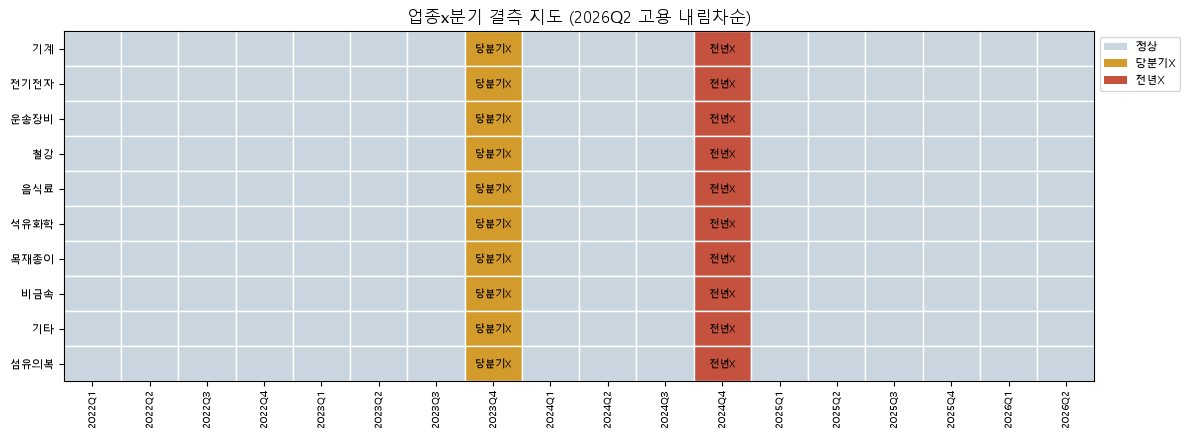

생산 YoY 결측 행 수=20, 고용 YoY 결측 행 수=0, 결측 분기=['2023Q4', '2024Q4']


In [7]:
# 업종x분기 결측 지도를 격자로 그린다 (정상/당분기 생산결측/전년동기 생산결측)
order_ind = triage[triage.quarter == '2026Q2'].sort_values('employment', ascending=False)['industry'].tolist()
quarters = sorted(state.quarter.unique())
grid = state.set_index(['industry', 'quarter'])

fig, ax = plt.subplots(figsize=(12, 4.5))
colors = {'정상': '#C9D6DF', '당분기X': '#D39A2C', '전년X': '#C5523F'}
for yi, ind in enumerate(order_ind):
    for xi, q in enumerate(quarters):
        row = grid.loc[(ind, q)]
        if row['production_current_missing']:
            label, color = '당분기X', colors['당분기X']
        elif row['production_lag4_missing']:
            label, color = '전년X', colors['전년X']
        else:
            label, color = '', colors['정상']
        ax.add_patch(plt.Rectangle((xi, yi), 1, 1, facecolor=color, edgecolor='white'))
        if label:
            ax.text(xi + 0.5, yi + 0.5, label, ha='center', va='center', fontsize=7)
ax.set_xlim(0, len(quarters)); ax.set_ylim(0, len(order_ind))
ax.set_xticks([i + 0.5 for i in range(len(quarters))]); ax.set_xticklabels(quarters, rotation=90, fontsize=7)
ax.set_yticks([i + 0.5 for i in range(len(order_ind))]); ax.set_yticklabels(order_ind, fontsize=8)
ax.invert_yaxis()
handles = [plt.Rectangle((0, 0), 1, 1, facecolor=c) for c in colors.values()]
ax.legend(handles, colors.keys(), loc='upper left', bbox_to_anchor=(1.0, 1.0), fontsize=8)
ax.set_title('업종x분기 결측 지도 (2026Q2 고용 내림차순)')
plt.tight_layout(); plt.show()

print(f"생산 YoY 결측 행 수={state.production_yoy.isna().sum()}, 고용 YoY 결측 행 수={state.employment_yoy.isna().sum()}, "
      f"결측 분기={sorted(state.loc[state.production_current_missing | state.production_lag4_missing, 'quarter'].unique())}")

**결측은 두 분기의 전 업종에 걸쳐 있고 특정 업종에 몰리지 않는다.** 결측 구간의 실제 국면이 무엇이었는지는 이 자료로 확인할 수 없다.

## 결과와 해석 범위

**본 분석 패널은 10업종×18분기 180행이며, 이 중 20행은 생산 YoY를 계산할 수 없다.** 결측은 보간하지 않고 INVALID로 남긴다.

업종 합계 고용을 산단 전체 고용으로 읽지 않는다. Q2의 비중과 기여율은 10개 업종 합계를 분모로 쓴다.

데이터 구축은 무엇을 계산할 수 있는지를 정한다. 다음 §3에서는 이 패널에서 생산과 고용이 같은 방향으로 움직이는지 탐색한다.

Source

- `src/core/build_changwon_master.py`
- `src/core/qa_master.py`
- `src/core/build_kicox_analysis_panel.py`
- `data/processed/kicox/changwon_state_panel.csv`
- `data/processed/kicox/changwon_state_reference_panel.csv`
- `logs/validation/preprocessing/qa_report.txt`
- `logs/validation/preprocessing/latest_points.json`
- `logs/validation/preprocessing/total_vs_industry.csv`

# 3. EDA — 생산과 고용은 같은 방향으로 움직이는가

## 분석 질문

본 분석에 앞서 생산과 고용의 흐름, 업종 규모, 변화 방향은 어떻게 분포하는가?

이 절은 국면(S1~S4)을 쓰지 않고 관측 분포만 본다. 그림은 `01_eda.ipynb`가 저장한 파일을 그대로 넣는다. 생산은 명목 금액이고 고용은 분기말 인원이다.

## 산단 전체 흐름

- **2018년 1분기=100 기준 2026년 2분기 지수는 명목 생산 115.6, 고용 94.8이다.**
- 총량 지수는 업종별 방향과 규모를 구분하지 못한다.

아래 그림은 산단 전체 생산·고용 지수를 비교한다. 음영은 본 분석기간이다.

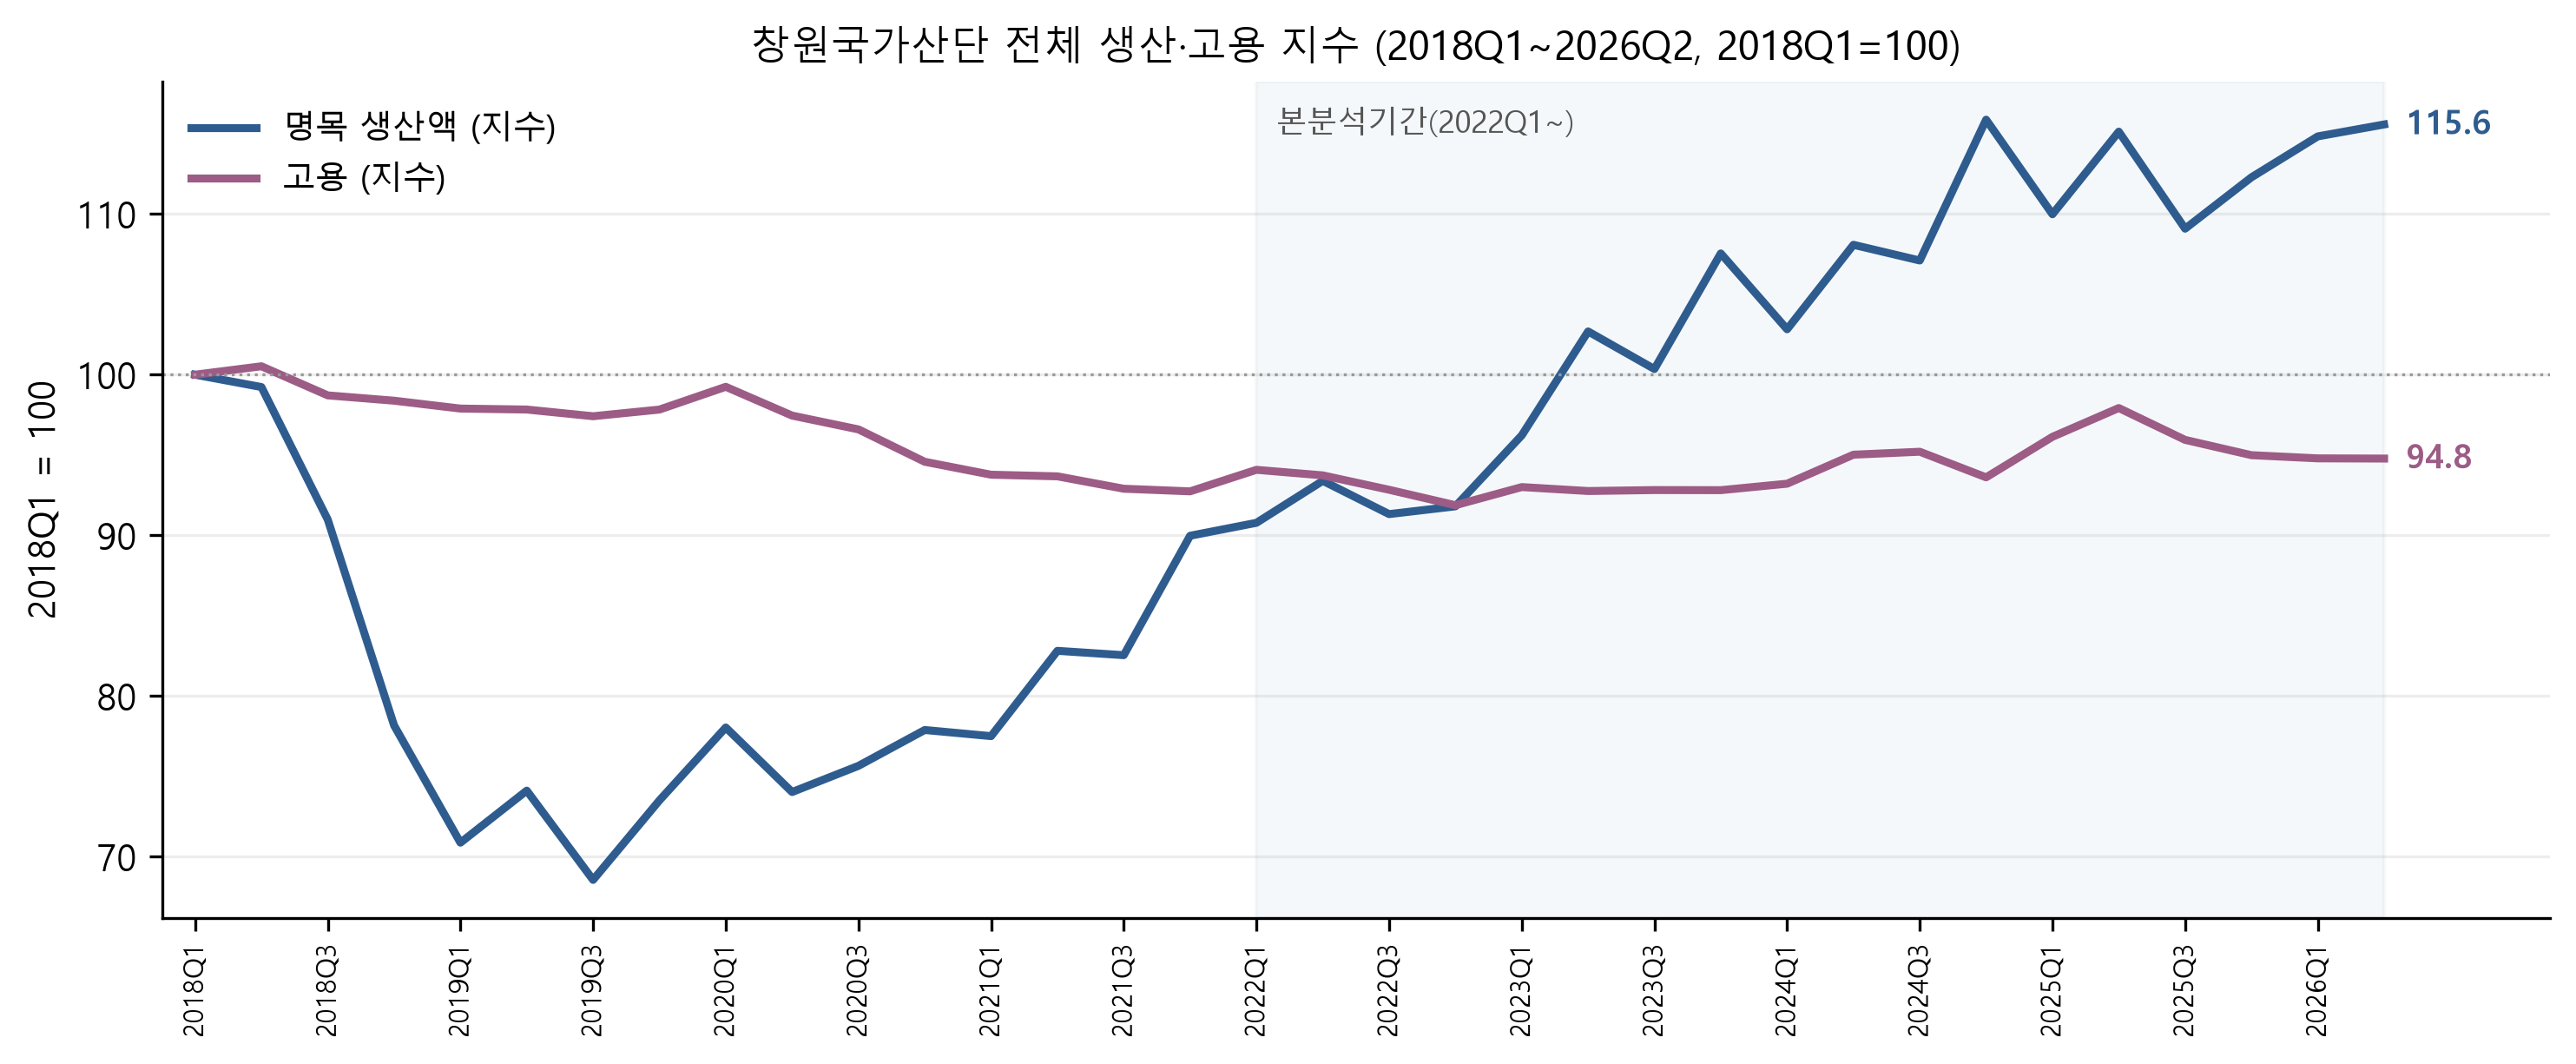

*outputs/final_model/06_report_assets/figures/S1_배경_총량지수.png*

2026Q2 지수(2018Q1=100): 생산=115.6, 고용=94.8, 차이=20.8p


In [8]:
# 산단 전체 생산·고용 지수(01_eda 저장 그림)를 표시하고 2026Q2 지수값을 확인한다
show_image('outputs/final_model/06_report_assets/figures/S1_배경_총량지수.png', width=900)

total_master = rd('data/processed/kicox/changwon_total_master.csv').sort_values('quarter')
base = total_master[total_master.quarter == '2018Q1'].iloc[0]
latest_t = total_master[total_master.quarter == '2026Q2'].iloc[0]
idx_p = latest_t.production_total / base.production_total * 100
idx_e = latest_t.employment_total / base.employment_total * 100
print(f'2026Q2 지수(2018Q1=100): 생산={idx_p:.1f}, 고용={idx_e:.1f}, 차이={idx_p - idx_e:.1f}p')

**명목 생산 지수와 고용 지수는 2026년 2분기에 20.8p 벌어져 있다.** 이 차이가 가격 상승 때문인지 물량 증가 때문인지는 이 그림으로 판단하지 않는다.

## 업종별 규모

- **2026년 2분기 고용 상위 4개 업종(기계·전기전자·운송장비·철강)이 고용의 98.2%, 명목 생산의 98.6%를 차지한다.**
- 나머지 6개 업종의 고용 비중 합계는 2%에 못 미친다.

아래 그림은 업종별 생산 비중과 고용 비중을 나란히 표시한다. 채운 점은 생산, 빈 점은 고용이다.

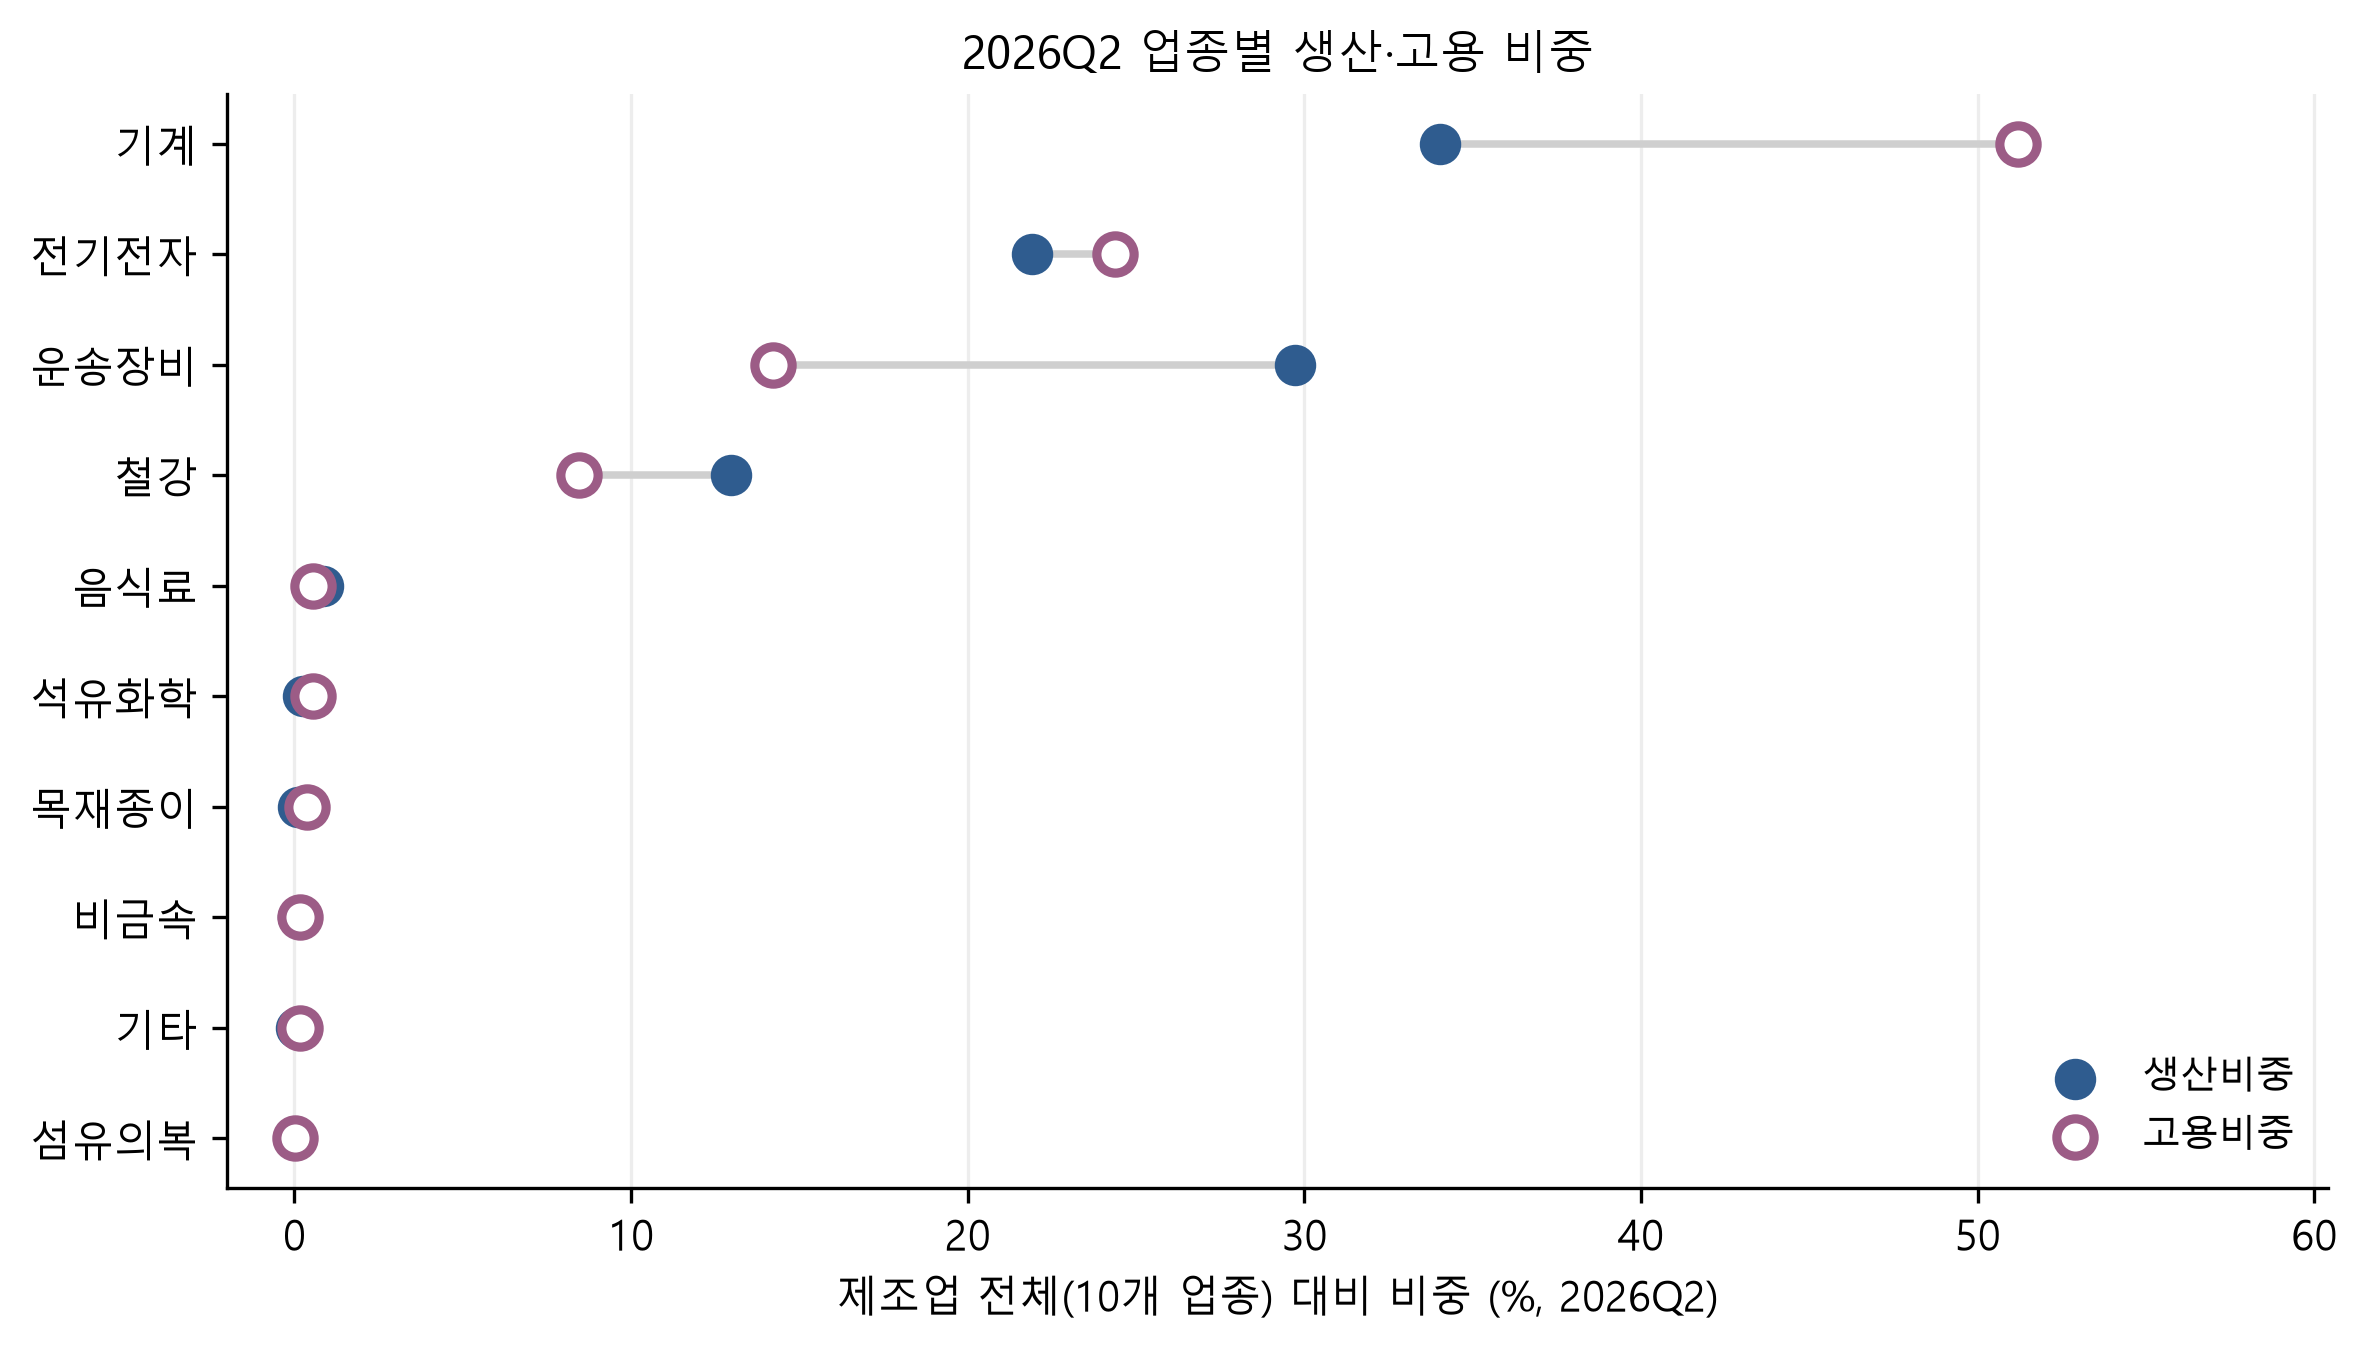

*outputs/final_model/06_report_assets/figures/S1_배경_규모비중.png*

고용 상위 4개 업종=['기계', '전기전자', '운송장비', '철강']
상위 4개 고용비중=98.2%, 생산비중=98.6%, 나머지 6개 고용비중=1.8%


In [9]:
# 업종별 생산·고용 비중(01_eda 저장 그림)을 표시하고 상위 4개 업종 비중을 확인한다
show_image('outputs/final_model/06_report_assets/figures/S1_배경_규모비중.png', width=800)

g2026 = triage[triage.quarter == '2026Q2'].sort_values('employment', ascending=False)
top4 = g2026.head(4); rest6 = g2026.tail(6)
emp_share = top4.employment.sum() / g2026.employment.sum() * 100
prod_share = top4.production.sum() / g2026.production.sum() * 100
rest_share = rest6.employment.sum() / g2026.employment.sum() * 100
print(f"고용 상위 4개 업종={top4.industry.tolist()}")
print(f"상위 4개 고용비중={emp_share:.1f}%, 생산비중={prod_share:.1f}%, 나머지 6개 고용비중={rest_share:.1f}%")

**같은 변화율이라도 업종마다 움직이는 인원 규모가 크게 다르다.** 이 그림은 규모를 보여주지만 규모가 큰 업종이 정책적으로 더 중요하다는 근거는 아니다.

## 전체기간 생산–고용 방향

- **생산·고용 YoY를 모두 계산할 수 있는 160건 중 56건(35.0%)은 두 변화율의 방향이 달랐다.**
- 한 지표가 정확히 0%인 4건은 따로 센다.

아래 그림은 업종×분기 관측을 생산 YoY와 고용 YoY 평면에 놓는다. 짙은 점은 2026년 2분기다.

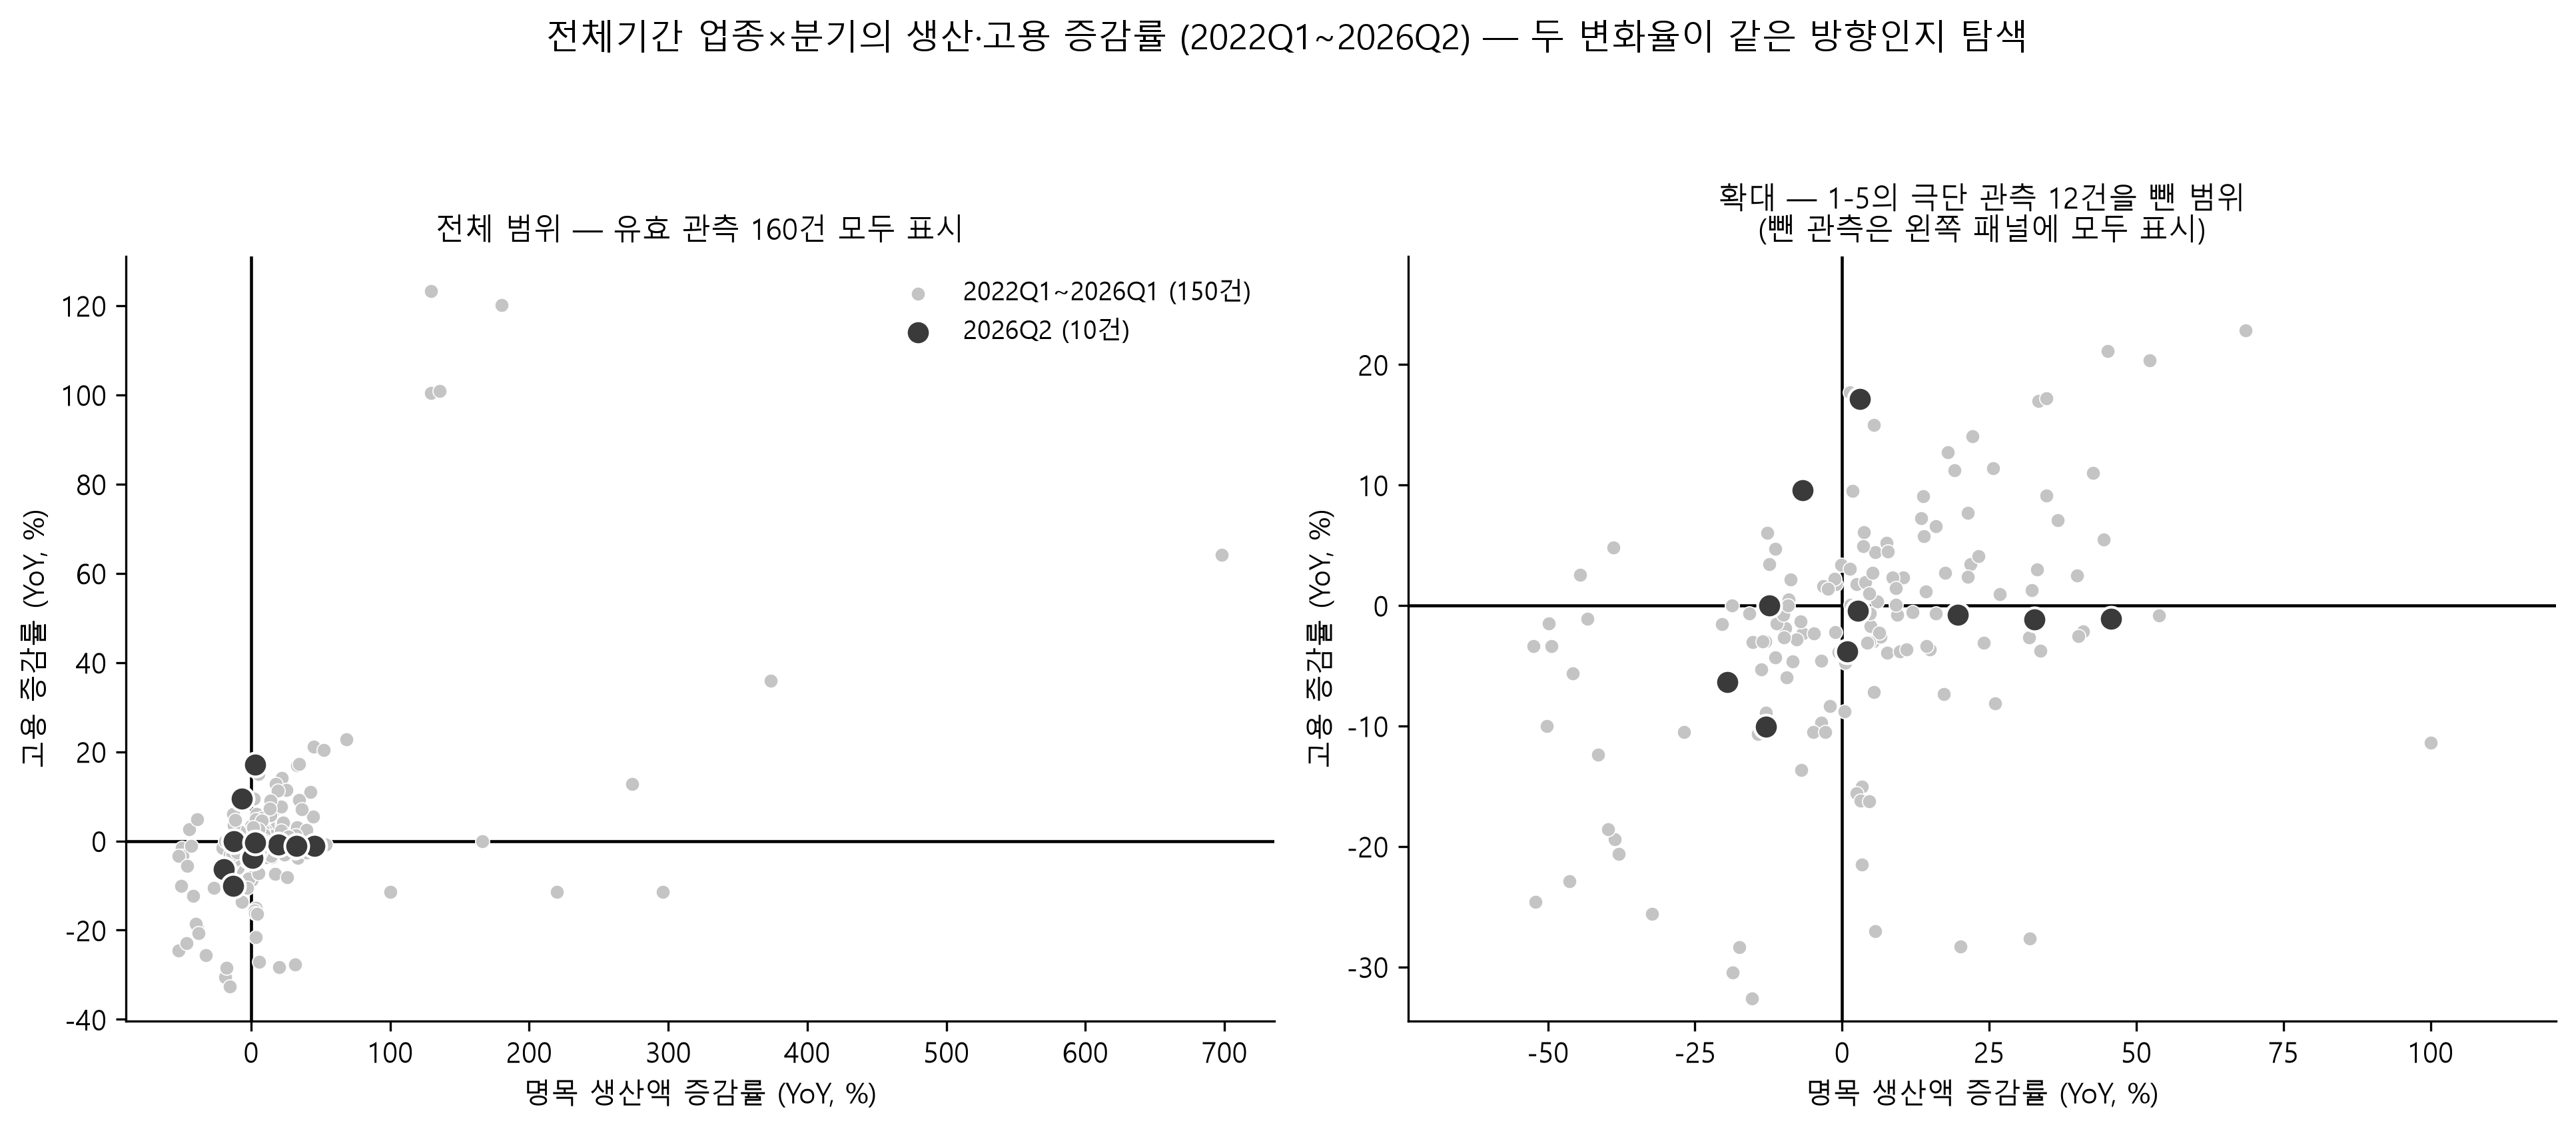

*outputs/final_model/06_report_assets/figures/S1_EDA_전체기간_생산고용관계.png*

n_valid_pairs=160, n_same_direction=100, n_opposite_direction=56, n_zero_involved=4, opposite_pct_all=35.0%


In [10]:
# 전체기간 생산-고용 YoY 산점도(01_eda 저장 그림)를 표시하고 방향 일치/불일치 건수를 확인한다
show_image('outputs/final_model/06_report_assets/figures/S1_EDA_전체기간_생산고용관계.png', width=950)

eda = results_summary.get('eda')
if eda:
    print(f"n_valid_pairs={eda['n_valid_pairs']}, n_same_direction={eda['n_same_direction']}, "
          f"n_opposite_direction={eda['n_opposite_direction']}, n_zero_involved={eda['n_zero_involved']}, "
          f"opposite_pct_all={eda['opposite_pct_all']:.1f}%")
else:
    valid = state[state.production_yoy.notna()]
    same = ((valid.production_yoy > 0) & (valid.employment_yoy > 0)) | ((valid.production_yoy < 0) & (valid.employment_yoy < 0))
    opp = ((valid.production_yoy > 0) & (valid.employment_yoy < 0)) | ((valid.production_yoy < 0) & (valid.employment_yoy > 0))
    zero = (valid.production_yoy == 0) | (valid.employment_yoy == 0)
    print(f"n_valid_pairs={len(valid)}, n_same={same.sum()}, n_opposite={opp.sum()}, n_zero={zero.sum()}")

**방향이 엇갈린 관측이 세 건 중 한 건꼴이다.** 산점도는 시간 순서를 표시하지 않으므로 같은 업종이 반복해서 엇갈렸는지는 이 그림으로 알 수 없다.

## 고용 감소 관측의 생산 방향

- **고용이 감소한 89건 중 43건(48.3%)은 명목 생산이 증가했다.**
- 고용 인원으로 가중하면 비율은 53.0%다.

아래 표는 생산 YoY를 계산할 수 있는 160건을 고용 방향과 생산 방향으로 교차 집계한다.

In [11]:
# 고용 방향 x 생산 방향 교차표(160건)와 고용감소-생산증가 비율을 확인한다
def _dir(x):
    return '증가' if x > 0 else ('감소' if x < 0 else '0%')

valid160 = state[state.production_yoy.notna()].copy()
valid160['emp_dir'] = valid160.employment_yoy.apply(_dir)
valid160['prod_dir'] = valid160.production_yoy.apply(_dir)
cross = pd.crosstab(valid160.emp_dir, valid160.prod_dir, margins=True, margins_name='합계')
cross = cross.reindex(index=['증가', '0%', '감소', '합계'], columns=['증가', '0%', '감소', '합계']).fillna(0).astype(int)
cross = cross.reset_index().rename(columns={'emp_dir': '고용\\생산'})
show_table(cross, max_rows=len(cross), digits=0)

down89 = valid160[valid160.employment_yoy < 0]
up43 = down89[down89.production_yoy > 0]
print(f"고용 감소 건수={len(down89)}, 그중 생산 증가 건수={len(up43)}, 비율={len(up43)/len(down89)*100:.1f}%")
q1h = results_summary.get('q1_history', {})
if 'weighted_pct' in q1h:
    print(f"인원 가중 비율={q1h['weighted_pct']:.1f}%")
else:
    print('weighted_pct 없음 — 인원 가중 비율 생략')

| 고용\생산 | 증가 | 0% | 감소 | 합계 |
| --- | --- | --- | --- | --- |
| 증가 | 54 | 0 | 13 | 67 |
| 0% | 1 | 0 | 3 | 4 |
| 감소 | 43 | 0 | 46 | 89 |
| 합계 | 98 | 0 | 62 | 160 |

고용 감소 건수=89, 그중 생산 증가 건수=43, 비율=48.3%
인원 가중 비율=53.0%


**고용 감소와 생산 증가가 겹친 관측이 고용 감소 관측의 절반 가까이다.** 반복 관측이 들어 있으므로 160건을 서로 독립인 표본으로 읽지 않는다.

## 결과와 해석 범위

**고용이 줄어든 관측의 절반 가까이는 명목 생산이 늘었다.** 생산 YoY를 계산할 수 있고 고용이 감소한 89건 중 43건(48.3%)이다.

생산 증가를 물량 증가로 읽지 않는다. 명목 금액에는 가격 변화가 섞여 있고, PPI 비교는 §11에 둔다.

EDA는 방향이 엇갈리고 규모가 한쪽에 몰려 있으며, 산점도로는 시간 흐름을 볼 수 없다는 점을 보여준다. 다음 §4에서는 방향 조합을 국면으로 정의하고, §5와 §6에서 규모와 시간을 따로 확인한다. 업종별 지수 경로, YoY 범위, 가동률·업체수는 Appendix C에 둔다.

Source

- `notebooks/01_eda.ipynb` Section 1-2·1-3·1-6
- `outputs/final_model/06_report_assets/figures/S1_*.png`
- `outputs/final_model/01_core/tables/results_summary.json`
- `data/processed/kicox/changwon_state_panel.csv`

# 4. Q1 상태 — 같은 고용 변화라도 생산 방향은 다른가

## 분석 질문

고용이 같은 방향으로 변한 업종×분기라도 명목 생산의 방향은 서로 다른가?

$$
\text{state}=\begin{cases}
S1 & g^{prod}>0,\ g^{emp}>0\\
S2 & g^{prod}>0,\ g^{emp}<0\\
S3 & g^{prod}<0,\ g^{emp}>0\\
S4 & g^{prod}<0,\ g^{emp}<0
\end{cases}
$$

$g^{prod}$는 명목 생산 YoY(%), $g^{emp}$는 고용 YoY(%)다. 둘 중 하나가 정확히 0이면 N, 하나라도 계산할 수 없으면 INVALID다. 본 분석 경계는 0이고 ±0.5·1·2% 중립구간은 민감도 확인에만 쓴다. S 번호는 위험 순위가 아니다.

## 2026년 2분기 업종별 국면

- **2026년 2분기에 고용이 감소한 7개 업종 중 5개는 명목 생산이 증가했다.**
- 이 5개 업종의 고용 비중 합계는 47.7%다.

아래 그림은 2026년 2분기 업종별 생산 YoY와 고용 YoY를 사분면에 표시한다. 원 크기는 고용 규모다.

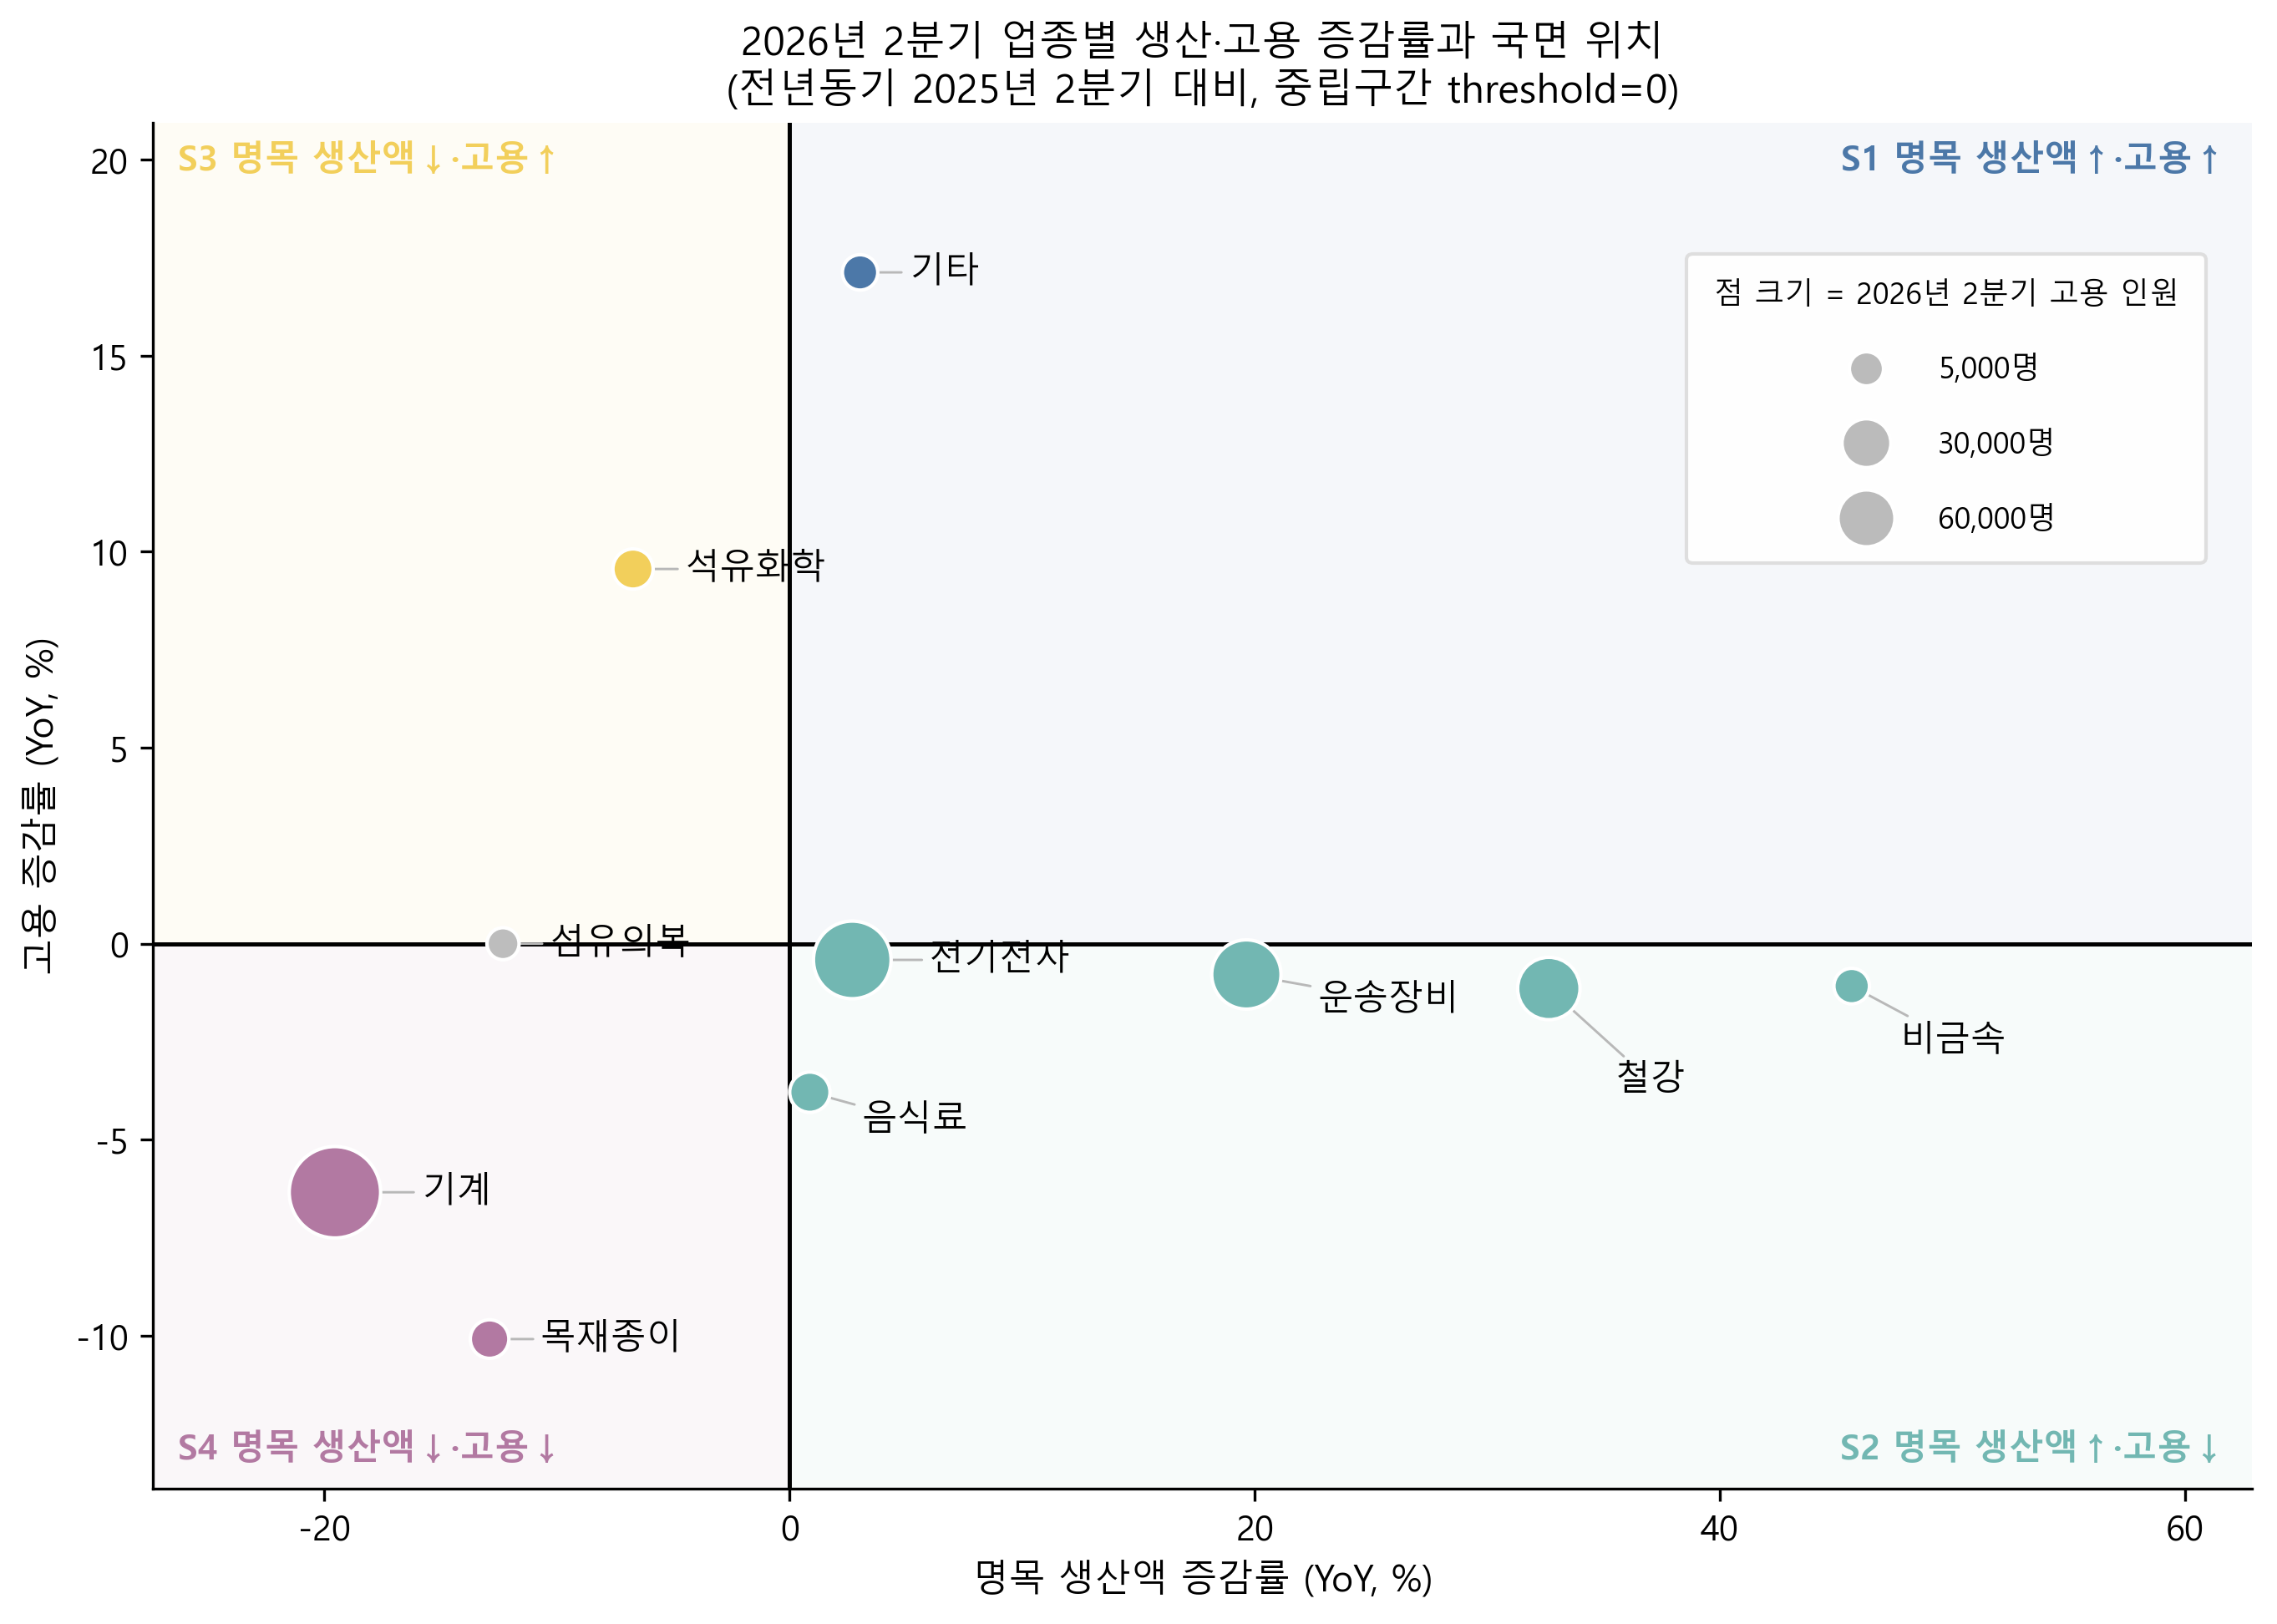

*outputs/final_model/01_core/figures/Q1A_최신분기_사분면.png*

| industry | state | p_yoy | e_yoy | employment |
| --- | --- | --- | --- | --- |
| 기계 | S4 | -19.55 | -6.34 | 58,784.00 |
| 전기전자 | S2 | 2.70 | -0.41 | 27,979.00 |
| 운송장비 | S2 | 19.64 | -0.78 | 16,308.00 |
| 철강 | S2 | 32.65 | -1.14 | 9,689.00 |
| 음식료 | S2 | 0.87 | -3.79 | 635.00 |
| 석유화학 | S3 | -6.73 | 9.56 | 619.00 |
| 목재종이 | S4 | -12.90 | -10.08 | 428.00 |
| 비금속 | S2 | 45.67 | -1.08 | 183.00 |
| 기타 | S1 | 3.03 | 17.12 | 171.00 |
| 섬유의복 | N | -12.32 | 0.00 | 34.00 |

고용 감소 업종 수=7, 생산 증가(S2) 업종=['전기전자', '운송장비', '철강', '음식료', '비금속'], 고용 비중 합=47.7%
results_summary q1_latest: n_down=7, n_nominal_up=5, share=47.7% | 일치=True


In [12]:
# 2026Q2 업종별 국면(사분면)을 표시하고 고용감소+생산증가(S2) 업종을 확인한다
show_image('outputs/final_model/01_core/figures/Q1A_최신분기_사분면.png', width=850)

g26 = triage[triage.quarter == '2026Q2'].sort_values('employment', ascending=False)
show_table(g26[['industry', 'state', 'p_yoy', 'e_yoy', 'employment']], max_rows=10)

down = g26[g26.e_yoy < 0]
up = down[down.p_yoy > 0]
q1_latest = results_summary['q1_latest']
print(f"고용 감소 업종 수={len(down)}, 생산 증가(S2) 업종={up.industry.tolist()}, "
      f"고용 비중 합={up.employment_share_pct.sum():.1f}%")
print(f"results_summary q1_latest: n_down={q1_latest['n_down']}, n_nominal_up={q1_latest['n_nominal_up']}, "
      f"share={q1_latest['nominal_employment_share_pct']:.1f}% | 일치={len(down)==q1_latest['n_down'] and len(up)==q1_latest['n_nominal_up']}")

**기계와 목재종이만 생산과 고용이 함께 줄었고, 전기전자·운송장비·철강·음식료·비금속은 생산이 늘고 고용이 줄었다.** 생산이 늘었다는 것이 물량이나 수익이 늘었다는 뜻인지는 이 그림으로 알 수 없다.

## 전체 기간 국면 분포

- **180행은 S1 54, S2 43, S3 13, S4 46, N 4, INVALID 20으로 나뉜다.**
- INVALID 20행은 2023년 4분기와 2024년 4분기에만 있다.

아래 그림은 업종×분기 국면을 격자로 표시한다. 오른쪽 막대는 업종별 국면 구성비이며 INVALID는 구성비에서 뺀다.

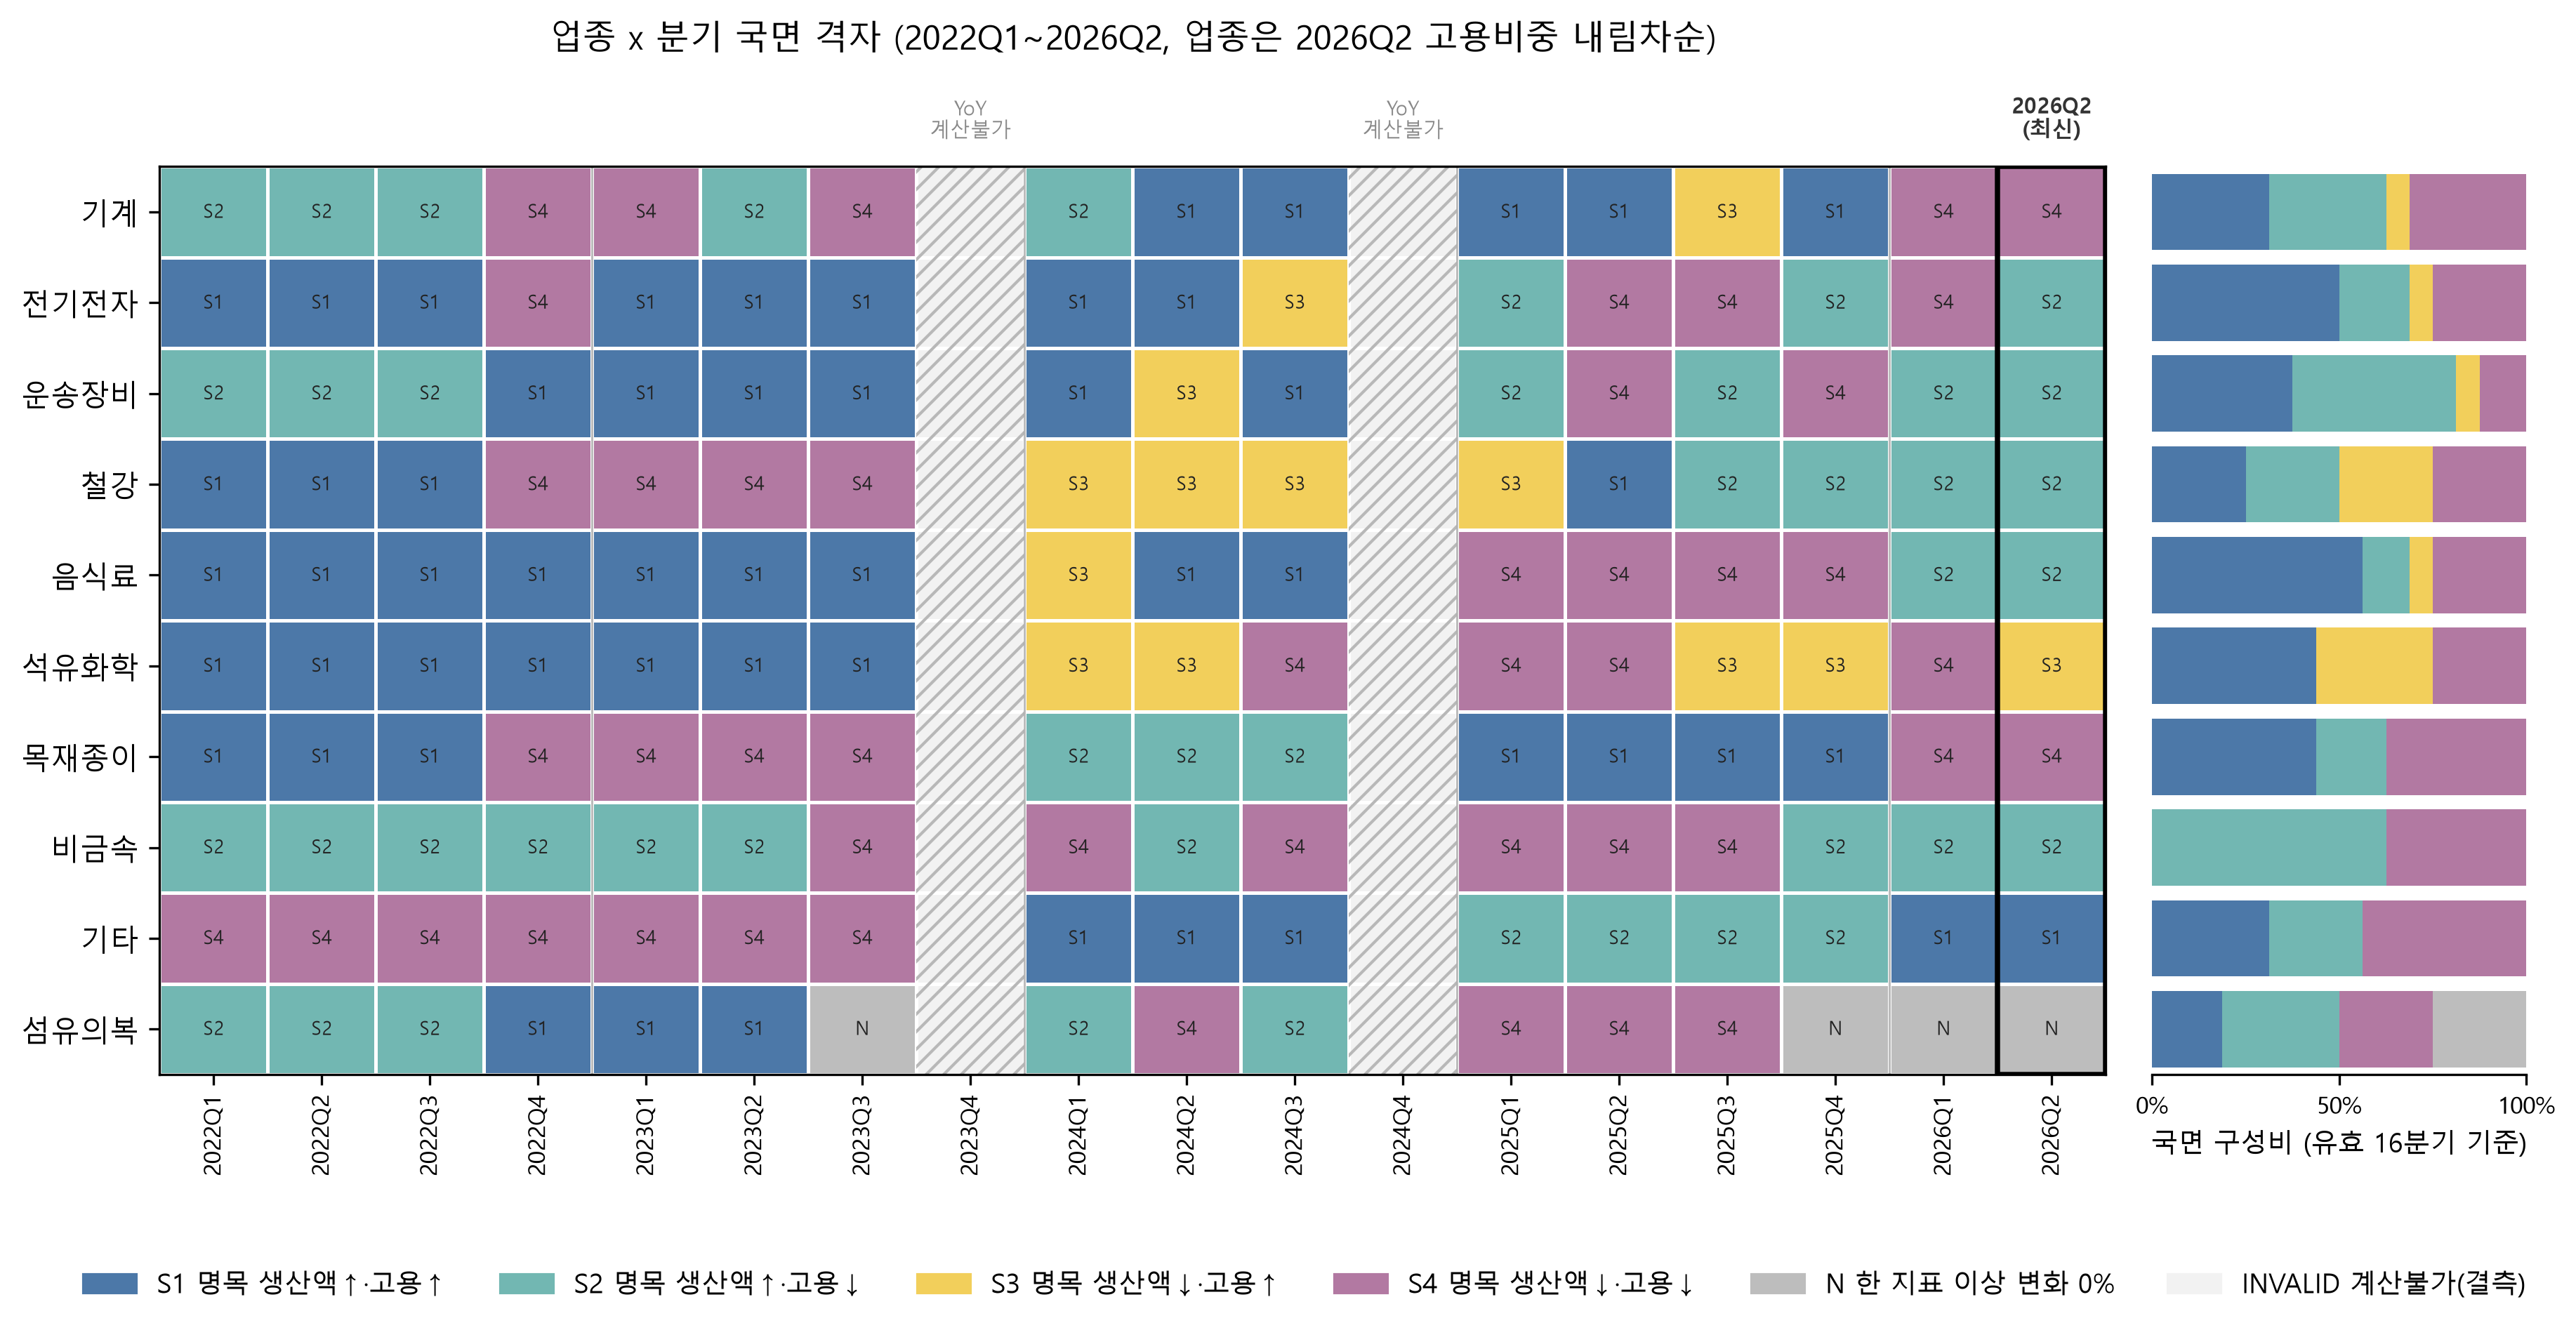

*outputs/final_model/01_core/figures/Q1B_국면격자.png*

| 구분 | S1 | S2 | S3 | S4 | N | INVALID |
| --- | --- | --- | --- | --- | --- | --- |
| 건수 | 54 | 43 | 13 | 46 | 4 | 20 |

| industry | 최빈국면 |
| --- | --- |
| 기계 | S2 |
| 기타 | S4 |
| 목재종이 | S1 |
| 비금속 | S2 |
| 석유화학 | S1 |
| 섬유의복 | S2 |
| 운송장비 | S2 |
| 음식료 | S1 |
| 전기전자 | S1 |
| 철강 | S1 |

In [13]:
# 업종x분기 국면 격자를 표시하고 전체 국면 분포·업종별 최빈 국면을 확인한다
show_image('outputs/final_model/01_core/figures/Q1B_국면격자.png', width=950)

dist_row = pd.DataFrame([state.state.value_counts().reindex(STATE_ORDER)], index=['건수'])
show_table(dist_row.reset_index().rename(columns={'index': '구분'}), max_rows=1, digits=0)

mode_tbl = (state[state.state != 'INVALID'].groupby('industry')['state']
            .agg(lambda s: s.value_counts().idxmax()).reset_index().rename(columns={'state': '최빈국면'}))
show_table(mode_tbl, max_rows=10)

**같은 업종도 분기에 따라 국면이 바뀐다.** 격자는 국면의 배치를 보여줄 뿐 국면 사이의 좋고 나쁨을 나타내지 않는다.

## 중립구간 민감도

- **중립구간을 ±2%로 넓히면 N은 4행에서 47행으로 늘고 유효 전환쌍은 126개에서 78개로 줄어든다.**
- INVALID 20행은 경계와 상관없이 같다.

아래 표는 경계별 국면 분포와 유효 전환쌍 수를 비교한다.

In [14]:
# 중립구간(0/±0.5/±1/±2%)별 국면 분포와 유효 전환쌍 수, 기준 대비 변화 행 수를 확인한다
rows = []
base_key = state.set_index(['industry', 'quarter'])['state']
rows.append({'경계': '0', **state.state.value_counts().reindex(STATE_ORDER).to_dict(),
             '유효전환쌍': int(state.valid_transition.sum()), '기준대비변경': 0})
for th in [0.5, 1.0, 2.0]:
    sub = sens[sens.threshold == th]
    sub_key = sub.set_index(['industry', 'quarter'])['state']
    m = pd.concat([base_key.rename('base'), sub_key.rename('th')], axis=1)
    changed = ((m.base != 'INVALID') & (m.th != 'INVALID') & (m.base != m.th)).sum()
    rows.append({'경계': f'±{th:g}%', **sub.state.value_counts().reindex(STATE_ORDER).to_dict(),
                 '유효전환쌍': int(sub.valid_transition.sum()), '기준대비변경': int(changed)})
show_table(pd.DataFrame(rows), max_rows=4, digits=0)

| 경계 | S1 | S2 | S3 | S4 | N | INVALID | 유효전환쌍 | 기준대비변경 |
| --- | --- | --- | --- | --- | --- | --- | --- | --- |
| 0 | 54 | 43 | 13 | 46 | 4 | 20 | 126 | 0 |
| ±0.5% | 51 | 41 | 11 | 46 | 11 | 20 | 115 | 7 |
| ±1% | 50 | 33 | 11 | 43 | 23 | 20 | 100 | 19 |
| ±2% | 41 | 29 | 7 | 36 | 47 | 20 | 78 | 43 |

**±2% 경계에서는 기준 대비 43행의 국면이 바뀌고, S2와 S1이 가장 많이 줄어든다.** 이 표는 경계에 민감한 관측의 수를 보여주며 어느 경계가 옳은지는 알려주지 않는다.

## 결과와 해석 범위

**고용 감소라는 한 신호 안에 생산 방향이 다른 관측이 섞여 있다.** 2026년 2분기에도 고용 감소 7개 업종 중 5개가 S2다.

S2를 "생산성 향상"이나 "자동화"로 읽지 않는다. 명목 생산에는 가격이 섞여 있고, 기업별 원인은 이 자료로 확인할 수 없다.

Q1은 상태가 다르다는 것만 보여주고 변화의 크기는 알려주지 않는다. 다음 §5에서는 고용 변화가 어느 업종에 몰려 있는지 확인한다.

Source

- `outputs/final_model/01_core/figures/Q1A_최신분기_사분면.png`
- `outputs/final_model/01_core/figures/Q1B_국면격자.png`
- `data/processed/kicox/changwon_state_panel.csv`
- `data/processed/kicox/changwon_state_sensitivity_panel.csv`
- `src/core/q1_state_analysis.py`

# 5. Q2 규모 — 고용 변화는 어느 업종에 몰려 있는가

## 분석 질문

산단 제조업 고용 변화 가운데 어느 업종의 인원 변화가 큰가?

$$\Delta emp_i = emp_{i,t}-emp_{i,t-4},\qquad share_i=\frac{emp_{i,t}}{\sum_j emp_{j,t}}\times100,\qquad contrib_i=\frac{\Delta emp_i}{\sum_j \Delta emp_j}\times100$$

$$\text{net/gross}=\frac{\left|\sum_j \Delta emp_j\right|}{\sum_j\left|\Delta emp_j\right|},\qquad \text{비례기대}_i=\sum_j \Delta emp_j\times\frac{emp_{i,t-4}}{\sum_j emp_{j,t-4}}$$

분모는 10개 업종 합계다. 기여율은 net/gross(순변화/총변화 비율)가 0.30 이상인 분기에만 표시한다. 순변화가 작으면 기여율이 수백 %로 부풀기 때문이다. 초과증감은 실제 증감에서 비례기대 증감을 뺀 값이다.

## 2026년 2분기 업종별 고용 증감

- **2026년 2분기 제조업 고용은 전년동기보다 4,332명 줄었고, 기계가 3,979명 줄어 기여율 91.85%다.**
- 기계의 고용 비중은 51.19%다.

아래 그림은 업종별 고용 증감 인원과 고용 비중을 나란히 보여준다. 막대 색은 증감 방향이다.

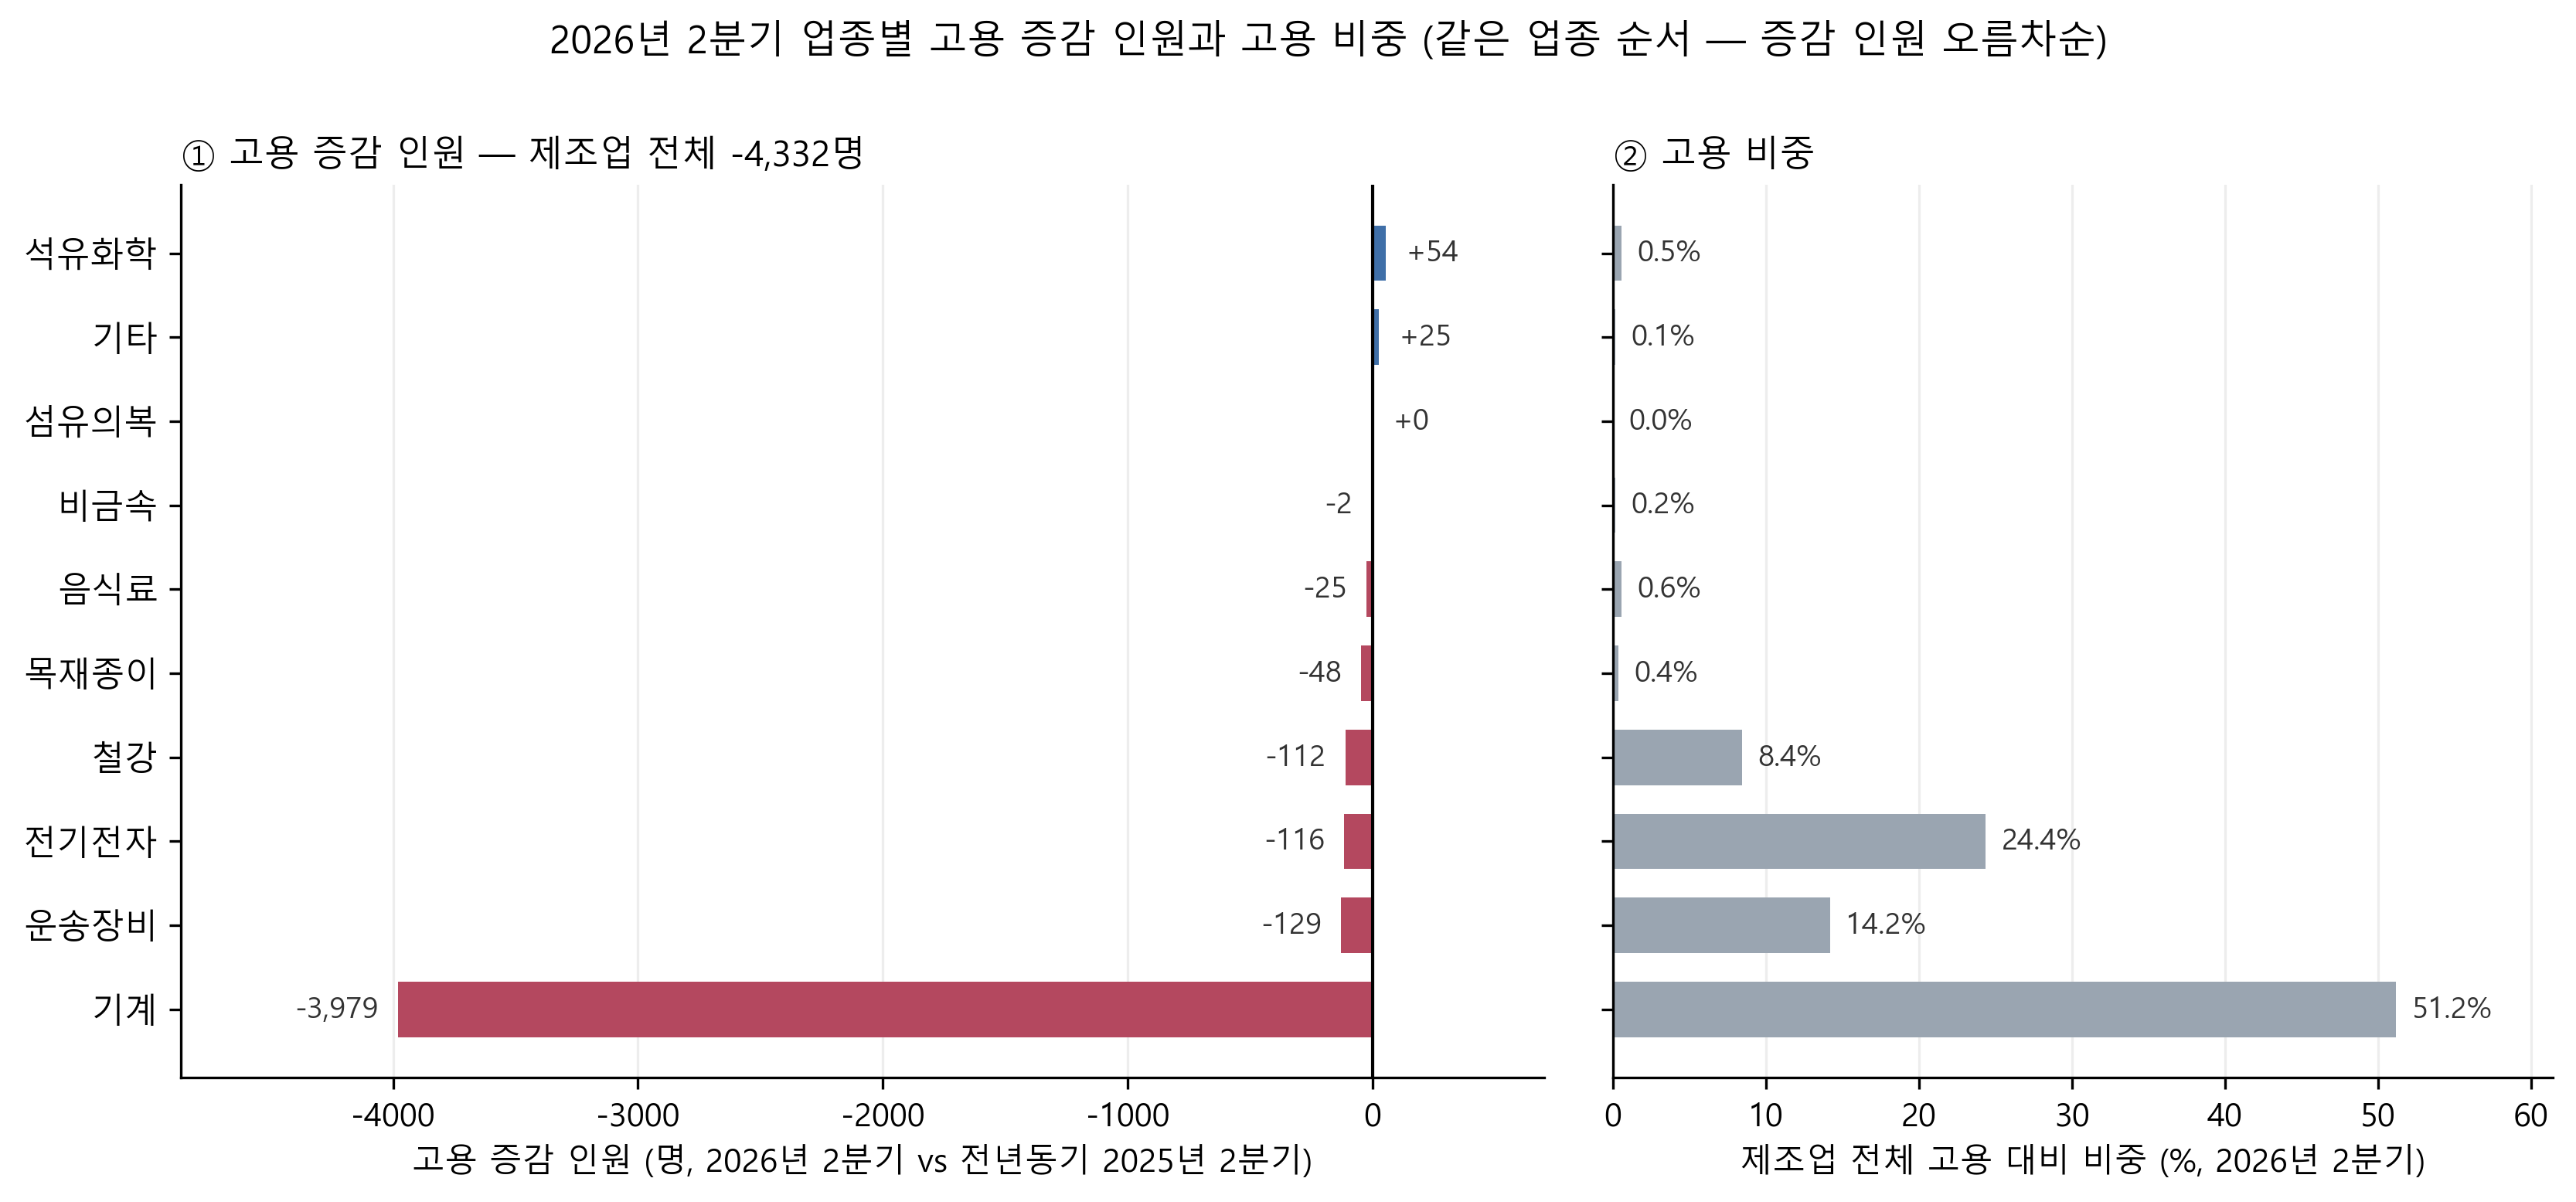

*outputs/final_model/01_core/figures/Q2A_고용증감_비중.png*

| industry | employment | emp_delta | e_yoy | employment_share_pct | contribution_pct |
| --- | --- | --- | --- | --- | --- |
| 기계 | 58,784.00 | -3,979.00 | -6.34 | 51.19 | 91.85 |
| 운송장비 | 16,308.00 | -129.00 | -0.78 | 14.20 | 2.98 |
| 전기전자 | 27,979.00 | -116.00 | -0.41 | 24.37 | 2.68 |
| 철강 | 9,689.00 | -112.00 | -1.14 | 8.44 | 2.59 |
| 목재종이 | 428.00 | -48.00 | -10.08 | 0.37 | 1.11 |
| 음식료 | 635.00 | -25.00 | -3.79 | 0.55 | 0.58 |
| 비금속 | 183.00 | -2.00 | -1.08 | 0.16 | 0.05 |
| 섬유의복 | 34.00 | 0.00 | 0.00 | 0.03 | -0.00 |
| 기타 | 171.00 | 25.00 | 17.12 | 0.15 | -0.58 |
| 석유화학 | 619.00 | 54.00 | 9.56 | 0.54 | -1.25 |

10업종 합계 고용=114830, 순증감=-4332, net/gross=0.9648


In [15]:
# 2026Q2 업종별 고용 증감·비중·기여율을 표시하고 net/gross를 확인한다
show_image('outputs/final_model/01_core/figures/Q2A_고용증감_비중.png', width=900)

g26 = triage[triage.quarter == '2026Q2'].sort_values('emp_delta')
show_table(g26[['industry', 'employment', 'emp_delta', 'e_yoy', 'employment_share_pct', 'contribution_pct']], max_rows=10)

net = g26.emp_delta.sum(); gross = g26.emp_delta.abs().sum()
print(f"10업종 합계 고용={g26.employment.sum():.0f}, 순증감={net:.0f}, net/gross={abs(net)/gross:.4f}")

**순감소 4,332명 가운데 기계를 뺀 9개 업종의 순감소는 353명이다.** 기여율은 인원의 몫을 나눈 산술 분해이며, 기계 감소가 다른 업종의 고용에 영향을 줬는지는 이 표로 알 수 없다.

## 기여율 표시 조건

- **18분기 중 net/gross가 0.30 이상이라 기여율을 표시하는 분기는 10개다.**
- 2025년 3분기처럼 증가와 감소가 상쇄된 분기는 순변화가 작아 기여율을 표시하지 않는다.

아래 표는 분기별 순증감, 총변화, net/gross와 표시 여부를 보여준다.

In [16]:
# 분기별 순증감·총변화·net/gross와 기여율 표시 가능 여부(>=0.30)를 확인한다
q_tbl = triage.groupby('quarter').agg(mfg_emp_delta=('mfg_emp_delta', 'first'),
                                       net_gross_ratio=('net_gross_ratio', 'first')).reset_index()
q_tbl['총변화'] = triage.groupby('quarter')['emp_delta'].apply(lambda s: s.abs().sum()).values
q_tbl['표시'] = q_tbl.net_gross_ratio >= 0.30
show_table(q_tbl, max_rows=18)

print(f"표시 가능 분기 수={q_tbl['표시'].sum()} / {len(q_tbl)}")
print(f"표시 불가 분기={q_tbl.loc[~q_tbl['표시'], 'quarter'].tolist()}")

| quarter | mfg_emp_delta | net_gross_ratio | 총변화 | 표시 |
| --- | --- | --- | --- | --- |
| 2022Q1 | 280.00 | 0.05 | 5,652.00 | False |
| 2022Q2 | -70.00 | 0.01 | 5,838.00 | False |
| 2022Q3 | -266.00 | 0.05 | 4,878.00 | False |
| 2022Q4 | -3,381.00 | 0.74 | 4,597.00 | True |
| 2023Q1 | -3,571.00 | 0.37 | 9,621.00 | True |
| 2023Q2 | -3,488.00 | 0.43 | 8,118.00 | True |
| 2023Q3 | -2,191.00 | 0.25 | 8,711.00 | False |
| 2023Q4 | 1,178.00 | 0.12 | 9,516.00 | False |
| 2024Q1 | 269.00 | 0.25 | 1,073.00 | False |
| 2024Q2 | 2,939.00 | 0.97 | 3,029.00 | True |
| 2024Q3 | 2,944.00 | 0.96 | 3,066.00 | True |
| 2024Q4 | 1,063.00 | 0.48 | 2,207.00 | True |
| 2025Q1 | 2,918.00 | 0.50 | 5,858.00 | True |
| 2025Q2 | 2,863.00 | 0.40 | 7,161.00 | True |
| 2025Q3 | 202.00 | 0.05 | 4,286.00 | False |
| 2025Q4 | 873.00 | 0.13 | 6,481.00 | False |
| 2026Q1 | -1,965.00 | 0.98 | 2,009.00 | True |
| 2026Q2 | -4,332.00 | 0.96 | 4,490.00 | True |

표시 가능 분기 수=10 / 18
표시 불가 분기=['2022Q1', '2022Q2', '2022Q3', '2023Q3', '2023Q4', '2024Q1', '2025Q3', '2025Q4']


**표시 불가 8개 분기는 업종 간 증감이 서로 상쇄된 분기다.** 0.30은 오독을 줄이기 위한 표시 규칙이며 통계적 유의성 기준이 아니다.

## 비례배분 기준선

- **모든 업종이 같은 비율로 줄었다고 가정한 기대치보다 기계는 1,697명 더 줄었다.**
- 전기전자·운송장비·철강은 기대치보다 덜 줄었다.

아래 그림은 업종별 실제 증감과 비례기대 증감을 비교한다. 차이 막대가 초과증감이다.

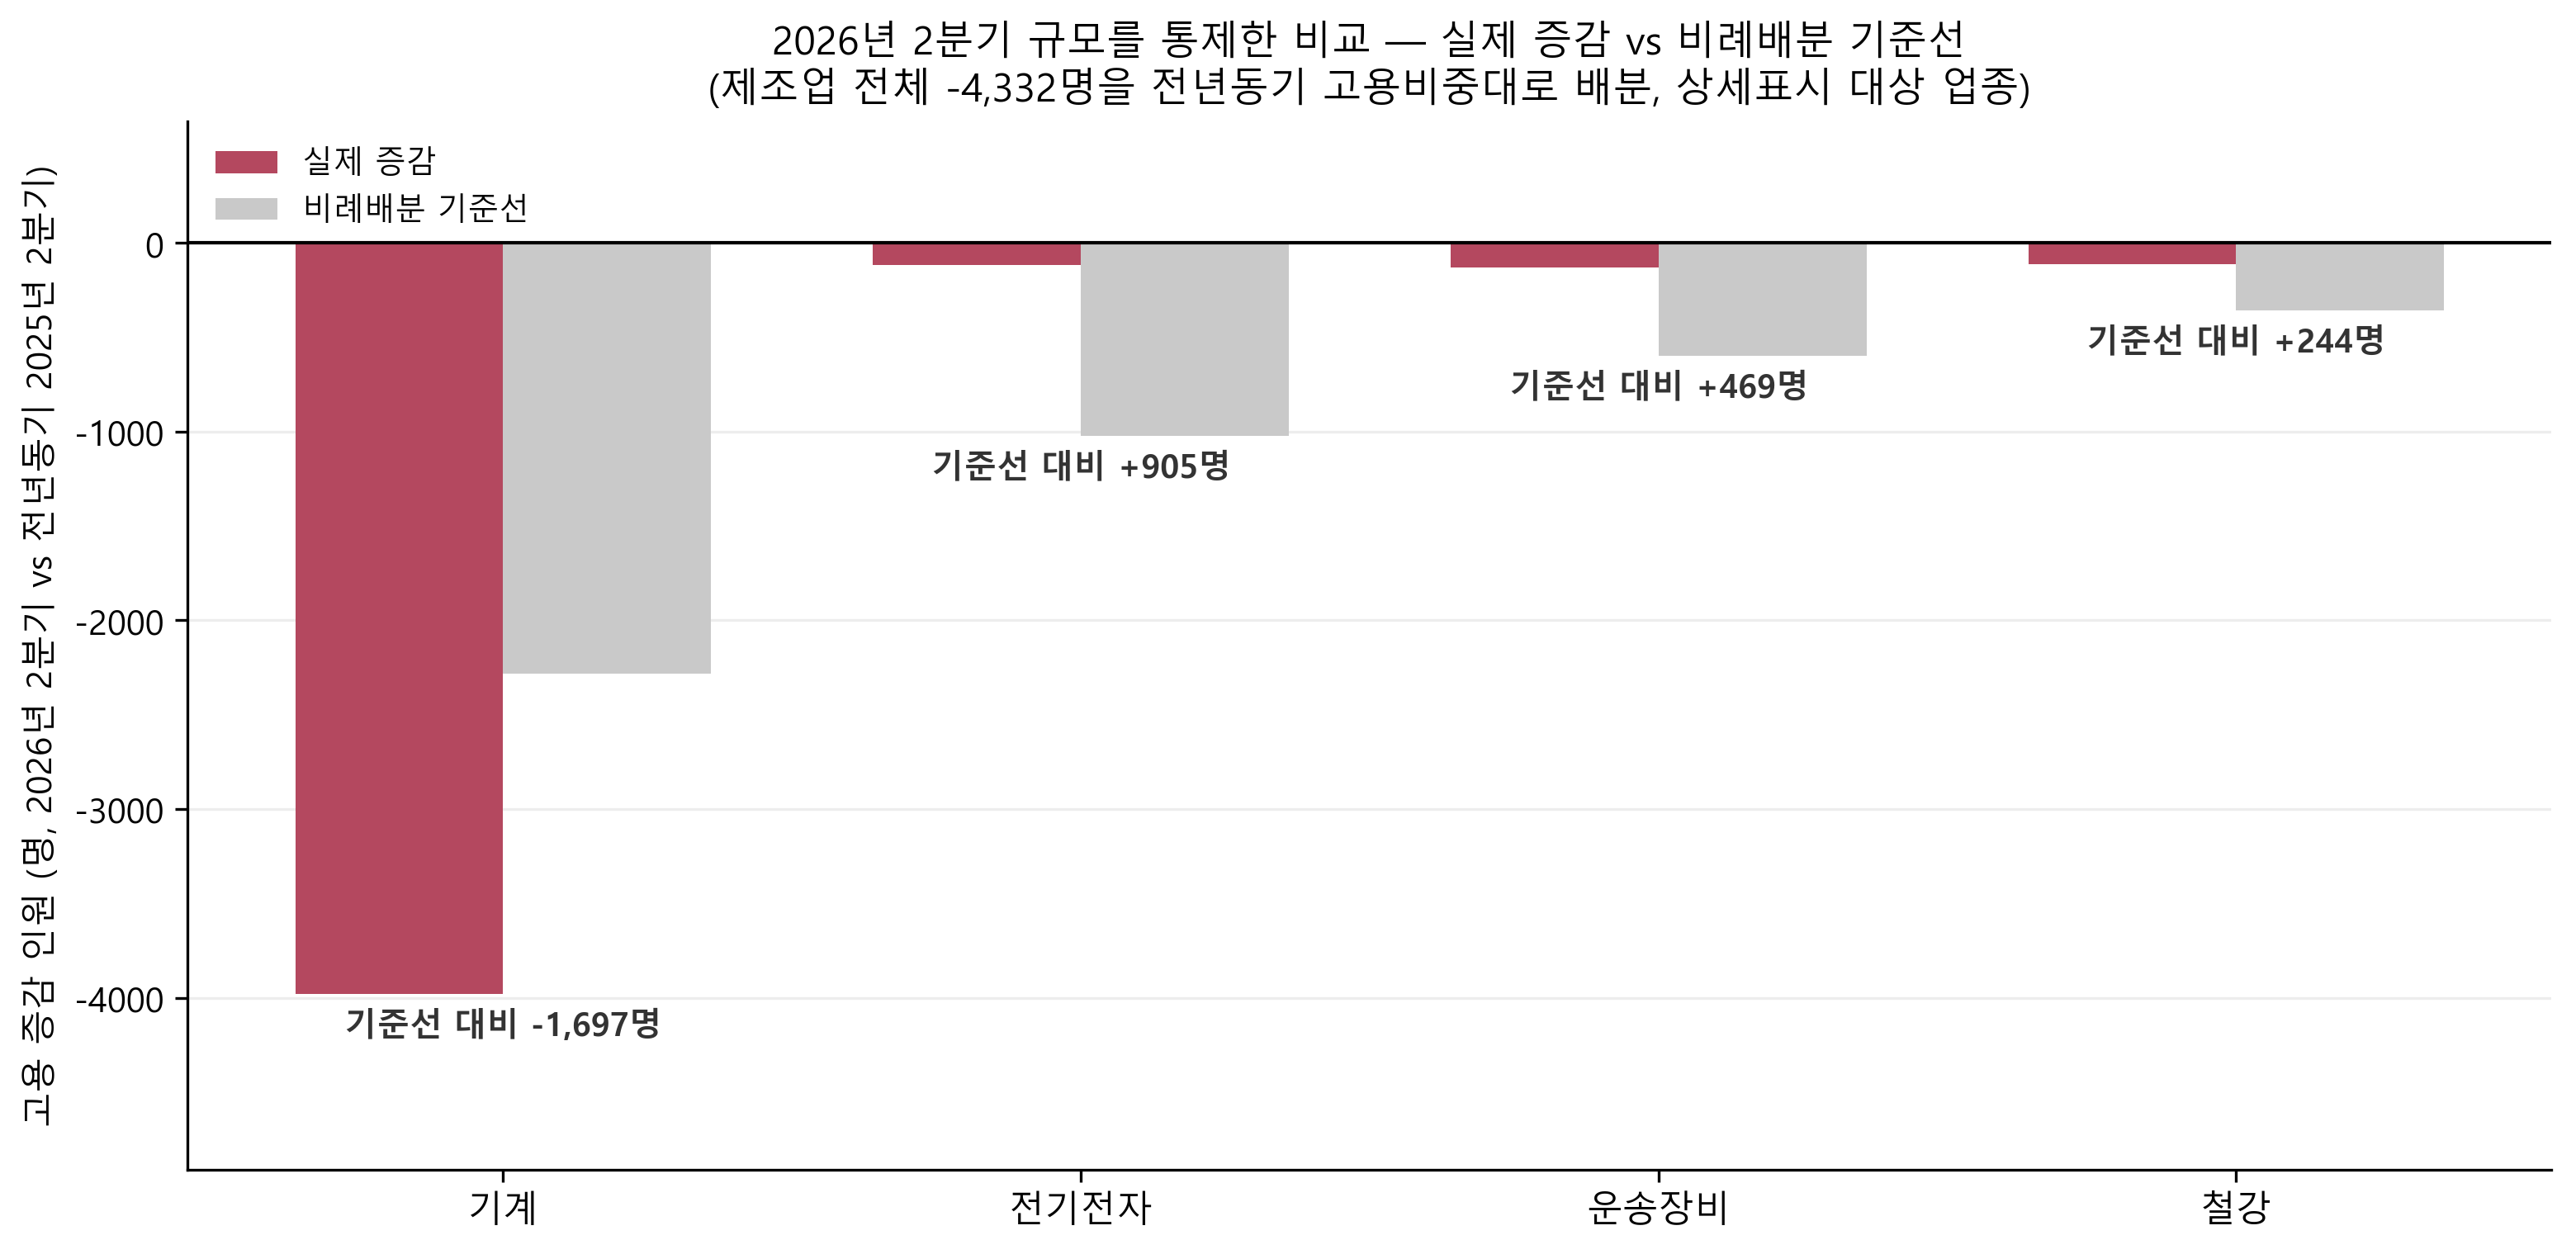

*outputs/final_model/01_core/figures/Q2C_비례기준선_비교.png*

| industry | 2026Q2_증감인원 | 비례기대증감 | 초과증감 |
| --- | --- | --- | --- |
| 기계 | -3,979.0 | -2,281.7 | -1,697.3 |
| 전기전자 | -116.0 | -1,021.4 | 905.4 |
| 운송장비 | -129.0 | -597.5 | 468.5 |
| 철강 | -112.0 | -356.3 | 244.3 |
| 음식료 | -25.0 | -24.0 | -1.0 |
| 석유화학 | 54.0 | -20.5 | 74.5 |
| 목재종이 | -48.0 | -17.3 | -30.7 |
| 비금속 | -2.0 | -6.7 | 4.7 |
| 기타 | 25.0 | -5.3 | 30.3 |
| 섬유의복 | 0.0 | -1.2 | 1.2 |

In [17]:
# 비례배분 기준선 대비 업종별 실제 증감·초과증감을 표시한다
show_image('outputs/final_model/01_core/figures/Q2C_비례기준선_비교.png', width=850)

q2sum = rd('outputs/final_model/01_core/tables/Q2_규모요약.csv')
show_table(q2sum[['industry', '2026Q2_증감인원', '비례기대증감', '초과증감']], max_rows=10, digits=1)

**초과감소가 가장 큰 업종은 기계다.** 기준선은 같은 비율 가정에서 나온 비교값이며 초과증감이 업종 고유 요인 때문이라는 뜻은 아니다.

## 결과와 해석 범위

**2026년 2분기 고용 변화는 기계 한 업종에 몰려 있다.** 순감소 4,332명 중 3,979명(91.85%)이 기계이고, 비례기대치보다도 1,697명 더 줄었다.

기여율을 원인 분해로 읽지 않는다. 또 10개 업종 합계는 산단 전체 고용 총계와 다르다(§2).

Q2는 크기를 보여주지만 그 상태가 얼마나 이어졌는지는 알려주지 않는다. 다음 §6에서는 국면의 지속과 전환을 확인한다.

Source

- `outputs/final_model/01_core/figures/Q2A_고용증감_비중.png`
- `outputs/final_model/01_core/figures/Q2C_비례기준선_비교.png`
- `outputs/final_model/01_core/tables/Q2_규모요약.csv`
- `outputs/final_model/02_triage/tables/triage_panel.csv`
- `src/core/q2_scale_analysis.py`

# 6. Q3 시간 — 그 국면이 이어지는가, 바뀌는가

## 분석 질문

같은 국면은 몇 분기 이어지고, 인접 분기 사이에 어떤 경로로 바뀌는가?

run(연속구간)은 같은 업종에서 같은 S1~S4 국면이 연속한 분기 묶음이고, run_length는 그 안에서 현재까지의 분기 수다. 전환은 같은 업종의 실제 인접 분기 쌍에서만 센다. INVALID를 건너 연결하지 않는다. 관측 끝에 닿은 run은 실제로 더 이어질 수 있어 우측절단(관측 끝에 걸려 끝을 모르는 상태)으로 표시한다.

## 인접 분기 전환

- **N을 포함한 인접 관측 130쌍 중 88쌍(67.7%)은 같은 국면을 유지했다.**
- S3와 N은 관측 수가 적어 비율보다 건수로 읽는다.

아래 그림은 인접 분기 국면 전환의 건수와 행 기준 비율을 보여준다.

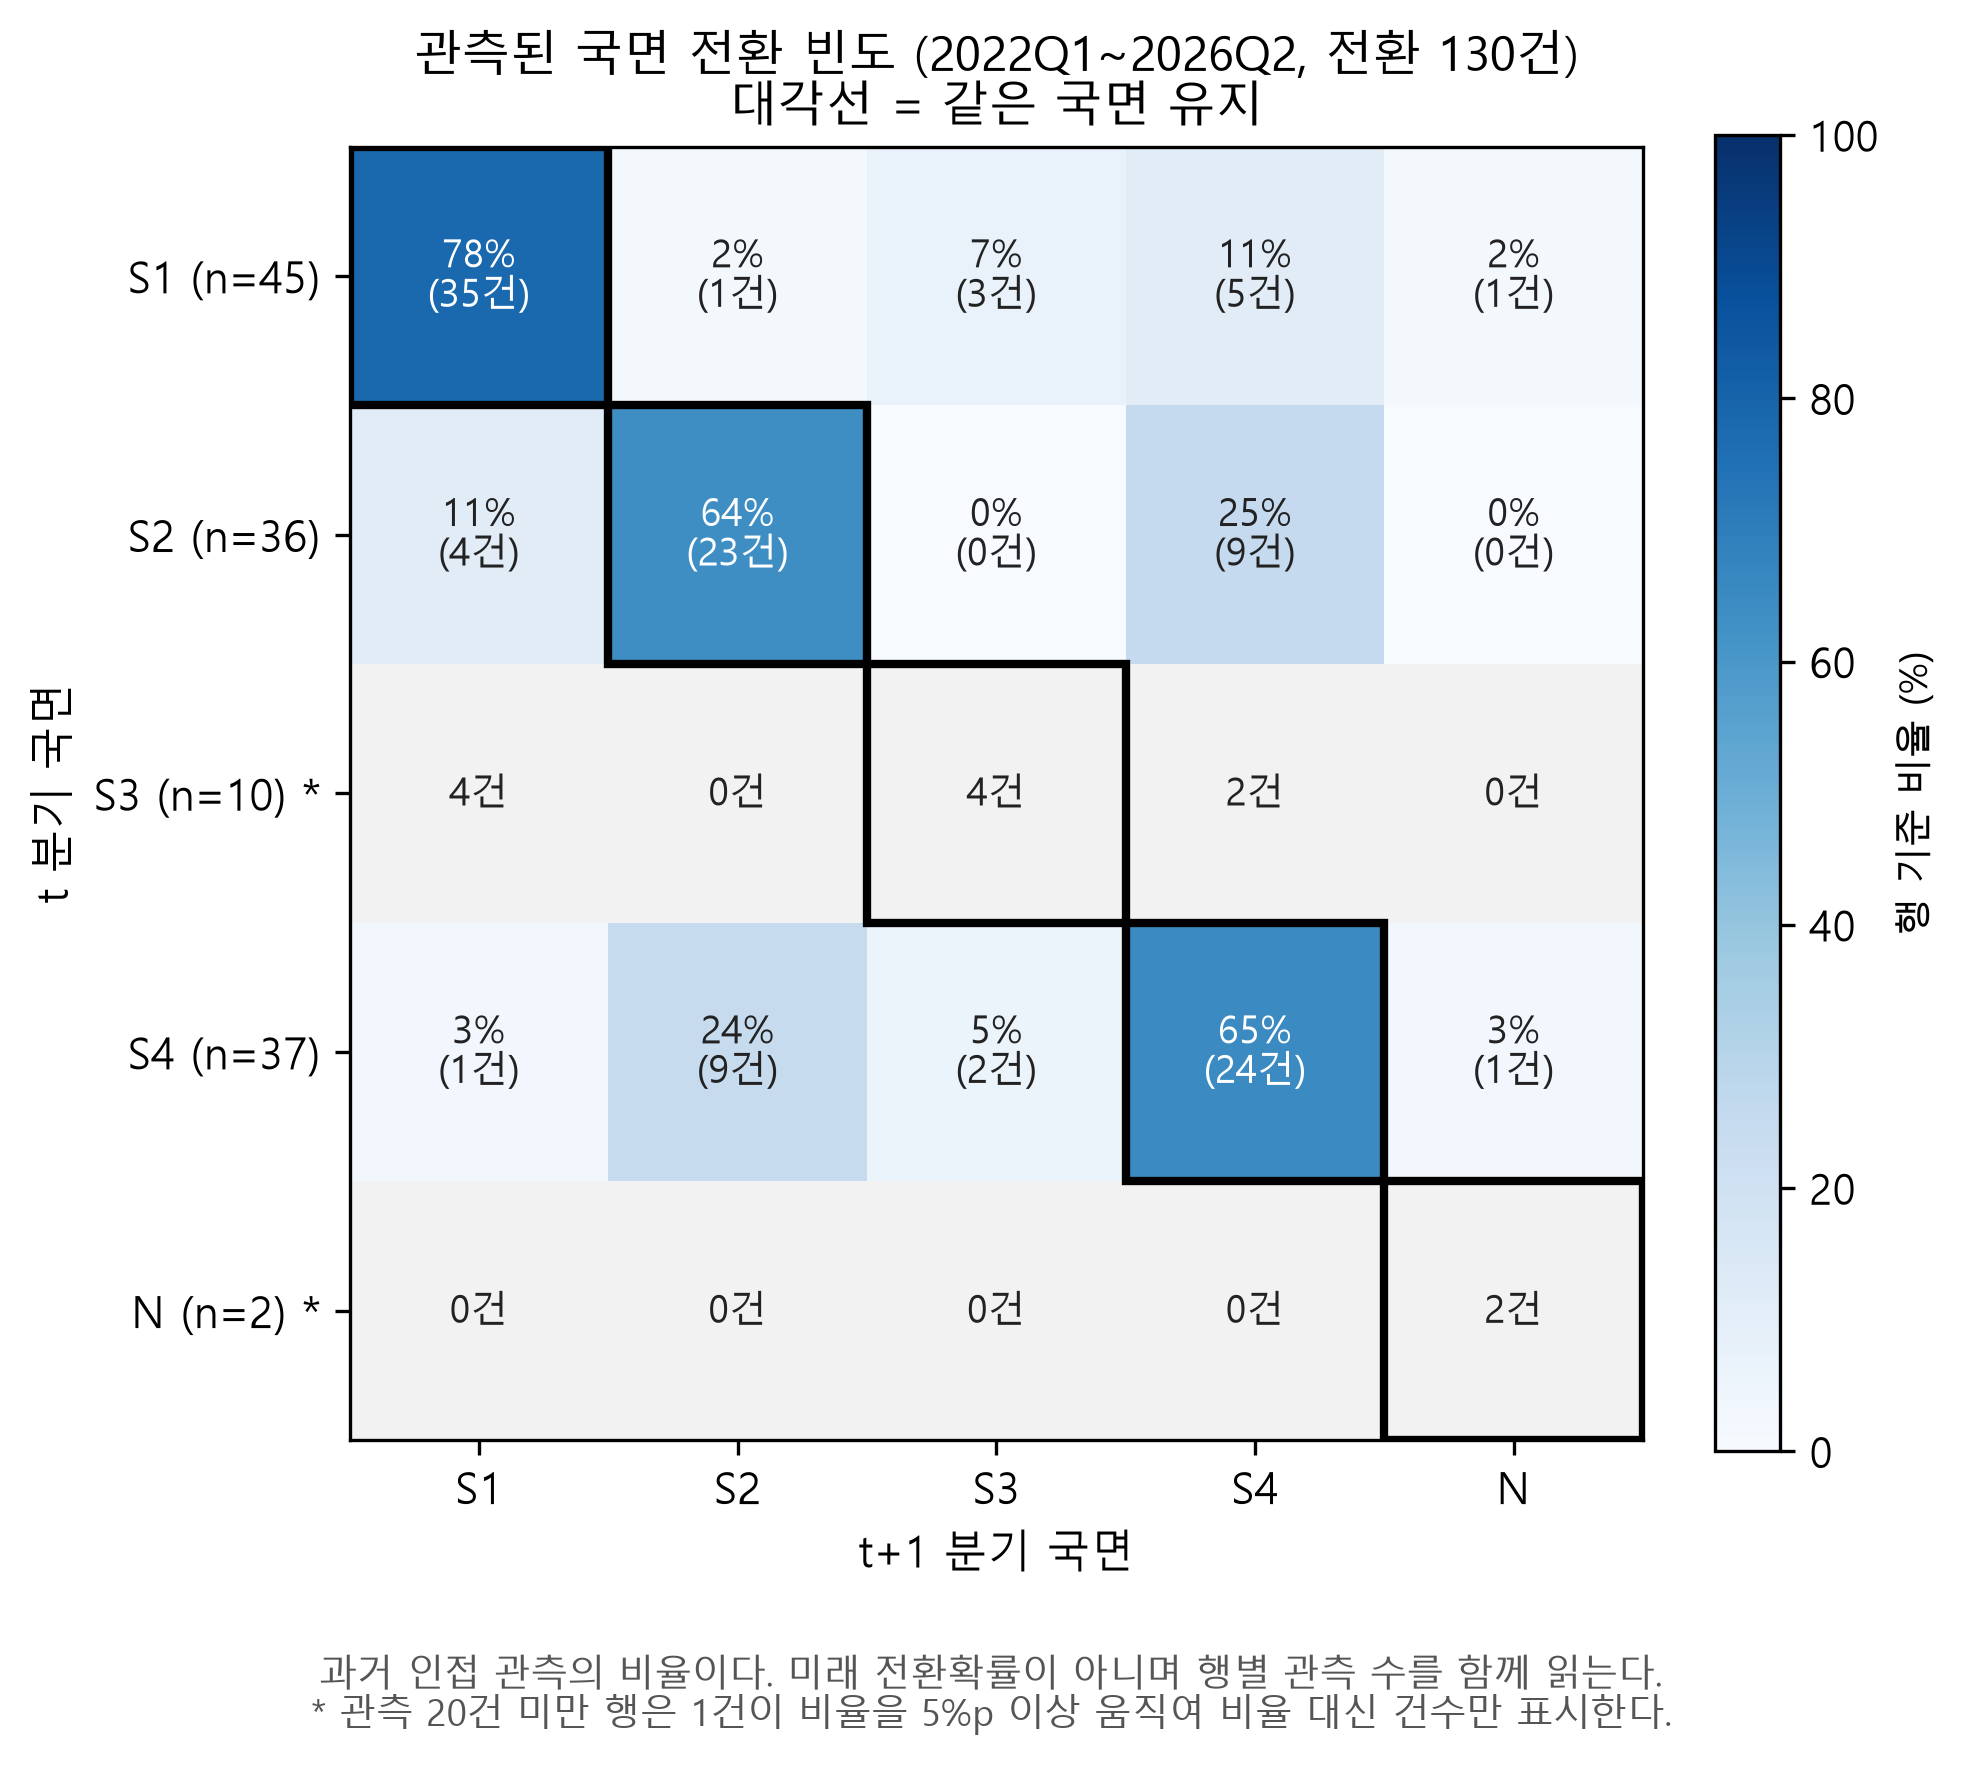

*outputs/final_model/01_core/figures/Q3C_전환행렬.png*

| 이전\현재 | S1 | S2 | S3 | S4 | N |
| --- | --- | --- | --- | --- | --- |
| S1 | 35 | 1 | 3 | 5 | 1 |
| S2 | 4 | 23 | 0 | 9 | 0 |
| S3 | 4 | 0 | 4 | 2 | 0 |
| S4 | 1 | 9 | 2 | 24 | 1 |
| N | 0 | 0 | 0 | 0 | 2 |

인접쌍 수=130, 유지 쌍 수=88, 비율=67.7%


In [18]:
# 인접 분기 국면 전환행렬(transition_type, valid_transition5 기준)을 표시한다
show_image('outputs/final_model/01_core/figures/Q3C_전환행렬.png', width=700)

vt5 = state[state.valid_transition5 == True]
split = vt5.transition_type.str.split('->', expand=True); split.columns = ['from', 'to']
mat = pd.crosstab(split['from'], split['to']).reindex(index=['S1', 'S2', 'S3', 'S4', 'N'], columns=['S1', 'S2', 'S3', 'S4', 'N']).fillna(0).astype(int)
show_table(mat.reset_index().rename(columns={'from': '이전\\현재'}), max_rows=5, digits=0)

stay = (split['from'] == split['to']).sum()
print(f"인접쌍 수={len(vt5)}, 유지 쌍 수={stay}, 비율={stay/len(vt5)*100:.1f}%")

**S2에서 S4로 간 전환이 9건, S4에서 S2로 간 전환도 9건이다.** 전환행렬은 과거 관측 빈도이며 다음 분기 전환확률로 읽지 않는다.

## 지속기간과 우측절단

- **S1~S4 연속구간 70개 중 39개(55.7%)가 2분기 이상 이어졌고 최장은 7분기다.**
- 2026년 2분기에 진행 중인 9개 run은 모두 관측 끝에 걸려 있어 실제 길이를 모른다.

아래 표는 연속구간 길이 분포와 2026년 2분기 업종별 현재 run을 보여준다.

In [19]:
# 국면 연속구간(run) 길이 분포와 2026Q2 업종별 현재 run 상태를 확인한다
runs = state.drop_duplicates('run_id')
runs_s = runs[runs.state.isin(['S1', 'S2', 'S3', 'S4'])]
len_dist = runs_s.run_total_length.value_counts().sort_index().reset_index()
len_dist.columns = ['길이', '구간 수']
show_table(len_dist, max_rows=len(len_dist), digits=0)
n2plus = (runs_s.run_total_length >= 2).sum()
print(f"구간 수={len(runs_s)}, 2분기 이상={n2plus} ({n2plus/len(runs_s)*100:.1f}%), 최장={runs_s.run_total_length.max():.0f}")

cur = state[state.quarter == '2026Q2'].sort_values('run_length', ascending=False)
show_table(cur[['industry', 'state', 'run_length', 'run_left_censored', 'run_right_censored']], max_rows=10)

| 길이 | 구간 수 |
| --- | --- |
| 1 | 31 |
| 2 | 14 |
| 3 | 14 |
| 4 | 7 |
| 6 | 1 |
| 7 | 3 |

구간 수=70, 2분기 이상=39 (55.7%), 최장=7


| industry | state | run_length | run_left_censored | run_right_censored |
| --- | --- | --- | --- | --- |
| 철강 | S2 | 4.00 | False | True |
| 비금속 | S2 | 3.00 | False | True |
| 기계 | S4 | 2.00 | False | True |
| 목재종이 | S4 | 2.00 | False | True |
| 기타 | S1 | 2.00 | False | True |
| 음식료 | S2 | 2.00 | False | True |
| 운송장비 | S2 | 2.00 | False | True |
| 석유화학 | S3 | 1.00 | False | True |
| 전기전자 | S2 | 1.00 | False | True |
| 섬유의복 | N | — | False | False |

**현재 가장 오래 이어진 국면은 철강의 S2 4분기다.** 우측절단이 걸린 run은 끝을 모르므로 "4분기 만에 끝났다"로 읽지 않는다.

## 결과와 해석 범위

**국면은 대체로 유지되지만 S2와 S4 사이의 이동이 잦다.** 인접쌍의 67.7%가 유지이고, S2↔S4 전환이 18건이다.

관측 가능한 최장 연속 블록이 7분기라 7분기 run은 실제 길이를 확정할 수 없다. 전환 빈도를 예측확률로 쓰지 않는다.

Q1~Q3는 각각 상태, 크기, 지속을 따로 보여준다. 다음 §7에서는 세 결과를 함께 볼 때 업종 판단이 어떻게 달라지는지 확인한다.

Source

- `outputs/final_model/01_core/figures/Q3C_전환행렬.png`
- `data/processed/kicox/changwon_state_panel.csv`
- `src/core/q3_state_analysis.py`

# 7. Q1~Q3 통합 — 한 관점만 볼 때와 셋을 볼 때

## 분석 질문

같은 업종×분기를 Q1만, Q1+Q2, Q1+Q2+Q3로 볼 때 판단은 어떻게 달라지고, Triage 단계와는 어떻게 이어지는가?

비교 사례는 2026년 2분기 기계·목재종이·철강과 2025년 2분기 섬유의복이다. 앞의 셋은 최신분기 단계가 갈린 사례이고, 섬유의복은 우선점검 진입용 최소 고용규모(규모 게이트; 현재 고용 300인 미만이면 우선점검에서 제외하는 조건)가 작동한 사례다.

## 네 사례 비교

- **Q1만 보면 기계·목재종이·섬유의복은 모두 S4이고 철강은 S2다.**
- Q2와 Q3를 더하면 규모와 지속의 차이가 드러나고, 단계는 E·R·A 신호와 규모 게이트가 정한다.

아래 표는 저장된 Triage 패널 값으로 네 사례를 단계별로 나열한다.

In [20]:
# 네 사례를 Q1만/Q1+Q2/Q1+Q2+Q3/Triage 단계로 나란히 비교한다
cases = [('기계', '2026Q2'), ('목재종이', '2026Q2'), ('철강', '2026Q2'), ('섬유의복', '2025Q2')]
recs = []
for ind, q in cases:
    r = triage[(triage.industry == ind) & (triage.quarter == q)].iloc[0]
    repeat = '반복 있음' if r.q3_repeated_signal else '반복 없음'
    recs.append({
        '사례': f'{ind} {q}',
        'Q1만(국면)': r.state,
        'Q1+Q2': f"{r.emp_delta:+,.0f}명 · {r.employment_share_pct:.2f}% · 기여 {r.contribution_pct:.2f}%",
        'Q1+Q2+Q3': f"{r.state} {r.run_length:.0f}분기 · {repeat}",
        'Triage 단계': r.stage,
        'E/R/A/P': f"E {r.E:.2f} / R {r.R:.2f} / A {r.A:.2f} / P {r.P:.2f}",
    })
show_table(pd.DataFrame(recs), max_rows=4)

for ind, q in cases:
    r = triage[(triage.industry == ind) & (triage.quarter == q)].iloc[0]
    print(f"{ind} {q} stage_reason: {r.stage_reason}")

| 사례 | Q1만(국면) | Q1+Q2 | Q1+Q2+Q3 | Triage 단계 | E/R/A/P |
| --- | --- | --- | --- | --- | --- |
| 기계 2026Q2 | S4 | -3,979명 · 51.19% · 기여 91.85% | S4 2분기 · 반복 없음 | 우선점검 | E 6.34 / R 2.70 / A 3.47 / P 19.55 |
| 목재종이 2026Q2 | S4 | -48명 · 0.37% · 기여 1.11% | S4 2분기 · 반복 있음 | 우선점검 | E 10.08 / R 6.45 / A 0.04 / P 12.90 |
| 철강 2026Q2 | S2 | -112명 · 8.44% · 기여 2.59% | S2 4분기 · 반복 없음 | 관찰 | E 1.14 / R 0.00 / A 0.10 / P 0.00 |
| 섬유의복 2025Q2 | S4 | -4명 · 0.03% · 기여 -0.14% | S4 2분기 · 반복 있음 | 추가확인 | E 10.53 / R 12.99 / A 0.00 / P 2.85 |

기계 2026Q2 stage_reason: 고용감소 6.3%(진입경계 5% 통과) · 산단 제조업 고용의 3.47% 감소(상위경계 2.0% 통과) → 보강: 생산 19.5% 감소
목재종이 2026Q2 stage_reason: 고용감소 10.1%(상위경계 10% 통과) · 산단평균 대비 6.4%p 열위(진입경계 통과) → 보강: 생산 12.9% 감소 / 직전 분기에도 진입신호(지속)
철강 2026Q2 stage_reason: 고용 축 진입신호 없음
섬유의복 2025Q2 stage_reason: 고용감소 10.5%(상위경계 10% 통과) · 산단평균 대비 13.0%p 열위(상위경계 통과) [상위경계 통과했으나 고용 34인 < 300인으로 우선점검 제외]


**국면이 같아도 단계는 다르고, 국면이 오래 이어져도 단계는 오르지 않는다.** 이 표는 저장 판정의 구성 요소를 나열할 뿐 네 사례의 실제 위험 정도를 비교하지 않는다.

| 사례 | 판단 |
|---|---|
| **기계 2026년 2분기** | **A 3.47%로 상위경계 통과, 생산 감소 19.55%로 보강 → 우선점검** |
| 목재종이 2026년 2분기 | E 10.08%로 상위경계 통과, 생산 감소 12.90%와 반복신호로 보강 → 우선점검 |
| 철강 2026년 2분기 | S2 국면 4분기 지속, E 1.14%로 진입경계 미달 → 관찰 |
| 섬유의복 2025년 2분기 | E 10.53%·R 12.99%p로 상위경계 통과, 고용 34명으로 우선점검 진입용 최소 고용규모(규모 게이트) 미달 → 추가확인 |

국면이 오래 이어진 것만으로는 단계가 올라가지 않는다.

## 결과와 해석 범위

**단계를 정하는 것은 국면이 아니라 고용 신호의 크기와 보강 조건이다.** Q1 국면은 확인 질문을, Q2는 규모와 처리 순서를, Q3는 반복 여부를 제공한다.

네 사례를 전형 사례로 일반화하지 않는다. 사례는 규칙의 작동을 보이기 위해 고른 것이다.

통합 비교는 세 관점을 한 규칙으로 묶을 필요를 보여준다. 다음 §8에서는 그 규칙을 맡는 주모형과 보조모형의 역할을 확인한다.

Source

- `outputs/final_model/02_triage/tables/triage_panel.csv`
- `notebooks/02_q1_q2_q3_integrated_analysis.ipynb` §6

# 8. 모형 구조 — 주모형 Triage와 보조모형 ELECTRE TRI-B / SMAA-TRI

## 분석 질문

180행 판정과 추가확인 재검토를 어느 모형이 맡고, 두 모형의 결과는 어떻게 연결되는가?

주모형 Triage는 180행 전체에 관찰·추가확인·우선점검을 배정한다. 보조모형 ELECTRE TRI-B(기준별로 경계 통과 여부를 따져 범주를 배정하는 비보상 다기준 분류)와 SMAA-TRI(가중치·경계 등 파라미터를 표집해 범주 수용도를 계산하는 방법)는 Triage 추가확인 35행만 다시 본다. 보조모형 결과는 원래 단계를 바꾸지 않는다.

## 두 모형의 입력 범위

- **Triage는 180행을 모두 판정하고, 보조모형은 그중 추가확인 35행만 재검토한다.**
- 보조모형 결과가 원래 단계를 덮어쓴 행은 0건이다.

아래 코드는 Triage 추가확인, 보조모형 원천 입력, 최종 재검토표의 업종·분기 키를 대조한다.

In [21]:
# Triage 추가확인, 보조모형 원천 입력, 재검토표의 업종x분기 키가 같은지 대조한다
check = rd('data/processed/final_model/electre_smaa_check_cases.csv')
add35 = triage[triage.stage == '추가확인']
key_add = set(zip(add35.industry, add35.quarter))
key_check = set(zip(check.industry, check.quarter))
key_review = set(zip(review.industry, review.quarter))
keys_equal = key_add == key_check == key_review
overwrite = int((review.triage_stage_preserved != '추가확인').sum())

summary = pd.DataFrame([
    {'단계': 'Triage 판정', '행 수': len(triage)},
    {'단계': '추가확인', '행 수': len(add35)},
    {'단계': '보조모형 원천 입력', '행 수': len(check)},
    {'단계': '재검토표', '행 수': len(review)},
    {'단계': '덮어쓰기', '행 수': overwrite},
])
show_table(summary, max_rows=5, digits=0)
print(f'세 키 집합 일치={keys_equal}')
assert keys_equal and overwrite == 0

| 단계 | 행 수 |
| --- | --- |
| Triage 판정 | 180 |
| 추가확인 | 35 |
| 보조모형 원천 입력 | 35 |
| 재검토표 | 35 |
| 덮어쓰기 | 0 |

세 키 집합 일치=True


**세 키 집합이 같고 덮어쓰기는 0건이다.** 이 대조는 경로가 규칙대로 연결됐다는 것만 확인하며 보조모형 판정이 옳은지는 알려주지 않는다.

| 모형 | 역할 | 장점 | 확인된 한계 | 사용 범위 |
|---|---|---|---|---|
| **Triage** | **주모형. 단계 판정** | 규칙이 명시적이고 재실행·감사가 쉽다 | 일부 임계값이 프로젝트 운영 값이고 사양에 민감하다(§10) | **180행 전체** |
| ELECTRE TRI-B | 보조모형. 추가확인 재검토 | 기준 간 보상을 막고 경계 구조를 드러낸다 | 자료개정 교란 C3b가 6개 조합 모두 0.95 미만이다(App F) | 추가확인 35행 |
| SMAA-TRI | 보조모형. 파라미터 민감도 표시 | 범주 수용도와 가능 단계를 공개한다 | 표집 공간에 조건부이고 위기확률이 아니다 | 추가확인 35행 |
| Q1~Q3 | 판정 입력·확인 질문 | 상태·규모·시간을 나눠 읽는다 | 단독으로 확인 순서를 정하지 않는다 | 180행 전체 |

패널 고정효과 회귀와 Isolation Forest는 미수행이다.

## 결과와 해석 범위

**판정은 Triage가 하고, 보조모형은 추가확인 안의 모형 간 불일치와 파라미터 민감도를 표시한다.** 두 모형은 같은 행을 두고 경쟁하지 않는다.

보조모형의 우선점검 수준(PRIORITY)을 Triage 우선점검 승격으로, 관찰 수준(OBSERVE)을 Triage 관찰 하향으로 읽지 않는다. 보조모형을 추가확인으로 한정한 근거는 §10에, 상세 검증은 Appendix F에 둔다.

모형 구조는 역할을 나눈다. 다음 §9에서는 주모형 Triage의 산식과 규칙, 판정 결과를 확인한다.

Source

- `outputs/final_model/03_electre_smaa/tables/electre_smaa_review_cases.csv`
- `data/processed/final_model/electre_smaa_check_cases.csv`
- `notebooks/04_model_evolution_and_experiments.ipynb` §I
- `reports/model_role_clarification.md`

# 9. 최종 Triage — 이번 분기에 먼저 확인할 업종

## 분석 질문

Q1~Q3 결과를 하나의 규칙으로 묶으면 어떤 업종×분기를 먼저 확인하게 되는가?

$$E=\max(0,-g^{emp}),\quad R=\max(0,-(g^{emp}-g^{mfg})),\quad A=\frac{\max(0,-\Delta emp)}{Emp^{mfg}}\times100,\quad P=\max(0,-g^{prod})$$

$g^{emp}$는 업종 고용 YoY(%), $g^{mfg}$는 산단 10개 제조업종 합계 고용 YoY, $\Delta emp$는 전년동기 대비 고용 증감 인원, $Emp^{mfg}$는 현재 10개 업종 고용 합계, $g^{prod}$는 명목 생산 YoY다. 진입경계는 E 5%·R 5%p·A 1%, 상위경계는 10%·10%p·2%다. 보강 조건은 P 5% 이상 또는 반복신호(직전 분기에도 E/R/A 진입신호)다. 우선점검은 상위신호와 보강 조건이 함께 있고 현재 고용이 300인 이상일 때만 배정한다.

## 판정 흐름과 규칙 상수

- **규칙 상수는 8개이고 규칙 버전은 `changwon-triage-rule/3.1.0-audited`다.**
- P는 단독으로 단계를 올리지 않는다. 300인 gate는 우선점검만 막고 추가확인 신호는 남긴다.

```text
입력: E·R·A(고용) · P(명목 생산) · 직전 분기 진입신호 · 현재 고용
 ├─ 핵심 고용정보(E·R·A·고용) 결측 ─────────────────────→ 자료확인
 ├─ 진입신호 없음(E<5, R<5, A<1) ────────────────────────→ 관찰
 └─ 진입신호 있음
     ├─ 상위신호(E≥10 또는 R≥10 또는 A≥2)
     │   AND 보강(P≥5 또는 직전 분기 진입신호)
     │   AND 현재 고용≥300 ───────────────────────────────→ 우선점검
     └─ 그 외 ──────────────────────────────────────────→ 추가확인
생산 YoY 결측 행: 확인 가능한 신호로 판정하고 품질 플래그를 붙인다
```

아래 표는 `src/triage/triage_rule.py`의 상수와 주석의 출처 표시를 읽어 온다.

In [22]:
# triage_rule.py 의 규칙 상수·출처 태그를 소스에서 읽고 apply_rule 기본값과 대조한다
import inspect, re as _re
from triage import triage_rule as tr

src = inspect.getsource(tr)
const_names = ['LEVEL_ENTRY', 'LEVEL_UP', 'REL_ENTRY', 'REL_UP', 'ABS_ENTRY', 'ABS_UP', 'PROD_SUPPORT', 'SCALE_MIN']
rows = []
for name in const_names:
    m = _re.search(rf'^{name}\s*=\s*([\d.]+)[ \t]*#[ \t]*([A-Z_]+):?[ \t]*([^\n]*)$', src, _re.MULTILINE)
    rows.append({'상수': name, '값': m.group(1), '출처 표시': m.group(2), '비고': m.group(3)})
show_table(pd.DataFrame(rows), max_rows=8)
print(f'RULE_VERSION={tr.RULE_VERSION}')

sig = inspect.signature(tr.apply_rule)
defaults = {p.name: p.default for p in sig.parameters.values() if p.default is not inspect.Parameter.empty}
match = (defaults['level_entry'] == tr.LEVEL_ENTRY and defaults['level_up'] == tr.LEVEL_UP and
         defaults['rel_entry'] == tr.REL_ENTRY and defaults['rel_up'] == tr.REL_UP and
         defaults['abs_entry'] == tr.ABS_ENTRY and defaults['abs_up'] == tr.ABS_UP and
         defaults['prod_support'] == tr.PROD_SUPPORT and defaults['scale_min'] == tr.SCALE_MIN)
print(f'apply_rule 기본값 == 상수: {match}')

| 상수 | 값 | 출처 표시 | 비고 |
| --- | --- | --- | --- |
| LEVEL_ENTRY | 5.0 | PRINCIPLE_ADAPTED | 피보험자·이동평균과 KICOX 분기말 고용은 다름 |
| LEVEL_UP | 10.0 | PRINCIPLE_ADAPTED | 법정 지역 지정이 아닌 내부 업종 점검 |
| REL_ENTRY | 5.0 | PRINCIPLE | 특별고용지원업종 제2조①1호(전국평균 대비 5%p) → 산단 제조업 평균 대비 |
| REL_UP | 10.0 | OWN | 조문에 상위 %p 기준 없음 |
| ABS_ENTRY | 1.0 | OWN | 고용 감소인원 ÷ 산단 제조업 고용 |
| ABS_UP | 2.0 | OWN |  |
| PROD_SUPPORT | 5.0 | PRINCIPLE | 선제대응 제2조③3호 생산액 5% |
| SCALE_MIN | 300 | PRINCIPLE | 선제대응 제2조①2호 '종사자 300인 이상' → 우선점검 진입요건으로만 |

RULE_VERSION=changwon-triage-rule/3.1.0-audited
apply_rule 기본값 == 상수: True


**`apply_rule`의 기본 인자는 표의 상수와 같다.** 위 흐름도는 이 함수의 분기 순서를 옮긴 것이며, 상수가 정책적으로 적절한지는 이 표로 판단하지 않는다.

## 규칙별 출처 성격

- **10개 규칙 중 5개는 PRINCIPLE_ADAPTED(외부 제도의 원리를 자료 단위에 맞게 옮긴 값), 5개는 PROJECT_OPERATIONAL(프로젝트 운영 값)이다.**
- 상수 단위로 보면 R 상위 10%p와 A 1%·2%는 조문 근거가 없는 OWN이다.

아래 표는 저장된 규칙 출처 표를 요약한다.

In [23]:
# 규칙별 출처 표(정의·임계값·역할·출처 구분)를 확인한다
prov = rd('outputs/final_model/02_triage/tables/triage_rule_provenance.csv')
prov_view = prov[['rule_name', 'definition', 'threshold', 'role', 'source_category']].rename(
    columns={'rule_name': '규칙', 'definition': '정의', 'threshold': '임계값', 'role': '역할', 'source_category': '출처구분'})
show_table(prov_view, max_rows=len(prov_view))
print(prov.source_category.value_counts().to_dict())

| 규칙 | 정의 | 임계값 | 역할 | 출처구분 |
| --- | --- | --- | --- | --- |
| E | max(0, -KICOX 분기말 고용 YoY) | 5% / 10% | 고용 진입·상위 신호 | PRINCIPLE_ADAPTED |
| R_entry | max(0, 산단 제조업 전체 YoY - 업종 YoY) | 5%p | 상대 열위 진입 | PRINCIPLE_ADAPTED |
| R_up | R과 동일 | 10%p | 상대 열위 상위 | PROJECT_OPERATIONAL |
| A | max(0, 전년동기 고용 - 현재 고용) / 현재 산단 제조업 고용 × 100 | 1% / 2% | 규모효과 진입·상위 | PROJECT_OPERATIONAL |
| P | max(0, -명목 분기 생산액 YoY) | 5% | 상위단계 보강 | PRINCIPLE_ADAPTED |
| repeated_employment_entry_signal | 현재 및 실제 직전 달력분기에 E/R/A 진입신호 존재 | 연속 2분기 | Q3 시간축 보강 | PRINCIPLE_ADAPTED |
| scale_gate | 현재 업종 고용이 기준 이상 | 300인 | 우선점검 진입만 제한 | PRINCIPLE_ADAPTED |
| ladder | 상위 고용신호 AND (P OR 반복) AND 규모; 아니면 진입신호 | 관찰 / 추가확인 / 우선점검 | 행동단계 | PROJECT_OPERATIONAL |
| missing | 핵심 E/R/A·고용 미확인 시 판정보류; P만 없으면 알려진 신호로 최소판정 | 보간 없음 | 자료품질 | PROJECT_OPERATIONAL |
| same_stage_rank | 같은 분기·단계에서 감소인원 내림차순, 동률 업종명 | 감소인원 | 처리순서 | PROJECT_OPERATIONAL |

{'PRINCIPLE_ADAPTED': 5, 'PROJECT_OPERATIONAL': 5}


**단위·기간·목적이 모두 같은 공식 기준(DIRECT_OFFICIAL)을 그대로 쓴 규칙은 없다.** 출처 구분은 값이 어디서 왔는지를 밝힐 뿐 값이 옳다는 근거가 아니다.

## 반복신호와 Q3 국면 지속의 차이

- **반복신호는 "직전 분기에도 E/R/A 진입신호"이고, Q3 run_length는 같은 국면이 이어진 분기 수다.**
- 철강 2026년 2분기는 S2가 4분기 이어졌지만 반복신호는 없다.

아래 표는 180행을 반복신호 여부와 Q3 지속 2분기 이상 여부로 교차 집계한다.

In [24]:
# 반복신호(q3_repeated_signal)와 Q3 지속구간을 교차 집계하고 엇갈린 행을 확인한다
q3c = rd('logs/validation/triage/q3_definition_comparison.csv')

def _bucket(x):
    if pd.isna(x):
        return '계산 불가(NaN)'
    return '2분기 이상' if x >= 2 else '1분기'
q3c['지속구간'] = q3c.q3_state_run_length.apply(_bucket)
cross = pd.crosstab(q3c.q3_repeated_signal, q3c['지속구간'], margins=True, margins_name='합계')
show_table(cross.reset_index().rename(columns={'q3_repeated_signal': '반복신호'}), max_rows=len(cross), digits=0)

comparable = q3c[q3c.q3_state_run_length.notna()]
disagree = comparable[((comparable.q3_repeated_signal == True) & (comparable.q3_state_run_length < 2)) |
                       ((comparable.q3_repeated_signal == False) & (comparable.q3_state_run_length >= 2))]
print(f'엇갈린 행 수={len(disagree)}, 비교 가능 행 수={len(comparable)}')

show_table(q3c[(q3c.industry == '철강') & (q3c.quarter == '2026Q2')], max_rows=1)
ex = comparable[(comparable.q3_repeated_signal == True) & (comparable.q3_state_run_length == 1)].iloc[[0]]
show_table(ex, max_rows=1)

| 반복신호 | 1분기 | 2분기 이상 | 계산 불가(NaN) | 합계 |
| --- | --- | --- | --- | --- |
| False | 56 | 65 | 20 | 141 |
| True | 14 | 21 | 4 | 39 |
| 합계 | 70 | 86 | 24 | 180 |

엇갈린 행 수=79, 비교 가능 행 수=156


| industry | quarter | q3_state_run_length | q3_transition | q3_repeated_signal | g4_delta00 | 지속구간 |
| --- | --- | --- | --- | --- | --- | --- |
| 철강 | 2026Q2 | 4.00 | S2 → S2 | False | 4 | 2분기 이상 |

| industry | quarter | q3_state_run_length | q3_transition | q3_repeated_signal | g4_delta00 | 지속구간 |
| --- | --- | --- | --- | --- | --- | --- |
| 기계 | 2022Q1 | 1.00 | 이전 또는 현재 상태 미확인 | True | 1 | 1분기 |

**두 정의가 엇갈리는 행이 절반가량이다.** 반복신호는 Q3 지속기간을 그대로 옮긴 값이 아니므로, Triage의 "반복"을 "국면이 오래 이어졌다"로 읽지 않는다.

## 결측 처리

- **생산 YoY가 없는 20행도 고용 신호로 판정하고 품질 플래그를 붙인다(부분 판정).**
- 핵심 고용정보가 없는 행은 없어서 자료확인은 0행이다.

아래 표는 생산 결측 20행의 단계 분포와 플래그를 보여준다.

In [25]:
# 생산 YoY 결측 20행의 분기x단계 분포와 품질 플래그를 확인한다
pm = triage[triage.data_quality_production_missing == True]
show_table(pd.crosstab(pm.quarter, pm.stage).reset_index(), max_rows=len(pm.quarter.unique()), digits=0)
print(f"행 수={len(pm)}, data_quality_minimum_only={int(pm.data_quality_minimum_only.sum())}, "
      f"자료확인(datarev)={int(pm.datarev.sum())}, data_quality_core_missing={int(pm.data_quality_core_missing.sum())}")

| quarter | 관찰 | 우선점검 | 추가확인 |
| --- | --- | --- | --- |
| 2023Q4 | 7 | 1 | 2 |
| 2024Q4 | 8 | 0 | 2 |

행 수=20, data_quality_minimum_only=0, 자료확인(datarev)=0, data_quality_core_missing=0


**생산 결측 20행 중 우선점검은 1행이고 나머지는 관찰과 추가확인이다.** 결측 구간의 생산이 실제로 어땠는지 모르므로 이 행들의 단계는 확인 가능한 신호만으로 낸 최소 판정이다.

## 전체 기간 단계 분포

- **180행은 관찰 128건, 추가확인 35건, 우선점검 17건으로 나뉜다.**
- 우선점검 17건 중 9건이 기계다.

아래 그림은 분기별 단계 구성을 누적 막대로 보여준다. 색은 단계다.

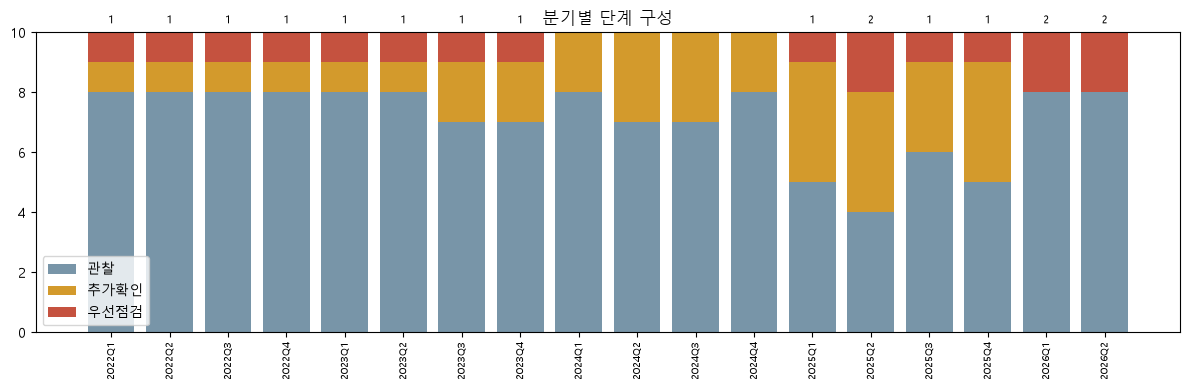

| industry | 관찰 | 추가확인 | 우선점검 |
| --- | --- | --- | --- |
| 기계 | 9 | 0 | 9 |
| 기타 | 10 | 8 | 0 |
| 목재종이 | 10 | 6 | 2 |
| 비금속 | 12 | 6 | 0 |
| 석유화학 | 17 | 0 | 1 |
| 섬유의복 | 7 | 11 | 0 |
| 운송장비 | 17 | 1 | 0 |
| 음식료 | 13 | 0 | 5 |
| 전기전자 | 15 | 3 | 0 |
| 철강 | 18 | 0 | 0 |

In [26]:
# 분기별 단계 구성 누적막대와 업종x단계 교차표를 확인한다
q_stage = pd.crosstab(triage.quarter, triage.stage).reindex(columns=['관찰', '추가확인', '우선점검'], fill_value=0)
q_stage = q_stage.reindex(sorted(q_stage.index))

fig, ax = plt.subplots(figsize=(12, 4))
bottom = pd.Series(0, index=q_stage.index)
for s in ['관찰', '추가확인', '우선점검']:
    ax.bar(q_stage.index, q_stage[s], bottom=bottom, color=STAGE_COLORS[s], label=s)
    bottom = bottom + q_stage[s]
for i, q in enumerate(q_stage.index):
    n = q_stage.loc[q, '우선점검']
    if n > 0:
        ax.text(i, bottom.loc[q] + 0.3, str(int(n)), ha='center', fontsize=8)
ax.set_xticks(range(len(q_stage.index))); ax.set_xticklabels(q_stage.index, rotation=90, fontsize=7)
ax.legend(); ax.set_title('분기별 단계 구성')
plt.tight_layout(); plt.show()

ind_stage = pd.crosstab(triage.industry, triage.stage).reindex(columns=['관찰', '추가확인', '우선점검'], fill_value=0)
show_table(ind_stage.reset_index(), max_rows=10, digits=0)

**우선점검은 2022~2023년에는 기계, 2025~2026년에는 음식료·목재종이·석유화학·기계에 나타나고, 2024년에는 없다.** 과거 분기의 단계는 현재 규칙으로 다시 계산한 후향 재구성이며 당시 실제 운영 판정이 아니다.

## 업종×분기 단계 지도

- **같은 업종도 분기마다 단계가 바뀐다.**
- 철강은 18분기 모두 관찰이고, 섬유의복은 추가확인이 11분기다.

아래 그림은 업종×분기별 단계를 한 격자에 표시한다. 색은 단계를 나타낸다.

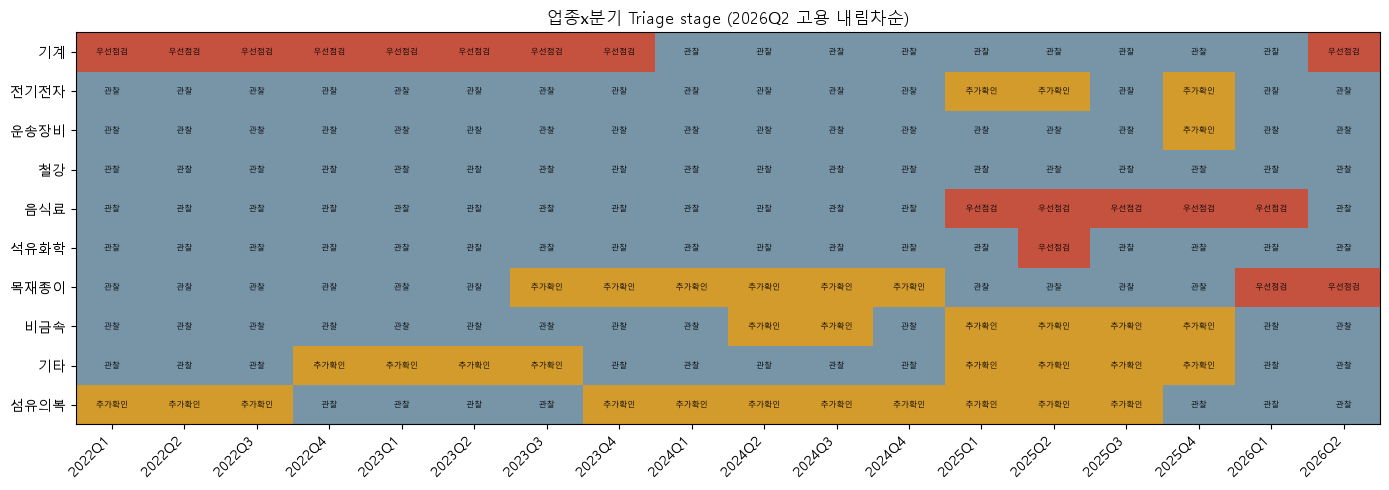

In [27]:
# 업종x분기 단계 격자(03 notebook과 같은 방식)를 그린다. 업종 순서는 2026Q2 고용 내림차순.
from matplotlib.colors import ListedColormap
order_ind = triage[triage.quarter == '2026Q2'].sort_values('employment', ascending=False)['industry'].tolist()
grid = triage.pivot(index='industry', columns='quarter', values='stage').reindex(order_ind)
stage_map = {s: i for i, s in enumerate(STAGE_ORDER)}
z = grid.map(lambda x: stage_map.get(x, 3)).to_numpy()
fig, ax = plt.subplots(figsize=(14, 5))
ax.imshow(z, aspect='auto', cmap=ListedColormap([STAGE_COLORS[s] for s in STAGE_ORDER]), vmin=0, vmax=3)
ax.set_xticks(range(len(grid.columns))); ax.set_xticklabels(grid.columns, rotation=45, ha='right')
ax.set_yticks(range(len(grid.index))); ax.set_yticklabels(grid.index)
for i in range(z.shape[0]):
    for j in range(z.shape[1]):
        ax.text(j, i, grid.iloc[i, j], ha='center', va='center', fontsize=6)
ax.set_title('업종x분기 Triage stage (2026Q2 고용 내림차순)')
plt.tight_layout(); plt.show()

**단계는 업종에 고정되지 않고 분기별 확인 대기열처럼 움직인다.** 이 그림은 단계의 이동을 보여주지만 단계가 실제 위기 여부와 맞는지는 알려주지 않는다.

## 결과와 해석 범위

**Triage는 180행 중 17행을 우선점검, 35행을 추가확인으로 배정했고, 2026년 2분기 우선점검은 기계와 목재종이다.** 두 업종은 우선점검에 이른 경로가 다르다. 기계는 A 규모 신호와 생산 감소로, 목재종이는 E 비율 신호와 생산 감소·반복신호로 올라왔다.

단계를 위기 확정이나 지원대상 선정으로 읽지 않는다. 임계값 일부는 운영 값이고, 반복신호는 Q3 지속기간과 정의가 다르다.

Triage는 규칙과 결과를 보여준다. 다음 §10에서는 이 결과가 규칙 사양, 결측 처리, 시점분리 검증에서 어떻게 달라지는지 확인한다.

Source

- `src/triage/triage_rule.py`
- `src/triage/run_triage.py`
- `outputs/final_model/02_triage/tables/triage_panel.csv`
- `outputs/final_model/02_triage/tables/triage_rule_provenance.csv`
- `logs/validation/triage/q3_definition_comparison.csv`

# 10. 검증 — 규칙 사양, 결측 처리, 시점분리, 재현성

## 분석 질문

Triage 판정은 규칙 사양과 결측 처리에 얼마나 민감하고, 사후 자료로 보면 무엇을 구분하며, 같은 입력에서 같은 결과가 나오는가?

이 절에서 새로 계산하는 것은 15개 사양 재실행 하나다. `compute_axes`·`apply_rule`로 baseline과 사양별 판정을 다시 만들고 저장된 민감도 표와 셀 단위로 대조한다. 시점분리 검증과 결측 비교는 저장된 결과를 읽는다. 균형 정확도(BA; balanced accuracy)는 양성·음성 적중률의 평균이다. 여기서는 2분기 뒤 추가수축 예측을 측정하므로, 현재 담당자가 먼저 확인할 업종을 선별하는 Triage의 운영 목적과 구분해 해석한다.

**10.1 15개 사양 재실행.** 확인할 내용: 저장 입력에서 baseline과 15개 변형 사양을 다시 계산한 결과가 `sensitivity_own_rules.csv`와 모든 셀에서 같은지.

In [28]:
# 유일한 재계산: compute_axes/apply_rule로 baseline·15개 변형 사양을 다시 만들어 저장본과 셀 단위 대조한다
from triage import triage_rule as tr

W0, W1 = '2022Q1', '2026Q2'
def window(d): return d[d.quarter.between(W0, W1)].copy()
def canonical(d): return d.sort_values(['industry', 'quarter']).reset_index(drop=True)

master_axes = tr.compute_axes(rd('data/processed/kicox/changwon_industry_master.csv'))
state_cols = ['industry', 'quarter', 'state', 'run_length', 'transition_type', 'previous_state',
              'production_yoy_reason', 'production_current_missing', 'production_lag4_missing',
              'employment_yoy_reason']
base = master_axes.merge(state[state_cols], on=['industry', 'quarter'], how='left', validate='one_to_one')
baseline = canonical(window(tr.apply_rule(base)))

tri_sorted = canonical(triage)
assert len(baseline) == 180
assert baseline.stage.value_counts().reindex(tr.STAGES, fill_value=0).equals(
    tri_sorted.stage.value_counts().reindex(tr.STAGES, fill_value=0))
assert (baseline.stage.values == tri_sorted.stage.values).all()

variants = {
    'A 0.5/1': dict(abs_entry=.5, abs_up=1),
    'A 1/2': {},
    'A 2/4': dict(abs_entry=2, abs_up=4),
    'A 제거': dict(abs_entry=np.inf, abs_up=np.inf),
    '규모 200': dict(scale_min=200),
    '규모 300': {},
    '규모 500': dict(scale_min=500),
    '규모 1000': dict(scale_min=1000),
    'gate 없음': dict(gate='none'),
    'hard exclusion': dict(gate='hard'),
    'flag 정렬만': dict(gate='flag'),
    'Q3 제거': dict(use_persist=False),
    'P 제거': dict(use_prod=False),
    '완전 자료확인': dict(missing_policy='complete'),
    'R 상위 제거': dict(rel_up=np.inf),
}  # src/triage/triage_audit.py variants dict과 동일 (04 notebook PART E)

variant_frames = {}
own_rows = []
for label, kw in variants.items():
    v = canonical(window(tr.apply_rule(base, **kw)))
    variant_frames[label] = v
    changed = baseline.stage.ne(v.stage)
    priority_changed = baseline.stage.eq('우선점검').ne(v.stage.eq('우선점검'))
    latest_changed = changed & baseline.quarter.eq(baseline.quarter.max())
    counts = v.stage.value_counts()
    own_rows.append({'variant': label, 'changed_rows': int(changed.sum()),
                      'priority_changed_rows': int(priority_changed.sum()),
                      'latest_changed_rows': int(latest_changed.sum()),
                      **{s: int(counts.get(s, 0)) for s in tr.STAGES + ('규모미달',)}})
own_rerun = pd.DataFrame(own_rows)

merged = own.merge(own_rerun, on='variant', suffixes=('_saved', '_rerun'))
num_cols = [c for c in own.columns if c != 'variant']
n_cells = len(merged) * len(num_cols)
mismatches = []
for c in num_cols:
    bad = merged[merged[f'{c}_saved'].astype(int) != merged[f'{c}_rerun'].astype(int)]
    for _, r in bad.iterrows():
        mismatches.append({'variant': r['variant'], '열': c, '저장값': r[f'{c}_saved'], '재실행값': r[f'{c}_rerun']})
n_mismatch = len(mismatches)
if n_mismatch:
    show_table(pd.DataFrame(mismatches), max_rows=len(mismatches))
assert n_mismatch == 0
print(f'비교 사양 15 | 비교 셀 {n_cells} | 불일치 {n_mismatch}')

비교 사양 15 | 비교 셀 120 | 불일치 0


**관찰.** 재실행 baseline은 저장된 Triage 패널과 180행 모두 같고, 15개 사양의 모든 비교 셀이 저장본과 일치했다.

## 사양별 변경 건수

- **A 경계를 2%·4%로 올리면 우선점검은 17건에서 11건으로 줄고, 규모 게이트를 없애면 41건으로 는다.**
- 기준을 뺐을 때는 A 제거 9행, Q3 제거 8행, P 제거 4행, R 상위 제거 1행이 바뀐다.

아래 표는 사양을 "기준값 변경"과 "기준을 뺐을 때"로 나눠 변경 건수와 단계 분포를 보여준다.

In [29]:
# 사양을 세 구분으로 나눠 변경 건수·단계 분포를 보고, 2026Q2 baseline 대비 단계가 바뀐 업종을 확인한다
def _group(v):
    if v in {'A 제거', 'Q3 제거', 'P 제거', 'R 상위 제거'}:
        return '기준을 뺐을 때'
    if v in {'A 1/2', '규모 300'}:
        return '기준(=baseline)'
    return '기준값·방식 변경'
own_rerun['구분'] = own_rerun.variant.apply(_group)
group_order = {'기준(=baseline)': 0, '기준값·방식 변경': 1, '기준을 뺐을 때': 2}
own_rerun['_o'] = own_rerun['구분'].map(group_order)
tbl = own_rerun.sort_values('_o').rename(columns={'variant': '사양', 'changed_rows': '변경 행',
    'priority_changed_rows': '우선점검 변경', 'latest_changed_rows': '2026Q2 변경'})
show_table(tbl[['구분', '사양', '변경 행', '우선점검 변경', '2026Q2 변경', '우선점검', '추가확인', '관찰', '자료확인', '규모미달']],
           max_rows=len(tbl), digits=0)

base_2026 = baseline[baseline.quarter == '2026Q2'].set_index('industry')['stage']
rows2026 = []
for label, v in variant_frames.items():
    v_2026 = v[v.quarter == '2026Q2'].set_index('industry')['stage']
    diff = base_2026[base_2026 != v_2026]
    for ind in diff.index:
        rows2026.append({'사양': label, '업종': ind, 'baseline': base_2026[ind], '변형': v_2026[ind]})
show_table(pd.DataFrame(rows2026), max_rows=len(rows2026))

| 구분 | 사양 | 변경 행 | 우선점검 변경 | 2026Q2 변경 | 우선점검 | 추가확인 | 관찰 | 자료확인 | 규모미달 |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| 기준(=baseline) | A 1/2 | 0 | 0 | 0 | 17 | 35 | 128 | 0 | 0 |
| 기준(=baseline) | 규모 300 | 0 | 0 | 0 | 17 | 35 | 128 | 0 | 0 |
| 기준값·방식 변경 | A 2/4 | 6 | 6 | 1 | 11 | 41 | 128 | 0 | 0 |
| 기준값·방식 변경 | A 0.5/1 | 5 | 2 | 0 | 19 | 36 | 125 | 0 | 0 |
| 기준값·방식 변경 | 규모 500 | 2 | 2 | 1 | 15 | 37 | 128 | 0 | 0 |
| 기준값·방식 변경 | 규모 200 | 4 | 4 | 0 | 21 | 31 | 128 | 0 | 0 |
| 기준값·방식 변경 | 규모 1000 | 8 | 8 | 1 | 9 | 43 | 128 | 0 | 0 |
| 기준값·방식 변경 | gate 없음 | 24 | 24 | 0 | 41 | 11 | 128 | 0 | 0 |
| 기준값·방식 변경 | flag 정렬만 | 24 | 24 | 0 | 41 | 11 | 128 | 0 | 0 |
| 기준값·방식 변경 | hard exclusion | 66 | 0 | 3 | 17 | 4 | 93 | 0 | 66 |
| 기준값·방식 변경 | 완전 자료확인 | 20 | 1 | 0 | 16 | 31 | 113 | 20 | 0 |
| 기준을 뺐을 때 | A 제거 | 9 | 9 | 1 | 8 | 40 | 132 | 0 | 0 |
| 기준을 뺐을 때 | Q3 제거 | 8 | 8 | 0 | 9 | 43 | 128 | 0 | 0 |
| 기준을 뺐을 때 | P 제거 | 4 | 4 | 1 | 13 | 39 | 128 | 0 | 0 |
| 기준을 뺐을 때 | R 상위 제거 | 1 | 1 | 0 | 16 | 36 | 128 | 0 | 0 |

| 사양 | 업종 | baseline | 변형 |
| --- | --- | --- | --- |
| A 2/4 | 기계 | 우선점검 | 추가확인 |
| A 제거 | 기계 | 우선점검 | 추가확인 |
| 규모 500 | 목재종이 | 우선점검 | 추가확인 |
| 규모 1000 | 목재종이 | 우선점검 | 추가확인 |
| hard exclusion | 기타 | 관찰 | 규모미달 |
| hard exclusion | 비금속 | 관찰 | 규모미달 |
| hard exclusion | 섬유의복 | 관찰 | 규모미달 |
| P 제거 | 기계 | 우선점검 | 추가확인 |

**기준을 뺀 네 실험은 모두 우선점검을 줄이는 방향으로만 작동한다.** 변경이 적다는 것은 결과가 덜 흔들린다는 뜻일 뿐 그 기준이 옳다는 뜻은 아니다.

**10.2 결측 방식과 이력 경계.** 확인할 내용: 생산 결측 20행을 모두 자료확인으로 돌리는 완전자료 방식에서 무엇이 바뀌는지, 원래 v3 판정 재현본과 달라지는 행이 있는지.

In [30]:
# 완전자료 방식에서 바뀌는 행과 v3 재현본과 달라지는 행을 확인한다
mc = rd('logs/validation/triage/missingness_comparison.csv')
mc_changed = mc[mc.changed == True]
print(f'changed 행 수={len(mc_changed)}')
print('원래 stage 분포:', mc_changed.stage.value_counts().to_dict())
print('complete_stage 분포:', mc_changed.complete_stage.value_counts().to_dict())

hb = rd('logs/validation/triage/history_boundary_changed_rows.csv')
show_table(hb[['industry', 'quarter', 'E', 'R', 'A', 'P', 'persist', 'stage', 'stage_reason']], max_rows=len(hb))

changed 행 수=20
원래 stage 분포: {'관찰': 15, '추가확인': 4, '우선점검': 1}
complete_stage 분포: {'자료확인': 20}


| industry | quarter | E | R | A | P | persist | stage | stage_reason |
| --- | --- | --- | --- | --- | --- | --- | --- | --- |
| 기계 | 2022Q1 | 3.67 | 3.91 | 2.04 | 0.00 | True | 우선점검 | 산단 제조업 고용의 2.04% 감소(상위경계 2.0% 통과) → 보강: 직전 분기에도 진입신호(지속) |

**관찰.** 완전자료 방식에서는 생산 결측 20행이 모두 자료확인으로 바뀐다. 원래 v3 판정 재현본과 달라지는 행은 기계 2022년 1분기 한 행이며, 이 행은 분석창 직전 분기의 진입신호를 반복신호로 쓴다.

## 해석의 범위

임계값 중 A 1%·2%와 R 상위 10%p는 조문 근거가 없는 프로젝트 운영 값이다.
**A 경계를 2%·4%로 올리면 우선점검은 17건에서 11건으로 줄어든다.**
따라서 우선점검 목록은 현재 임계값 아래의 결과다. 2026년 2분기 기계는 A 경계 변화에 민감하다. 목재종이는 현재 고용 428명으로 300인 규모 기준에는 128명의 여유가 있으며, 더 직접적인 민감성은 E 10% 상위경계다. 48명 감소는 10.08%지만 47명 감소라면 9.87%가 되어 상위경계를 벗어난다. 사양별 변화는 Appendix G에 둔다.

**10.3 시점분리 검증.** 확인할 내용: 각 분기에 그 시점까지의 자료로 판정한 뒤 2분기 뒤 고용위축 대리지표가 나타났는지를 보았을 때, Triage와 ELECTRE가 양성을 얼마나 구분했는지.

## 주 비교

- **2분기 뒤 고용위축 대리지표를 두 모형 모두 뚜렷하게 구분하지 못했다(BA 0.47, 0.44).**
- 공통 140행, 양성 58행에서 Triage는 43행을 선별해 16행을, ELECTRE는 67행을 선별해 24행을 포착했다.

아래 표는 저장된 주 비교 결과와 참고선(항상 비선별, 항상 선별, 현재 고용 YoY 음수)을 함께 보여준다.

In [31]:
# 시점분리 주 비교(MAIN)와 참고선(BENCHMARKS)을 함께 표시한다
mm = metrics_long[metrics_long.record_type == 'model_metrics']
main2 = mm[(mm.experiment == 'MAIN') & (mm.cutoff == 1) & (mm['groupby'] == 'pooled')]
bench3 = mm[(mm.experiment == 'BENCHMARKS') & (mm['groupby'] == 'pooled')]
rows_rb = pd.concat([main2, bench3])
name_map = {'electre_fixed': 'ELECTRE 고정판정', 'triage_final': 'Triage 최종', 'always_none': '항상 비선별',
            'always_all': '항상 선별', 'current_negative_e_yoy': '현재 고용 YoY<0'}
rows_rb = rows_rb.assign(모형=rows_rb.model.map(name_map))
show_table(rows_rb[['모형', 'N', 'positives', 'TP', 'FP', 'FN', 'TN', 'recall', 'precision', 'FPR',
                     'balanced_accuracy', 'alert_rate']].rename(columns={'positives': '양성', 'balanced_accuracy': 'BA', 'alert_rate': '선별비율'}),
           max_rows=len(rows_rb))

report_rolling = (ROOT / 'logs/validation/outputs/rolling_backtest/REPORT.md').read_text(encoding='utf-8')
print(f"REPORT.md에 'TRADE_OFF / NO_GENERAL_WINNER' 포함={'TRADE_OFF / NO_GENERAL_WINNER' in report_rolling}")

| 모형 | N | 양성 | TP | FP | FN | TN | recall | precision | FPR | BA | 선별비율 |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| ELECTRE 고정판정 | 140 | 58 | 24.00 | 43.00 | 34.00 | 39.00 | 0.41 | 0.36 | 0.52 | 0.44 | 0.48 |
| Triage 최종 | 140 | 58 | 16.00 | 27.00 | 42.00 | 55.00 | 0.28 | 0.37 | 0.33 | 0.47 | 0.31 |
| 항상 비선별 | 140 | 58 | 0.00 | 0.00 | 58.00 | 82.00 | 0.00 | — | 0.00 | 0.50 | 0.00 |
| 항상 선별 | 140 | 58 | 58.00 | 82.00 | 0.00 | 0.00 | 1.00 | 0.41 | 1.00 | 0.50 | 1.00 |
| 현재 고용 YoY<0 | 140 | 58 | 29.00 | 45.00 | 29.00 | 37.00 | 0.50 | 0.39 | 0.55 | 0.48 | 0.53 |

REPORT.md에 'TRADE_OFF / NO_GENERAL_WINNER' 포함=True


**두 모형의 BA는 모두 무작위 기대값 0.5보다 낮다.** 이 결과는 같은 KICOX 고용 계열로 만든 대리지표 기준이며, 현장 위기 여부와 일치하는지는 알려주지 않는다.

## 규모별 층

- **300인 미만 층에서 Triage의 recall은 32%로 ELECTRE 64%의 절반이고, FPR은 70.37%로 ELECTRE 85.19%보다 낮다.**
- 300인 이상 층에서는 두 모형 모두 8행을 포착해 recall이 같다.

아래 표는 저장된 판정·결과 행을 현재 고용 300인 기준으로 나눠 다시 센 것이다.

In [32]:
# 현재 고용 300인 기준 층별로 recall·FPR을 다시 계산한다
el_sub = eval_long[(eval_long.experiment == 'MAIN') & (eval_long.cutoff == 1) &
                    (eval_long.scope == 'paired') & (eval_long.included == True)]
el_m = el_sub.merge(triage[['industry', 'quarter', 'employment']], on=['industry', 'quarter'], how='left')
el_m['층'] = np.where(el_m.employment < 300, '300인 미만', '300인 이상')

rows_st = []
for stratum, d0 in el_m.groupby('층'):
    for model, d in d0.groupby('model'):
        tp = (d.error_type == 'TP').sum(); fp = (d.error_type == 'FP').sum()
        fn = (d.error_type == 'FN').sum(); tn = (d.error_type == 'TN').sum()
        rows_st.append({'층': stratum, '모형': model, 'TP': tp, 'FP': fp, 'FN': fn, 'TN': tn,
                         'recall': round(tp / (tp + fn) * 100, 2) if (tp + fn) else np.nan,
                         'FPR': round(fp / (fp + tn) * 100, 2) if (fp + tn) else np.nan})
strat_tbl = pd.DataFrame(rows_st)
show_table(strat_tbl, max_rows=len(strat_tbl))

lt300 = strat_tbl[strat_tbl['층'] == '300인 미만'].set_index('모형')
print(f"REPORT.md 값과 일치: recall ELECTRE={lt300.loc['electre_fixed','recall']}% (64%), "
      f"Triage={lt300.loc['triage_final','recall']}% (32%), "
      f"FPR ELECTRE={lt300.loc['electre_fixed','FPR']}% (85.19%), Triage={lt300.loc['triage_final','FPR']}% (70.37%)")

| 층 | 모형 | TP | FP | FN | TN | recall | FPR |
| --- | --- | --- | --- | --- | --- | --- | --- |
| 300인 미만 | electre_fixed | 16 | 23 | 9 | 4 | 64.00 | 85.19 |
| 300인 미만 | triage_final | 8 | 19 | 17 | 8 | 32.00 | 70.37 |
| 300인 이상 | electre_fixed | 8 | 20 | 25 | 35 | 24.24 | 36.36 |
| 300인 이상 | triage_final | 8 | 8 | 25 | 47 | 24.24 | 14.55 |

REPORT.md 값과 일치: recall ELECTRE=64.0% (64%), Triage=32.0% (32%), FPR ELECTRE=85.19% (85.19%), Triage=70.37% (70.37%)


**두 모형의 포착 차이 8행은 모두 300인 미만 층에서 생긴다.** 이 층에서는 두 모형 모두 오탐 비율이 70%를 넘어, recall 차이만으로 규모 게이트의 득실을 판단하지 않는다.

**2분기 뒤 고용위축 대리지표를 두 모형 모두 뚜렷하게 구분하지 못했다(BA 0.47, 0.44).** Triage는 점검 범위가 좁은 대신 포착도 적었고 일반적 우열은 판단할 수 없다. Triage는 미래 예측모형이 아니라 이번 분기 확인 순서를 정하는 규칙이다.

대리지표는 판정 입력과 같은 KICOX 고용 계열로 만들었다. 패널은 당시 공표값이 아니라 사후에 재구축한 값이다. 140행은 같은 산단의 반복 관측이라 서로 독립인 사건 140개가 아니다. 층별·업종 제외 결과는 Appendix H에 둔다.

## 보조모형 범위를 추가확인으로 한정한 근거

- **자료개정 교란 C3b는 6개 조합 모두 사전 기준 0.95 미만이다(최대 0.938359).**
- 독립감사는 이전 지적 14건 중 CONFIRMED 5건, PARTIALLY_CONFIRMED 6건을 남기고 최종 판단을 HYBRID(단일 등급 자동 판정으로 쓰지 않음)로 냈다.
- 시점분리 검증에서 ELECTRE도 BA 0.4447로 대리지표를 구분하지 못했고 선별 범위는 67행으로 Triage보다 넓었다.

세 결과는 ELECTRE를 180행 자동 판정에 쓸 근거가 부족하다는 것을 보여주며, 상세는 Appendix F에 둔다.

**10.4 재현성.** 확인할 내용: 핵심 산출물의 SHA-256이 저장소 정리 QA에 기록된 해시와 같고, Triage 입력 파일이 실행 메타데이터의 해시와 같은지.

In [33]:
# reports/final_qa_summary.md 에 기록된 산출물 해시를 현재 파일과 대조한다 (불일치는 assert 없이 표에 남김)
import hashlib
qa_md = (ROOT / 'reports/final_qa_summary.md').read_text(encoding='utf-8')
recorded_full = {m[0].strip(): (m[1], m[2]) for m in
                 re.findall(r'\|\s*([^|]+?)\s*\|\s*\d+\s*\|\s*`([0-9A-F]+)…([0-9A-F]+)`\s*\|', qa_md)}

files_map = {
    'core panel': 'outputs/final_model/01_core/tables/core_panel.csv',
    'triage panel': 'outputs/final_model/02_triage/tables/triage_panel.csv',
    'triage latest': 'outputs/final_model/02_triage/tables/triage_latest.csv',
    'ELECTRE·SMAA review cases': 'outputs/final_model/03_electre_smaa/tables/electre_smaa_review_cases.csv',
    'external evidence summary': 'outputs/final_model/04_external_evidence/external_evidence_summary.csv',
    'explanation trace': 'outputs/final_model/05_handoff/tables/explanation_trace.csv',
}
# 불일치 원인: git log 로 확인한 파일 이력(QA 문서는 커밋 24dbfb4에 포함)
HASH_CAUSE = {
    'ELECTRE·SMAA review cases': 'QA 문서와 같은 커밋(24dbfb4) 이후 변경 없음. 기록 시점 이후 재생성으로 추정, 확정 불가',
    'external evidence summary': 'QA 기록 뒤 커밋 6f06118(work24 canonical 경로 정합)에서 재생성',
    'explanation trace': 'QA 기록 뒤 커밋 6f06118(work24 canonical 경로 정합)에서 재생성',
}
rows_h = []
for name, rel in files_map.items():
    head, tail = recorded_full[name]
    used_rel = rel
    h = hashlib.sha256((ROOT / rel).read_bytes()).hexdigest().upper()
    ok = h.startswith(head) and h.endswith(tail)
    if not ok and name == 'triage latest':
        alt = 'outputs/final_model/02_triage/tables/triage_latest_full.csv'
        h2 = hashlib.sha256((ROOT / alt).read_bytes()).hexdigest().upper()
        if h2.startswith(head) and h2.endswith(tail):
            used_rel, h, ok = alt, h2, True
    rows_h.append({'산출물': name, '파일': used_rel, '행': len(rd(rel)), '기록 해시': f'{head}…{tail}',
                   '현재 해시': f'{h[:8]}…{h[-5:]}', '일치': ok, '원인(git 이력)': HASH_CAUSE.get(name, '')})
show_table(pd.DataFrame(rows_h), max_rows=len(rows_h))
print(f'기록 해시와 일치: {sum(r["일치"] for r in rows_h)}/{len(rows_h)}')

run_meta = json.load(open(ROOT / 'outputs/final_model/06_report_assets/qa/triage_run_metadata.json', encoding='utf-8'))
for name, rel in [('changwon_industry_master.csv', 'data/processed/kicox/changwon_industry_master.csv'),
                   ('changwon_state_panel.csv', 'data/processed/kicox/changwon_state_panel.csv')]:
    key = 'data\\processed\\kicox\\' + name
    recorded_hash = run_meta['inputs'].get(key)
    cur_hash = hashlib.sha256((ROOT / rel).read_bytes()).hexdigest()
    print(f'{name}: 기록={recorded_hash == cur_hash}')

| 산출물 | 파일 | 행 | 기록 해시 | 현재 해시 | 일치 | 원인(git 이력) |
| --- | --- | --- | --- | --- | --- | --- |
| core panel | outputs/final_model/01_core/tables/core_panel.csv | 180 | 3B10A04A…CE222 | 3B10A04A…CE222 | True |  |
| triage panel | outputs/final_model/02_triage/tables/triage_panel.csv | 180 | A328C967…3C1A | A328C967…A3C1A | True |  |
| triage latest | outputs/final_model/02_triage/tables/triage_latest.csv | 10 | 4021BD11…1FD | 4021BD11…B61FD | True |  |
| ELECTRE·SMAA review cases | outputs/final_model/03_electre_smaa/tables/electre_smaa_review_cases.csv | 35 | E80D04C8…7F17 | 5F9635B4…85466 | False | QA 문서와 같은 커밋(24dbfb4) 이후 변경 없음. 기록 시점 이후 재생성으로 추정, 확정 불가 |
| external evidence summary | outputs/final_model/04_external_evidence/external_evidence_summary.csv | 10 | 56DA97BB…1E78 | 196F1363…2BCF6 | False | QA 기록 뒤 커밋 6f06118(work24 canonical 경로 정합)에서 재생성 |
| explanation trace | outputs/final_model/05_handoff/tables/explanation_trace.csv | 10 | 6E82B898…8E05 | 52DA9958…6A959 | False | QA 기록 뒤 커밋 6f06118(work24 canonical 경로 정합)에서 재생성 |

기록 해시와 일치: 3/6
changwon_industry_master.csv: 기록=True
changwon_state_panel.csv: 기록=True


**관찰.** 판정에 직접 쓰는 core·Triage 패널과 Triage 최신분기 표, Triage 입력 2개는 기록 해시와 같다. 재검토표·외부근거 요약·인계 근거 3개는 기록 해시와 다르며, 이 중 2개는 QA 기록 뒤 커밋에서 다시 생성됐다. 세 파일의 행 수와 본문 인용값은 §0 수치 등록부와 같으므로 이 notebook은 기록 해시를 덮어쓰지 않고 차이만 남긴다. 전체 해시는 Appendix K에 둔다.

## 검증되지 않은 것

- 현장 정답 대비 정확도. 담당자 확인 결과가 쌓이지 않아 비교할 정답이 없다.
- 임계값의 정책 타당성. 사양 민감도는 결과가 얼마나 바뀌는지만 보여준다.
- 기업 단위 원인. 업종 집계로는 수주·자동화·외주화·휴업 같은 원인을 확인할 수 없다.

## 결과와 해석 범위

**Triage 판정은 재현되지만 임계값에 조건부이고 미래 고용위축을 예측하지 않는다.** 15개 사양 대조의 불일치는 0이며, 우선점검 수는 사양에 따라 8건에서 41건 사이로 움직인다.

사양별 변경 건수를 "강건하다"는 판정으로 읽지 않는다. 시점분리 결과는 대리지표 기준이며 현장 정답과의 비교가 아니다.

검증은 판정이 무엇에 기대는지를 보여준다. 다음 §11에서는 판정 뒤 외부자료로 무엇을 확인하고 무엇을 확인할 수 없는지 본다.

Source

- `src/triage/triage_rule.py`
- `src/triage/triage_audit.py`
- `logs/validation/triage/sensitivity_own_rules.csv`
- `logs/validation/triage/missingness_comparison.csv`
- `logs/validation/triage/history_boundary_changed_rows.csv`
- `logs/validation/outputs/rolling_backtest/metrics_long.csv`
- `logs/validation/outputs/rolling_backtest/evaluation_long.csv`
- `logs/validation/outputs/rolling_backtest/REPORT.md`
- `reports/final_qa_summary.md`
- `outputs/final_model/06_report_assets/qa/triage_run_metadata.json`

# 11. 외부근거(External Evidence) — 판정 뒤에 무엇을 더 확인하는가

## 분석 질문

KICOX 밖의 자료는 Triage 판정을 어디까지 뒷받침하거나 반박하며, 어디서부터 확인할 수 없는가?

외부자료는 네 역할로 나눈다. CORE는 판정의 직접 입력, VALIDATION은 방향·측정 한계의 제한적 교차확인, CONTEXT는 원인 후보와 현장 질문을 보강하는 자료, EXCLUDE는 정의·단위 충돌로 쓰지 않는 자료다. 어떤 외부자료도 Triage 단계를 자동으로 바꾸지 않는다.

## 자료 역할

- **자료 15종은 CORE 2, VALIDATION 2, CONTEXT 9, EXCLUDE 2로 나뉜다.**
- 판정에 직접 들어가는 자료는 KICOX 생산·고용 두 가지뿐이다.

아래 표는 자료별 출처·단위·기간·역할과 이 분석에서의 활용 결과, 한계를 정리한다.

In [34]:
# 외부자료 15종의 출처·단위·기간·역할·활용 결과·한계를 한 표로 정리한다
roles = rd('outputs/final_model/04_external_evidence/data_role_table.csv')
AUX = {
    'kicox_production': ('KICOX', '산단 업종x분기', '2018Q1~2026Q2', 'E·R·A·P 계산(명목 생산 → P)'),
    'kicox_employment': ('KICOX', '산단 업종x분기', '2018Q1~2026Q2', 'E·R·A 계산, Q2 규모'),
    'kicox_operation': ('KICOX', '산단 업종x분기', '입력에 값이 있는 기간', '진단카드 보조지표(판정 비입력)'),
    'kicox_firms': ('KICOX', '산단 업종x분기', '2018Q1~2026Q2', '진단카드 보조지표(판정 비입력)'),
    'ppi': ('KOSIS 생산자물가지수', '전국 품목→업종 후보', '2021.01~2026.06', '부호 반전 11행, 5% 경계 변경 5행(§11)'),
    'eis_cci': ('고용행정통계·창원상의', '창원시 제조업', '2022Q1~2026Q2', '비교 14분기 중 방향 일치 8(§11)'),
    'customs_trade': ('관세청', '창원시 HS6', '자료별 상이', '기계 2026Q2 수출 YoY 확인(§11)'),
    'kepco_business_type': ('KEPCO', '창원시·구 업종 분류', '자료별 상이', '생산-전력 부호일치 54.5%, 고용-전력 50.0%'),
    'kepco_legal_dong_ksic': ('KEPCO', '법정동x KSIC', '2022-04~2026-03', '2026Q2 없음 → 판정 근거 불가'),
    'changwon_jobs': ('고용24', '공고·기업', '등록 2026-07-21~09-18', '수집 2,124 → canonical 2,045, 업종 매핑 663, 2026Q2와 겹침 0'),
    'kosis_labor_flow': ('KOSIS', '창원시 제조업 총계(반기)', '자료별 상이', '지역 채용·이직 배경'),
    'ecos_bsi': ('한국은행', '경남 제조업·전국 업종', '자료별 상이', '경기심리 배경'),
    'factory_registry': ('창원시', '공장', '2024-12-31 단일시점', '기업 소재 확인 보조'),
    'kepco_customer_change': ('KEPCO', '-', '-', '사용하지 않음'),
    'other_unavailable': ('해당 출처', '-', '-', '사용하지 않음'),
}
rows_r = []
for _, r in roles.iterrows():
    src_, unit_, period_, used_ = AUX[r.dataset_id]
    lim = str(r.limitations)
    lim = lim if len(lim) <= 60 else lim[:60] + '…'
    rows_r.append({'자료': r.dataset, '출처': src_, '단위': unit_, '기간': period_, '역할': r.role, '활용 결과': used_, '한계': lim})
show_table(pd.DataFrame(rows_r), max_rows=20)
print(roles.role.value_counts().to_dict())

| 자료 | 출처 | 단위 | 기간 | 역할 | 활용 결과 | 한계 |
| --- | --- | --- | --- | --- | --- | --- |
| KICOX 창원국가산단 업종별 생산 | KICOX | 산단 업종x분기 | 2018Q1~2026Q2 | CORE | E·R·A·P 계산(명목 생산 → P) | 가격효과가 섞이고 일부 공표구간은 보정본 |
| KICOX 창원국가산단 업종별 고용 | KICOX | 산단 업종x분기 | 2018Q1~2026Q2 | CORE | E·R·A 계산, Q2 규모 | 분기말 집계이며 기업별 분포는 없음 |
| KICOX 가동률 | KICOX | 산단 업종x분기 | 입력에 값이 있는 기간 | CONTEXT | 진단카드 보조지표(판정 비입력) | 2024Q2 전후 정의 단절 구간 존재 |
| KICOX 입주업체·가동업체 | KICOX | 산단 업종x분기 | 2018Q1~2026Q2 | CONTEXT | 진단카드 보조지표(판정 비입력) | 소규모 업종은 비율 변동이 큼 |
| 생산자물가지수(PPI) | KOSIS 생산자물가지수 | 전국 품목→업종 후보 | 2021.01~2026.06 | VALIDATION | 부호 반전 11행, 5% 경계 변경 5행(§11) | 전국지수·업종 매핑 A~D 혼재 |
| EIS 및 창원상의 고용보험 피보험자 | 고용행정통계·창원상의 | 창원시 제조업 | 2022Q1~2026Q2 | VALIDATION | 비교 14분기 중 방향 일치 8(§11) | 창원시 전역; 업종 비교는 3개 업종·21행 |
| 관세청 창원시 HS6 수출입 | 관세청 | 창원시 HS6 | 자료별 상이 | CONTEXT | 기계 2026Q2 수출 YoY 확인(§11) | 창원시 전역·부분 품목·HS→업종 매핑 |
| KEPCO 기존 businessType 전력 | KEPCO | 창원시·구 업종 분류 | 자료별 상이 | CONTEXT | 생산-전력 부호일치 54.5%, 고용-전력 50.0% | 비공식 업종분류, 산단 경계 아님, 방향 일치 50~55% |
| KEPCO 법정동×KSIC 전력 | KEPCO | 법정동x KSIC | 2022-04~2026-03 | CONTEXT | 2026Q2 없음 → 판정 근거 불가 | 2022-04~2026-03, 비식별 40.47%, 업종합계 COMPLETE 0, 2026Q2 없음 |
| 고용24 창원·마산 고용복지+센터 공개 채용정보(Work24 canonical) | 고용24 | 공고·기업 | 등록 2026-07-21~09-18 | CONTEXT | 수집 2,124 → canonical 2,045, 업종 매핑 663, 2026Q2와 겹침 0 | 등록일 2026-07-21~09-18 의 2026Q3 단일분기로 모형 최종시점 2026Q2 와 overlap… |
| KOSIS 사업체노동력조사 입직·이직·빈일자리 | KOSIS | 창원시 제조업 총계(반기) | 자료별 상이 | CONTEXT | 지역 채용·이직 배경 | 표본조사·반기·제조업 총계 |
| 한국은행 경남·전국 업종 BSI | 한국은행 | 경남 제조업·전국 업종 | 자료별 상이 | CONTEXT | 경기심리 배경 | 경남은 업종 없음, 업종은 전국; 행 단위 변별력 낮음 |
| 창원시 공장등록현황 | 창원시 | 공장 | 2024-12-31 단일시점 | CONTEXT | 기업 소재 확인 보조 | 2024-12-31 단일시점, 산단 내외 미분리 |
| KEPCO 전기사용고객 증감 | KEPCO | - | - | EXCLUDE | 사용하지 않음 | 공식 화면의 건수/KWH 정의 충돌 및 비정상 값 |
| 고용유지지원금·워크넷 집계·기타 미확보 후보 | 해당 출처 | - | - | EXCLUDE | 사용하지 않음 | 공개 통계 부재·API 명세/과거 패널 미확보 |

{'CONTEXT': 9, 'CORE': 2, 'VALIDATION': 2, 'EXCLUDE': 2}


**판정에 들어가는 자료는 CORE 두 가지이고, 나머지 13종은 교차확인·맥락·제외 자료다.** 자료가 있다는 사실과 이번 업종×분기 판정의 근거로 쓸 수 있다는 사실은 다르다.

## PPI — 명목 생산의 가격효과

- **전국 PPI로 조정하면 명목 생산 YoY와 부호가 갈리는 행이 11개, 5% 감소 경계에서 갈리는 행이 5개다.**
- 둘 중 하나 이상에 해당하는 행은 15개다.

아래 그림은 PPI 후보 매핑에 따라 생산 증감 방향이 유지되는지를 보여준다.

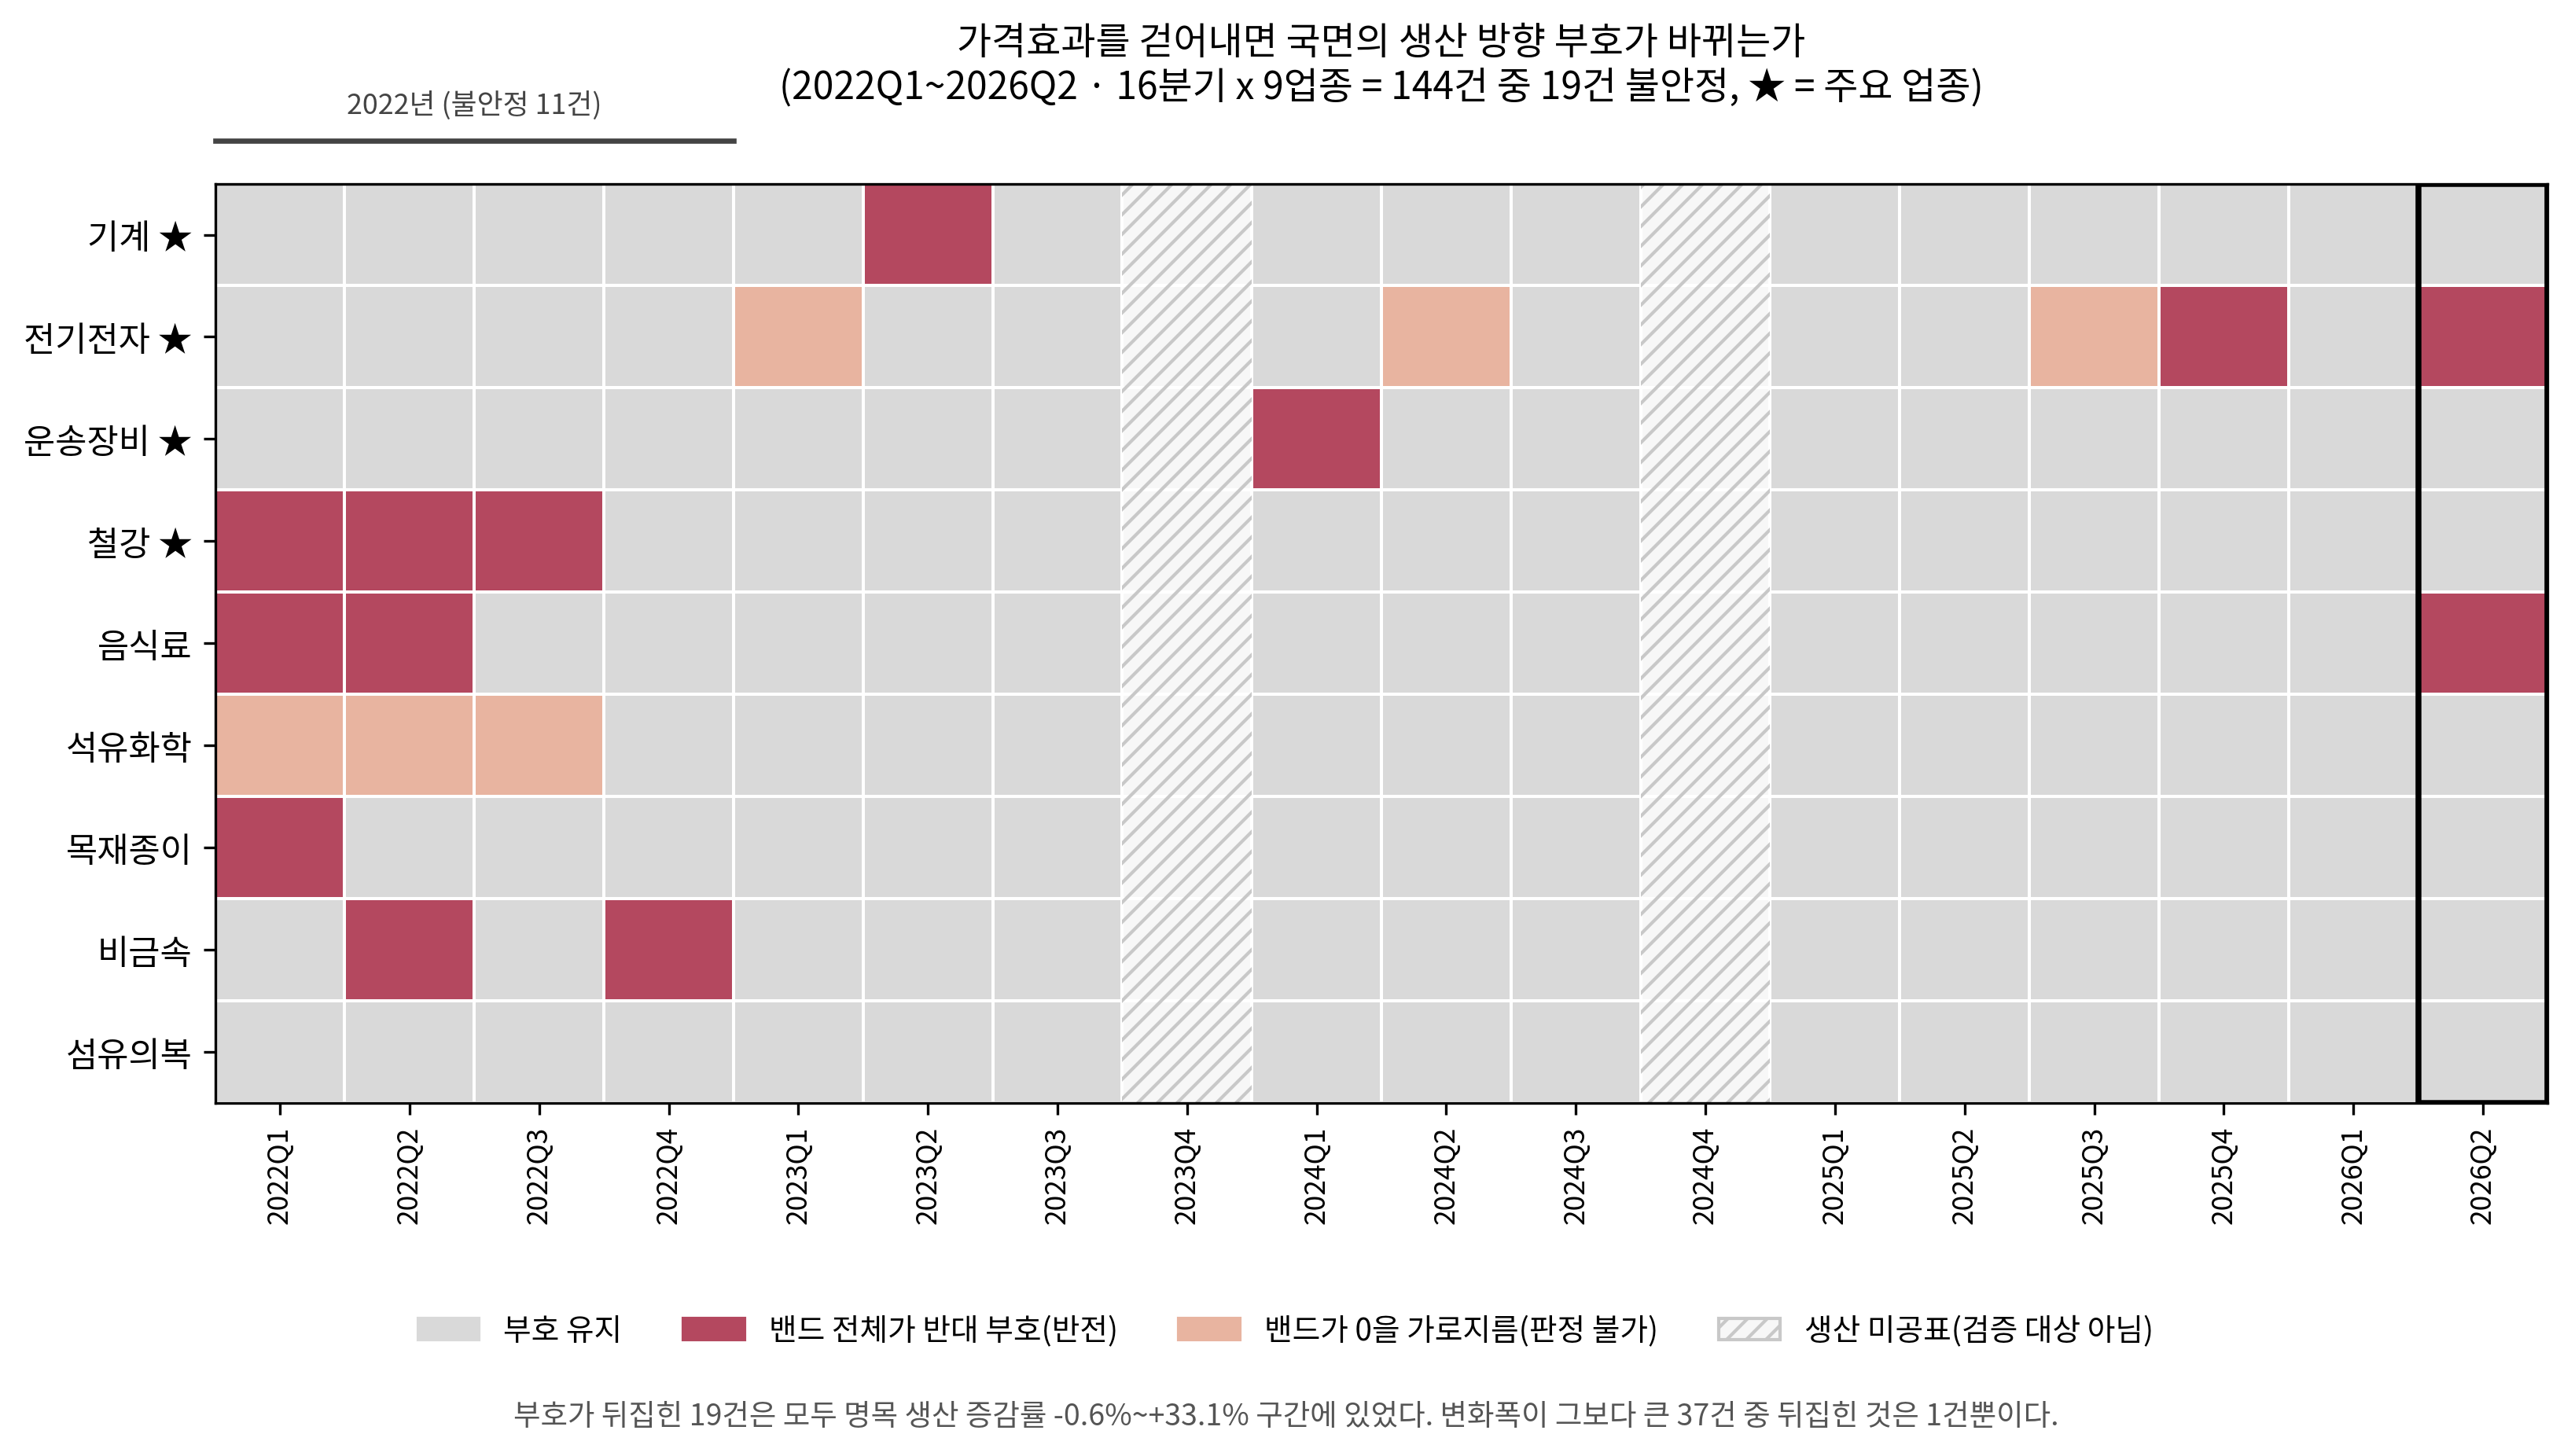

*outputs/final_model/04_external_evidence/ppi/V1_PPI_부호안정성.png*

| industry | quarter | nominal_production_yoy | ppi_adjusted_production_yoy | sign_agreement | pct5_threshold_agreement |
| --- | --- | --- | --- | --- | --- |
| 목재종이 | 2022Q1 | 10.39 | -4.02 | False | True |
| 음식료 | 2022Q1 | 3.90 | -1.64 | False | True |
| 철강 | 2022Q1 | 32.27 | -2.76 | False | True |
| 비금속 | 2022Q2 | 5.28 | -6.41 | False | False |
| 음식료 | 2022Q2 | 4.57 | -3.25 | False | True |
| 철강 | 2022Q2 | 26.84 | -2.59 | False | True |
| 철강 | 2022Q3 | 9.16 | -1.20 | False | True |
| 비금속 | 2022Q4 | 14.38 | -0.49 | False | True |
| 기계 | 2023Q1 | -3.55 | -6.90 | True | False |
| 기계 | 2023Q2 | 0.39 | -2.30 | False | True |
| 철강 | 2023Q3 | -9.90 | -3.99 | True | False |
| 비금속 | 2024Q1 | -4.81 | -7.69 | True | False |
| 운송장비 | 2024Q1 | 1.47 | -0.60 | False | True |
| 철강 | 2024Q1 | -8.79 | -1.98 | True | False |
| 음식료 | 2026Q2 | 0.87 | -0.78 | False | True |

부호 반전 수=11, 5% 경계 변경 수=5, 합집합 수=15
2026Q2 행 포함=True
부호 반전 11행 중 명목>0&조정<0=11, 명목<0&조정>0=0
명목 생산 YoY 범위(반전 행)=0.39%~32.27%


In [35]:
# 전국 PPI로 조정한 생산 YoY가 명목 생산과 얼마나 갈리는지 확인한다
show_image('outputs/final_model/04_external_evidence/ppi/V1_PPI_부호안정성.png', width=900)

show_table(ppi[['industry', 'quarter', 'nominal_production_yoy', 'ppi_adjusted_production_yoy',
                'sign_agreement', 'pct5_threshold_agreement']], max_rows=15)

flips = ppi[~ppi.sign_agreement]
pct5 = ppi[~ppi.pct5_threshold_agreement]
union_rows = ppi[(~ppi.sign_agreement) | (~ppi.pct5_threshold_agreement)]
print(f"부호 반전 수={len(flips)}, 5% 경계 변경 수={len(pct5)}, 합집합 수={len(union_rows)}")
print(f"2026Q2 행 포함={('2026Q2' in ppi.quarter.values)}")

pos_to_neg = flips[(flips.nominal_production_yoy > 0) & (flips.ppi_adjusted_production_yoy < 0)]
neg_to_pos = flips[(flips.nominal_production_yoy < 0) & (flips.ppi_adjusted_production_yoy > 0)]
print(f"부호 반전 11행 중 명목>0&조정<0={len(pos_to_neg)}, 명목<0&조정>0={len(neg_to_pos)}")
print(f"명목 생산 YoY 범위(반전 행)={flips.nominal_production_yoy.min():.2f}%~{flips.nominal_production_yoy.max():.2f}%")

**부호가 갈린 11행은 모두 명목 생산은 늘었지만 PPI로 조정하면 줄어드는 방향이며, 2026년 2분기 음식료도 여기에 들어간다.** 전국 PPI 매핑은 창원산단의 실제 가격이 아니므로 조정값을 실질 생산으로 읽지 않는다.

## EIS — 모집단이 다른 고용 방향

- **비교 가능한 14개 분기 중 두 계열의 고용 증감 방향이 같은 분기는 8개다.**
- 2026년 2분기는 EIS 창원시 제조업 YoY가 +0.67%, KICOX 산단 고용 YoY가 −3.64%로 방향이 반대다.

아래 그림은 EIS와 KICOX 고용 YoY를 분기별로 비교한다. 두 계열은 모집단이 달라 수준은 비교하지 않는다.

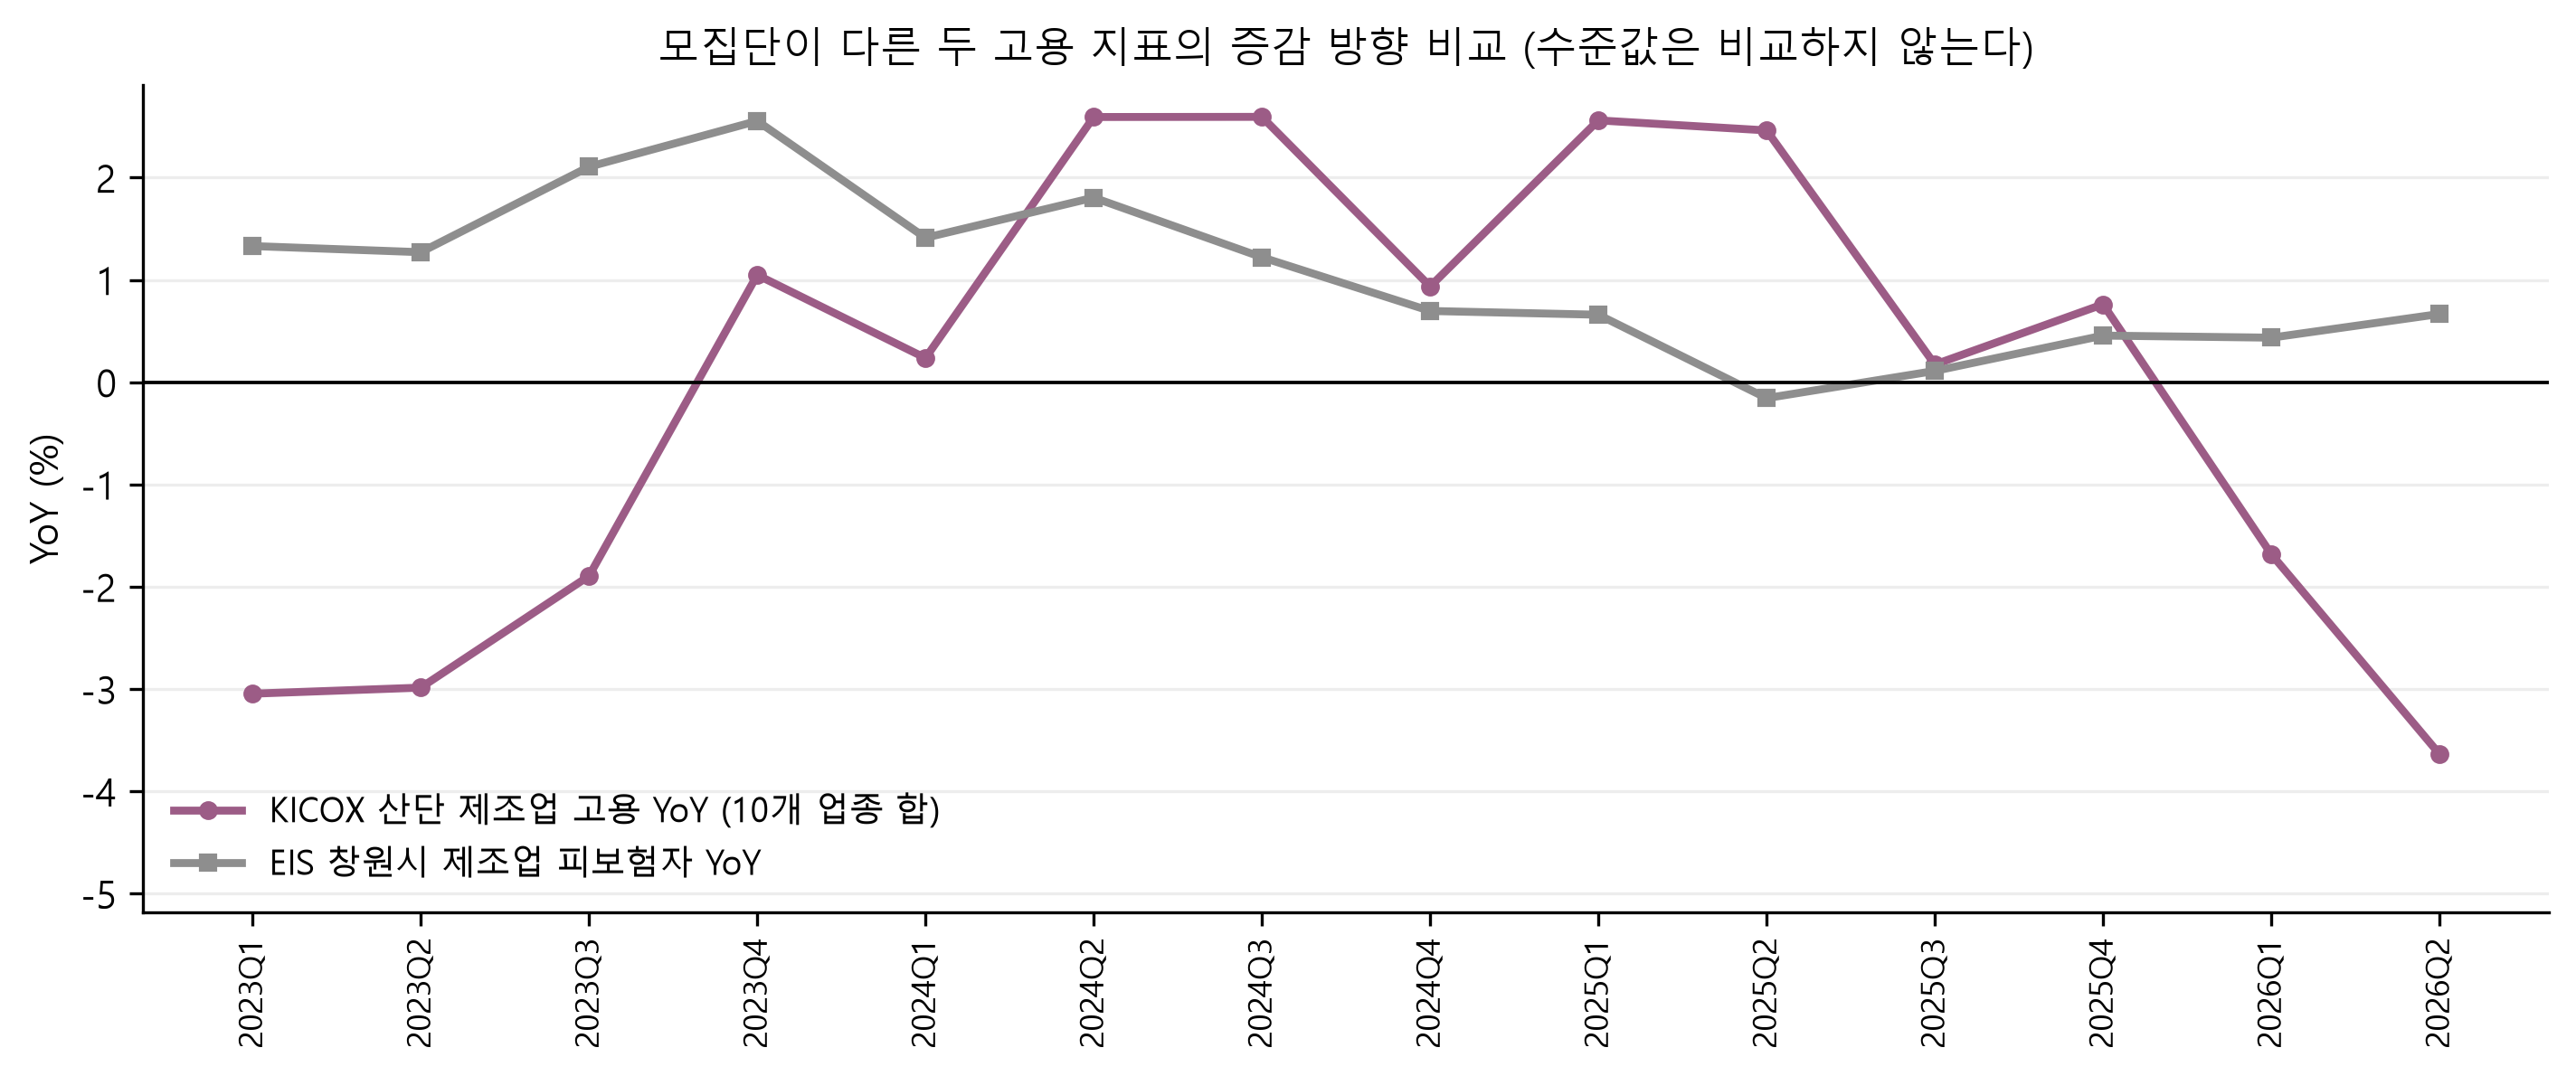

*outputs/final_model/04_external_evidence/eis/V2_EIS_YoY비교.png*

| 분기 | EIS YoY | KICOX YoY | 방향 일치 |
| --- | --- | --- | --- |
| 2023Q1 | 1.33 | -3.04 | False |
| 2023Q2 | 1.27 | -2.99 | False |
| 2023Q3 | 2.11 | -1.89 | False |
| 2023Q4 | 2.55 | 1.05 | True |
| 2024Q1 | 1.41 | 0.24 | True |
| 2024Q2 | 1.80 | 2.59 | True |
| 2024Q3 | 1.22 | 2.59 | True |
| 2024Q4 | 0.70 | 0.94 | True |
| 2025Q1 | 0.66 | 2.56 | True |
| 2025Q2 | -0.16 | 2.46 | False |
| 2025Q3 | 0.11 | 0.17 | True |
| 2025Q4 | 0.46 | 0.76 | True |
| 2026Q1 | 0.44 | -1.68 | False |
| 2026Q2 | 0.67 | -3.64 | False |

비교 분기 수=14, 일치 수=8
2026Q2: EIS=0.67%, KICOX=-3.64%


In [36]:
# EIS 창원시 제조업 YoY와 KICOX 산단 고용 YoY를 분기별로 비교한다
show_image('outputs/final_model/04_external_evidence/eis/V2_EIS_YoY비교.png', width=900)

eis_tbl = eis_join.copy()
eis_tbl['방향 일치'] = eis_tbl.eis_manufacturing_yoy_pct * eis_tbl.kicox > 0
eis_tbl = eis_tbl.reset_index().rename(columns={'quarter': '분기', 'eis_manufacturing_yoy_pct': 'EIS YoY', 'kicox': 'KICOX YoY'})
show_table(eis_tbl, max_rows=14)

print(f"비교 분기 수={len(eis_tbl)}, 일치 수={int(eis_tbl['방향 일치'].sum())}")
print(f"2026Q2: EIS={eis_join.loc['2026Q2','eis_manufacturing_yoy_pct']:.2f}%, KICOX={eis_join.loc['2026Q2','kicox']:.2f}%")

**EIS와 KICOX 고용은 방향이 절반가량만 같다.** EIS는 창원시 전역 피보험자라 산단 10개 업종 각각의 판정을 검증하지 못한다.

## KEPCO — 전력사용량

- **생산-전력 부호일치는 54.5%(110행), 고용-전력 부호일치는 50.0%(130행)다.**
- 업종×지표 20회 검정 중 Benjamini–Hochberg 보정(다중검정 오류율 보정) 뒤 유의한 결과는 0건이다.

아래 표는 저장된 KEPCO 강건성 요약을 보여준다.

In [37]:
# KEPCO 전력사용량 교차확인 요약을 항목-값 표로 확인한다
items_k = [
    ('n_rows_joined', kepco['n_rows_joined']), ('n_comparable', kepco['n_comparable']),
    ('production_vs_power n', kepco['pooled']['production_vs_power']['n']),
    ('production_vs_power agree_pct', kepco['pooled']['production_vs_power']['agree_pct']),
    ('production_vs_power spearman_rho', round(kepco['pooled']['production_vs_power']['spearman_rho'], 4)),
    ('production_vs_power p_value', round(kepco['pooled']['production_vs_power']['p_value'], 4)),
    ('employment_vs_power n', kepco['pooled']['employment_vs_power']['n']),
    ('employment_vs_power agree_pct', kepco['pooled']['employment_vs_power']['agree_pct']),
    ('employment_vs_power spearman_rho', round(kepco['pooled']['employment_vs_power']['spearman_rho'], 4)),
    ('employment_vs_power p_value', round(kepco['pooled']['employment_vs_power']['p_value'], 4)),
    ('multiple_testing n_tests', kepco['multiple_testing']['n_tests']),
    ('multiple_testing n_p_below_05', kepco['multiple_testing']['n_p_below_05']),
    ('multiple_testing n_q_below_05_bh', kepco['multiple_testing']['n_q_below_05_bh']),
    ('spatial_context masked_rows_pct', kepco['spatial_context']['masked_rows_pct']),
    ('triage_invariance unchanged', kepco['triage_invariance']['unchanged']),
]
show_table(pd.DataFrame(items_k, columns=['항목', '값']), max_rows=len(items_k))

| 항목 | 값 |
| --- | --- |
| n_rows_joined | 180 |
| n_comparable | 130 |
| production_vs_power n | 110 |
| production_vs_power agree_pct | 54.50 |
| production_vs_power spearman_rho | 0.14 |
| production_vs_power p_value | 0.14 |
| employment_vs_power n | 130 |
| employment_vs_power agree_pct | 50.00 |
| employment_vs_power spearman_rho | -0.09 |
| employment_vs_power p_value | 0.31 |
| multiple_testing n_tests | 20 |
| multiple_testing n_p_below_05 | 5 |
| multiple_testing n_q_below_05_bh | 0 |
| spatial_context masked_rows_pct | 72.60 |
| triage_invariance unchanged | True |

**전력 방향은 생산·고용 방향과 우연 수준으로만 겹친다.** 전력자료를 붙여도 Triage 180행의 단계는 바뀌지 않으며, 전력 감소를 조업 축소의 증거로 쓰지 않는다.

## 2026년 2분기 우선점검 업종의 외부근거

- **기계는 명목 생산 −19.55%, PPI 조정 −20.55%, 수출 −38.10%로 생산 관련 외부자료가 같은 감소 방향이다.**
- 목재종이는 PPI 조정 −15.29%로 감소 방향이고 수출 매핑 자료는 없다.

아래 표는 두 업종의 CORE 값과 외부 맥락 값을 나란히 놓는다. 전력과 BSI는 업종별 산단 값이 아니다.

In [38]:
# 2026Q2 우선점검 두 업종의 외부근거 값을 전치 표로 나란히 놓는다
evidence = rd('outputs/final_model/04_external_evidence/external_evidence_summary.csv')
pri2 = evidence[evidence.stage == '우선점검']
cols_ev = ['nominal_production_yoy', 'ppi_mapping_grade', 'ppi_adjusted_production_yoy', 'trade_export_yoy',
           'trade_mapping_grade', 'power_usage_yoy', 'power_scope', 'bsi_region_business', 'bsi_industry_business',
           'mfg_flow_job_openings', 'jobs_industry_signal_usable']
t_ev = pri2.set_index('industry')[cols_ev].T
show_table(t_ev.reset_index().rename(columns={'index': '항목'}), max_rows=len(cols_ev))

for _, r in pri2.iterrows():
    txt = str(r.check_questions_context)
    print(f"{r.industry}: {txt[:300]}{'…' if len(txt) > 300 else ''}")

| 항목 | 기계 | 목재종이 |
| --- | --- | --- |
| nominal_production_yoy | -19.55 | -12.90 |
| ppi_mapping_grade | A | A |
| ppi_adjusted_production_yoy | -20.55 | -15.29 |
| trade_export_yoy | -38.10 | — |
| trade_mapping_grade | B | — |
| power_usage_yoy | 0.75 | 0.75 |
| power_scope | 창원시 전역 제조업 총계 전력사용량 · 월→분기 합계. 업종별 값이 아니며 가동률과 개념·모집단이 다르다. | 창원시 전역 제조업 총계 전력사용량 · 월→분기 합계. 업종별 값이 아니며 가동률과 개념·모집단이 다르다. |
| bsi_region_business | 74.67 | 74.67 |
| bsi_industry_business | 76.84 | 59.66 |
| mfg_flow_job_openings | 513.00 | 513.00 |
| jobs_industry_signal_usable | False | False |

기계: 가동률 하락이 일시적 생산조정인지 수주·수요 감소에 따른 것인지 확인할 필요가 있다.
명목생산 변화에 가격효과가 포함되어 있으므로 실제 물량이 줄었는지 추가로 확인할 필요가 있다.
확인된 품목 기준 수출이 함께 감소하고 있어, 외부수요 약화 가능성을 보려면 수출 감소가 특정 품목·기업에 집중되는지 추가 확인할 필요가 있다.
창원시 제조업 전체에서 이직자 증가가 함께 관측되므로, 특정 사업장 조정 또는 노동이동과 관련된 것인지 추가 확인할 필요가 있다.
가동률과 전력사용의 방향이 달라 업종 구성·설비 특성·자료범위(산단 vs …
목재종이: 명목생산 변화에 가격효과가 포함되어 있으므로 실제 물량이 줄었는지 추가로 확인할 필요가 있다.
창원시 제조업 전체에서 이직자 증가가 함께 관측되므로, 특정 사업장 조정 또는 노동이동과 관련된 것인지 추가 확인할 필요가 있다.
경남 제조업 업황 심리지수가 기준선(100)을 밑돌아, 업종 고유 요인인지 지역 전반의 경기 흐름인지 구분해 확인할 필요가 있다.
같은 업종의 전국 업황 심리지수도 기준선을 밑돌아, 관측된 변화가 산단 고유 현상인지 전국 업종 흐름인지 확인할 필요가 있다.
이 분기는 월별 원자료가 공표되지 않아 분기 내…


**기계는 생산·수출·심리지수가 함께 낮은 방향이고, 목재종이는 생산 관련 신호만 확인된다.** 같은 방향이라는 사실은 원인이 같다는 뜻이 아니며, 확인 질문으로만 쓴다.

## 고용24 공개 채용정보

- **공개 공고 2,124건을 수집해 2,045건으로 정리했고, 그중 663건을 KICOX 업종에 연결했다.**
- 공고 등록기간은 2026-07-21~09-18로 2026년 3분기에 속해 판정 분기 2026년 2분기와 겹치지 않는다.

아래 표는 저장된 품질 요약과 스냅샷 메타데이터를 보여준다.

In [39]:
# 고용24 채용정보 수집·정리 품질 요약을 항목-값 표로 확인한다
snap_s = work24['snapshot']
items_w = [
    ('expected_total', snap_s['expected_total']), ('collected_total', snap_s['collected_total']),
    ('pages_failed', snap_s['pages_failed']), ('parse_failures', snap_s['parse_failures']),
    ('crawl_timestamp', snap_s['crawl_timestamp']),
    ('rows', snap['rows']), ('unique_wanted_auth_no', snap['unique_wanted_auth_no']),
    ('registration_date_min', snap['registration_date_min']), ('registration_date_max', snap['registration_date_max']),
    ('registration_quarters', snap['registration_quarters']), ('kicox_mapped_rows', snap['kicox_mapped_rows']),
    ('recruitment_count_coverage_pct', snap['recruitment_count_coverage_pct']),
    ('industry_signal_usable', snap['industry_signal_usable']), ('role', snap['role']),
]
show_table(pd.DataFrame(items_w, columns=['항목', '값']), max_rows=len(items_w))

| 항목 | 값 |
| --- | --- |
| expected_total | 2124 |
| collected_total | 2124 |
| pages_failed | 0 |
| parse_failures | 0 |
| crawl_timestamp | 2026-09-19T12:38:57+00:00 |
| rows | 2045 |
| unique_wanted_auth_no | 2045 |
| registration_date_min | 2026-07-21 |
| registration_date_max | 2026-09-18 |
| registration_quarters | ['2026Q3'] |
| kicox_mapped_rows | 663 |
| recruitment_count_coverage_pct | 0.00 |
| industry_signal_usable | False |
| role | CONTEXT |

**채용공고는 판정 분기 이후의 단면이라 2026년 2분기 판정의 동일 시점 근거가 아니다.** 모집인원 정보가 없어 공고 수를 노동수요 규모로 읽지 않는다.

## 결과와 해석 범위

**외부자료는 우선점검 업종의 생산 감소 방향을 일부 뒷받침하지만 판정을 확인하거나 반박하지는 못한다.** PPI는 11행에서 명목 생산의 부호를 뒤집고, EIS와 전력은 방향 일치가 절반 수준이다.

외부자료의 방향 일치를 인과 확인으로, 불일치를 반증으로 읽지 않는다. 공간 단위(전국·경남·창원시·법정동)와 업종 매핑이 산단 업종×분기와 다르다.

외부근거는 판정 뒤 확인 질문을 만든다. 다음 §12에서는 2026년 2분기 최종 결과와 진단카드를 확인한다. 자료별 품질 점검은 Appendix I에 둔다.

Source

- `outputs/final_model/04_external_evidence/data_role_table.csv`
- `outputs/final_model/04_external_evidence/external_evidence_summary.csv`
- `logs/validation/outputs/robustness_extension/nominal_real_disagreement.csv`
- `data/processed/eis/eis_validation_panel.csv`
- `logs/validation/outputs/kepco_robustness/results_summary.json`
- `data/processed/work24/work24_quality_summary.json`
- `outputs/final_model/04_external_evidence/employment_center/recruiting_snapshot_metadata.json`
- `notebooks/05_external_evidence.ipynb`

# 12. 최종 결과 — 2026년 2분기 점검 대상과 보조모형 재검토

## 분석 질문

2026년 2분기에 어떤 업종을 어떤 근거로 먼저 확인하고, 과거 추가확인 35행에서 보조모형은 무엇을 표시했는가?

진단카드는 CORE 진단, Triage 단계와 이유, 외부 맥락, 담당자 확인 질문, 인계 가능한 기존 기능을 한 업종씩 묶은 표다. 카드의 값은 `explanation_trace.csv`에 저장된 값이다.

## 2026년 2분기 10개 업종

- **우선점검은 기계와 목재종이 두 업종이고, 나머지 8개 업종은 관찰이다.**
- 2026년 2분기 추가확인은 0건이라 이번 분기에는 보조모형 재검토 대상이 없다.

아래 표는 2026년 2분기 업종별 단계, 신호, 규모와 선정 이유를 보여준다.

In [40]:
# 2026Q2 업종별 단계·신호·규모·선정 이유를 확인한다
g26 = triage[triage.quarter == '2026Q2'].copy()
stage_order = {'우선점검': 0, '추가확인': 1, '관찰': 2, '자료확인': 3}
g26['_o'] = g26.stage.map(stage_order)
g26 = g26.sort_values(['_o', 'rank_in_stage'])
cols12 = ['industry', 'stage', 'state', 'emp_delta', 'e_yoy', 'employment_share_pct', 'E', 'R', 'A', 'P',
          'persist', 'scale_ok', 'stage_reason']
show_table(g26[cols12], max_rows=10)

| industry | stage | state | emp_delta | e_yoy | employment_share_pct | E | R | A | P | persist | scale_ok | stage_reason |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| 기계 | 우선점검 | S4 | -3,979.00 | -6.34 | 51.19 | 6.34 | 2.70 | 3.47 | 19.55 | False | True | 고용감소 6.3%(진입경계 5% 통과) · 산단 제조업 고용의 3.47% 감소(상위경계 2.0% 통과) → 보강: 생산 19.5% 감소 |
| 목재종이 | 우선점검 | S4 | -48.00 | -10.08 | 0.37 | 10.08 | 6.45 | 0.04 | 12.90 | True | True | 고용감소 10.1%(상위경계 10% 통과) · 산단평균 대비 6.4%p 열위(진입경계 통과) → 보강: 생산 12.9% 감소 / 직전 분기에도 진입신호(지속) |
| 운송장비 | 관찰 | S2 | -129.00 | -0.78 | 14.20 | 0.78 | 0.00 | 0.11 | 0.00 | False | True | 고용 축 진입신호 없음 |
| 전기전자 | 관찰 | S2 | -116.00 | -0.41 | 24.37 | 0.41 | 0.00 | 0.10 | 0.00 | False | True | 고용 축 진입신호 없음 |
| 철강 | 관찰 | S2 | -112.00 | -1.14 | 8.44 | 1.14 | 0.00 | 0.10 | 0.00 | False | True | 고용 축 진입신호 없음 |
| 음식료 | 관찰 | S2 | -25.00 | -3.79 | 0.55 | 3.79 | 0.15 | 0.02 | 0.00 | False | True | 고용 축 진입신호 없음 |
| 비금속 | 관찰 | S2 | -2.00 | -1.08 | 0.16 | 1.08 | 0.00 | 0.00 | 0.00 | False | False | 고용 축 진입신호 없음 |
| 기타 | 관찰 | S1 | 25.00 | 17.12 | 0.15 | 0.00 | 0.00 | 0.00 | 0.00 | False | False | 고용 축 진입신호 없음 |
| 석유화학 | 관찰 | S3 | 54.00 | 9.56 | 0.54 | 0.00 | 0.00 | 0.00 | 6.73 | False | True | 고용 축 진입신호 없음 (생산 6.7% 단독 감소 — 확인질문에 반영) |
| 섬유의복 | 관찰 | N | 0.00 | 0.00 | 0.03 | 0.00 | 0.00 | 0.00 | 12.32 | False | False | 고용 축 진입신호 없음 (생산 12.3% 단독 감소 — 확인질문에 반영) |

**관찰 8개 업종 중 E·R·A 진입신호가 있는 업종은 없고, 석유화학과 섬유의복은 생산만 5% 넘게 줄었다.** 관찰은 "문제 없음"이 아니라 이번 분기 고용 신호가 진입경계 아래라는 뜻이다.

## 진단카드 2건

- **기계 카드는 규모(A) 중심, 목재종이 카드는 비율(E)과 반복 중심으로 확인 질문이 다르다.**
- 두 카드 모두 최종 판단 주체는 담당자다.

아래 출력은 저장된 인계 근거에서 두 업종의 카드를 그대로 옮긴다.

In [41]:
# 저장된 인계 근거(explanation_trace.csv)에서 우선점검 두 업종의 진단카드를 그대로 옮긴다
trace = rd('outputs/final_model/05_handoff/tables/explanation_trace.csv')
for _, r in trace[trace.stage == '우선점검'].iterrows():
    lines = [
        f'#### {r.industry} {r.quarter}',
        f'- **Q1 국면:** {r.q1_state_label}',
        f'- **Q2 증감·비중:** {r.q2_employment_delta:+.0f}명 · YoY {r.q2_employment_yoy:.2f}% · 비중 {r.q2_employment_share:.2f}%',
        f'- **Q3 지속·반복:** {r.q3_state_run_length:.0f}분기({r.q3_transition}) · 반복신호 {r.q3_repeated_signal}',
        f'- **단계·이유:** {r.stage} — {r.stage_reason}',
        f'- **확인 질문:** {r.check_question}',
        f'- **인계 기능:** {r.first_owner} / {r.handoff_review_functions}',
        f'- **담당자 확인 필요:** {r.human_decision_required}',
    ]
    display(Markdown('\n'.join(lines)))

#### 기계 2026Q2
- **Q1 국면:** 생산↓·고용↓
- **Q2 증감·비중:** -3979명 · YoY -6.34% · 비중 51.19%
- **Q3 지속·반복:** 2분기(S4 → S4) · 반복신호 False
- **단계·이유:** 우선점검 — 고용감소 6.3%(진입경계 5% 통과) · 산단 제조업 고용의 3.47% 감소(상위경계 2.0% 통과) → 보강: 생산 19.5% 감소
- **확인 질문:** 수주잔량·가동률·휴업/감산·기업 수 변동·고용조정 계획 신고 여부를 확인한다(원인 후보이며 입증된 원인이 아님).
- **인계 기능:** 기업지원 기능 + 고용지원 기능 / 산업동향 · 기업지원 / 산업동향 / 고용지원
- **담당자 확인 필요:** True

#### 목재종이 2026Q2
- **Q1 국면:** 생산↓·고용↓
- **Q2 증감·비중:** -48명 · YoY -10.08% · 비중 0.37%
- **Q3 지속·반복:** 2분기(S4 → S4) · 반복신호 True
- **단계·이유:** 우선점검 — 고용감소 10.1%(상위경계 10% 통과) · 산단평균 대비 6.4%p 열위(진입경계 통과) → 보강: 생산 12.9% 감소 / 직전 분기에도 진입신호(지속)
- **확인 질문:** 수주잔량·가동률·휴업/감산·기업 수 변동·고용조정 계획 신고 여부를 확인한다(원인 후보이며 입증된 원인이 아님).
- **인계 기능:** 기업지원 기능 + 고용지원 기능 / 산업동향 / 고용지원
- **담당자 확인 필요:** True

**카드는 판정 근거와 확인 질문을 담고 원인을 담지 않는다.** 수주·자동화·외주화 같은 기업별 원인은 카드의 "아직 추정" 영역이며 현장 확인 전에는 확정할 수 없다.

## 보조모형 재검토 35행 요약

- **추가확인 35행의 ELECTRE 배정은 우선점검 수준(PRIORITY) 20, 추가확인 수준(CHECK) 9, 자료·모형상 단일 범주 확정 곤란(UNDETERMINED) 4, 관찰 수준(OBSERVE) 2다.**
- 35행 중 29행은 SMAA-TRI 파라미터 표집에서 배정이 바뀌는 행이다. UNDETERMINED 4행은 생산 기준 g3가 결측인 행이다.

아래 표는 저장된 검토 대기열 그룹별 건수를 보여준다.

In [42]:
# 추가확인 35행의 검토 대기열 그룹별 건수와 UNDETERMINED 4행의 g1~g4·CAI를 확인한다
smaa_summary = rd('outputs/final_model/03_electre_smaa/tables/electre_smaa_summary.csv')
show_table(smaa_summary, max_rows=len(smaa_summary))

und = review[review.electre_stage == 'UNDETERMINED']
show_table(und[['industry', 'quarter', 'g1', 'g2', 'g3', 'g4', 'cai_observe', 'cai_check',
                 'cai_priority', 'cai_undetermined', 'smaa_parameter_sensitive']], max_rows=4)

print(f"smaa_parameter_sensitive 수={int(review.smaa_parameter_sensitive.sum())} / 35, "
      f"n_possible>=2 수={int((review.n_possible >= 2).sum())}, "
      f"necessary_stage 결측 수={int(review.necessary_stage.isna().sum())}")

| review_queue_group | electre_stage | smaa_parameter_sensitive | case_count |
| --- | --- | --- | --- |
| 1 자료·모형 불확실 확인 | UNDETERMINED | False | 4 |
| 2 Triage-ELECTRE 불일치 확인 | OBSERVE | True | 2 |
| 3 파라미터 민감 우선검토 후보 | PRIORITY | True | 19 |
| 4 안정 우선검토 후보 | PRIORITY | False | 1 |
| 5 파라미터 민감 추가확인 | CHECK | True | 8 |
| 6 추가확인 | CHECK | False | 1 |

| industry | quarter | g1 | g2 | g3 | g4 | cai_observe | cai_check | cai_priority | cai_undetermined | smaa_parameter_sensitive |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| 목재종이 | 2023Q4 | 24.00 | 9.13 | — | 5.00 | 0.00 | 0.00 | 0.00 | 1.00 | False |
| 섬유의복 | 2023Q4 | 26.00 | 40.62 | — | 1.00 | 0.00 | 0.00 | 0.00 | 1.00 | False |
| 목재종이 | 2024Q4 | 25.00 | 10.46 | — | 9.00 | 0.00 | 0.00 | 0.00 | 1.00 | False |
| 섬유의복 | 2024Q4 | 4.00 | 10.53 | — | 5.00 | 0.00 | 0.00 | 0.00 | 1.00 | False |

smaa_parameter_sensitive 수=29 / 35, n_possible>=2 수=29, necessary_stage 결측 수=29


**자료·모형상 단일 범주 확정 곤란(UNDETERMINED)은 파라미터 때문이 아니라 생산 자료 결측 때문에 생긴다.** 4행 모두 SMAA 파라미터 민감으로 표시되지 않았고, 2023년 4분기·2024년 4분기 생산 YoY 결측 구간에 있다.

## 범주 수용도

- **범주 수용도 지수(CAI; 표집한 파라미터 조합 중 그 범주가 나온 비율)가 두 범주 이상에 나뉜 행은 35행 중 29행이고, 16행은 가장 큰 CAI도 0.8 미만이다.**
- CAI는 위기확률이나 정답률이 아니다.

아래 그림은 35행의 범주별 CAI를 누적 막대로 보여준다. 색은 ELECTRE 범주다.

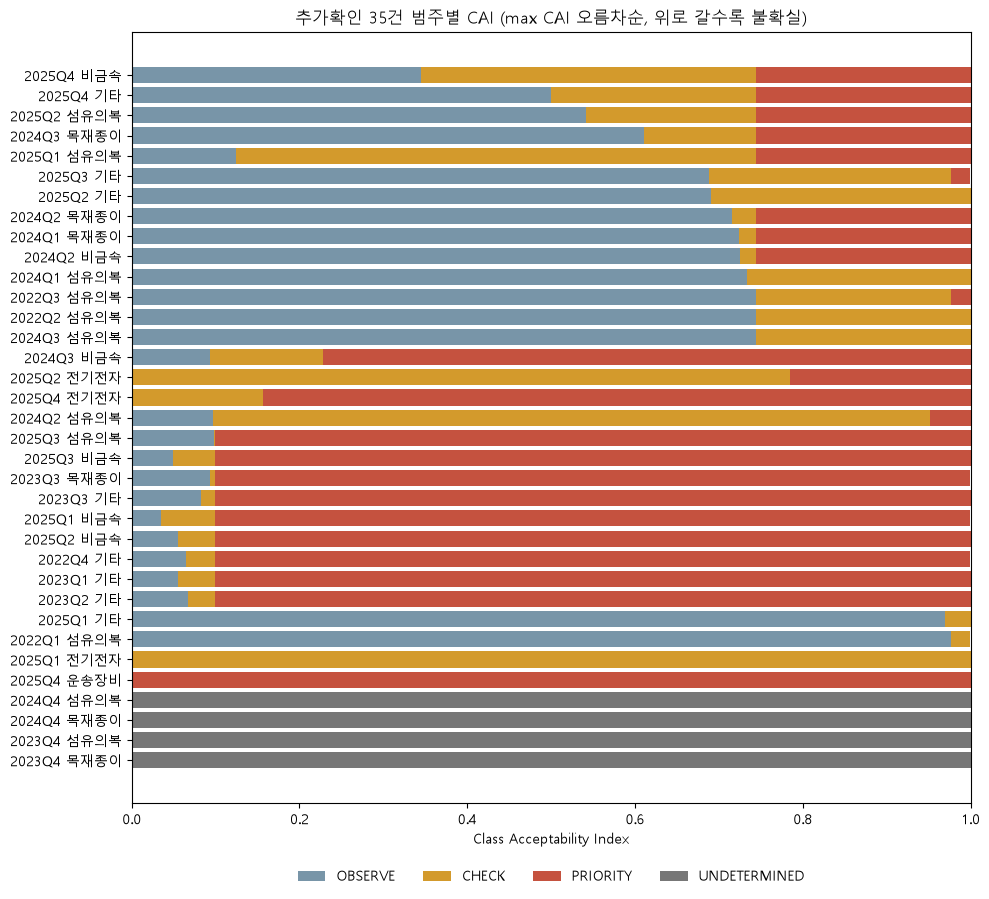

max CAI < 0.8 인 행 수=16, max CAI == 1 인 행 수=6


In [43]:
# 추가확인 35행의 범주별 CAI를 누적 가로막대로 표시한다 (불확실한 행이 위로 오도록 정렬)
cai_cols = ['cai_observe', 'cai_check', 'cai_priority', 'cai_undetermined']
u = review.copy()
u['max_cai'] = u[cai_cols].max(axis=1)
u = u.sort_values('max_cai', ascending=False)
labels = u['quarter'] + ' ' + u['industry']
left = np.zeros(len(u))
fig, ax = plt.subplots(figsize=(10, 9))
for c, name in zip(cai_cols, ['OBSERVE', 'CHECK', 'PRIORITY', 'UNDETERMINED']):
    ax.barh(labels, u[c], left=left, label=name, color=STAGE_COLORS[{'OBSERVE': '관찰', 'CHECK': '추가확인',
             'PRIORITY': '우선점검', 'UNDETERMINED': '자료확인'}[name]])
    left += u[c].to_numpy()
ax.set_xlim(0, 1); ax.set_xlabel('Class Acceptability Index')
ax.set_title('추가확인 35건 범주별 CAI (max CAI 오름차순, 위로 갈수록 불확실)')
ax.legend(frameon=False, ncol=4, loc='lower center', bbox_to_anchor=(.5, -.12))
plt.tight_layout(); plt.show()

print(f"max CAI < 0.8 인 행 수={int((u.max_cai < 0.8).sum())}, max CAI == 1 인 행 수={int((u.max_cai == 1).sum())}")

**범주 수용도 지수(CAI)가 한 범주에서 1인 행은 6행이고, 그중 4행은 생산 결측으로 생긴 UNDETERMINED다.** 이 분포는 추가확인 안에서 먼저 볼 행의 순서를 정하는 참고일 뿐 Triage 단계를 바꾸지 않는다.

## 결과와 해석 범위

**2026년 2분기에 먼저 확인할 업종은 기계와 목재종이이고, 두 업종은 확인할 내용이 다르다.** 기계는 −3,979명의 규모와 생산 감소를, 목재종이는 −10.08%의 비율과 반복 신호를 확인한다.

보조모형의 우선점검 수준(PRIORITY) 20행을 "놓친 우선점검"으로 읽지 않는다. 그중 19행은 파라미터에 민감하다.

최종 결과는 담당자 확인의 입력이다. 다음 §13에서는 이 결과가 시스템에서 어떤 기능으로 쓰이는지 확인한다.

Source

- `outputs/final_model/02_triage/tables/triage_panel.csv`
- `outputs/final_model/05_handoff/tables/explanation_trace.csv`
- `outputs/final_model/03_electre_smaa/tables/electre_smaa_summary.csv`
- `outputs/final_model/03_electre_smaa/tables/electre_smaa_review_cases.csv`
- `notebooks/06_final_results.ipynb`

# 13. 분석에서 시스템으로 — 결과를 담당자 업무에 연결

## 분석 질문

분석 결과는 Streamlit 시스템의 어떤 기능에서 어떤 형태로 담당자에게 전달되는가?

시스템은 등록된 분석본(snapshot)을 읽어 화면에 보여주고, 담당자의 점검·인계 기록을 DB에 남긴다. **화면은 Q1~Q3와 Triage를 다시 계산하지 않는다.** 판정 값은 분석본에 고정되어 있고, 새 분기 분석본은 버전 번호를 새로 받아 등록된다.

## 기능과 구현 위치

- **분석 결과는 분석본 → 진단 화면 → 점검 기록 → 인계 순서로 전달된다.**
- AI 비서가 쓴 문장은 수치·판정 단계·인용 검사를 통과해야 표시된다.

| 기능 | 쓰는 분석 결과 | 담당자가 보는 정보 | 구현 위치 |
|---|---|---|---|
| Snapshot(분석본) | Triage 패널, 외부근거, 진단카드 | 분석본 버전·자료 기준일·해시 일치 | `src/export/snapshot.py` `build_snapshot`, `register_snapshot`, `load_bound_snapshot` |
| 점검 대기열 | 분기별 단계·단계 내 순위 | 우선점검·추가확인·관찰 목록 | `src/app/view_models.py` `queue_rows`, `rank_text` |
| 판정 추이 | 업종별 분기 단계 | 최근 분기 단계 띠 | `src/policy/decision_support.py` `DecisionSupportService.timeline` |
| 진단카드 | E·R·A·P, Q1~Q3, 선정 이유 | 신호별 경계 통과 여부와 근거 | `src/app/view_models.py` `rule_evidence_rows`, `reason_sentence` |
| 진단서 HTML/JSON | 진단카드·확인 상태 | 인계용 문서 저장 | `DecisionSupportService.report_payload`, `view_models.build_report_vm`, `report_download` |
| 점검 건·현장 확인 | 확인 질문 | 점검 건 개설, 확인 결과 기록 | `src/workflow/service.py` `open_case`, `record_check_result` |
| 지원 필요 기능·인계·회신·종결 | 기능 카탈로그 | 기능 선택, 기관 인계, 발송·접수·회신, 결정·종결 | `record_support_needs`, `create_referral`, `advance_referral`, `record_decision` |
| 기관 routing | 인계 기관 지도 | 기능별 후보 기관 | `src/workflow/catalog.py` `institution_candidates` |
| 정책 RAG | 공식 정책 문서 | 사업 요건·기관·출처 | `src/policy/rag.py` `PolicyRAG.search` |
| AI 비서 검사 | 등록 진단 문장 | 검사 통과 문장 또는 원문 | `src/copilot/guardrails.py` `check_rewrite`, `finalize` |
| 감사 로그 | 모든 기록 변경 | 누가 언제 무엇을 바꿨는지 | `src/workflow/models.py` `audit_log`, `WorkflowService.audit_log` |

아래 코드는 표의 파일과 함수가 저장소에 있는지, 화면 코드가 판정 함수를 부르지 않는지 확인한다.

**표에 적은 함수는 모두 저장소에 있고, 화면·기록·AI 코드 어디에서도 판정 함수를 부르지 않는다.** 이 검사는 코드 경로를 확인할 뿐 화면이 담당자 업무에 실제로 도움이 되는지는 알려주지 않는다.

## 업종 진단 화면

- **2026년 2분기 점검 대기열에는 우선점검 기계·목재종이가 위에 놓인다.**
- 진단카드와 AI 비서가 한 화면에 있다.

아래 그림은 배포 화면의 2026년 2분기 점검 대기열과 기계 진단카드다.

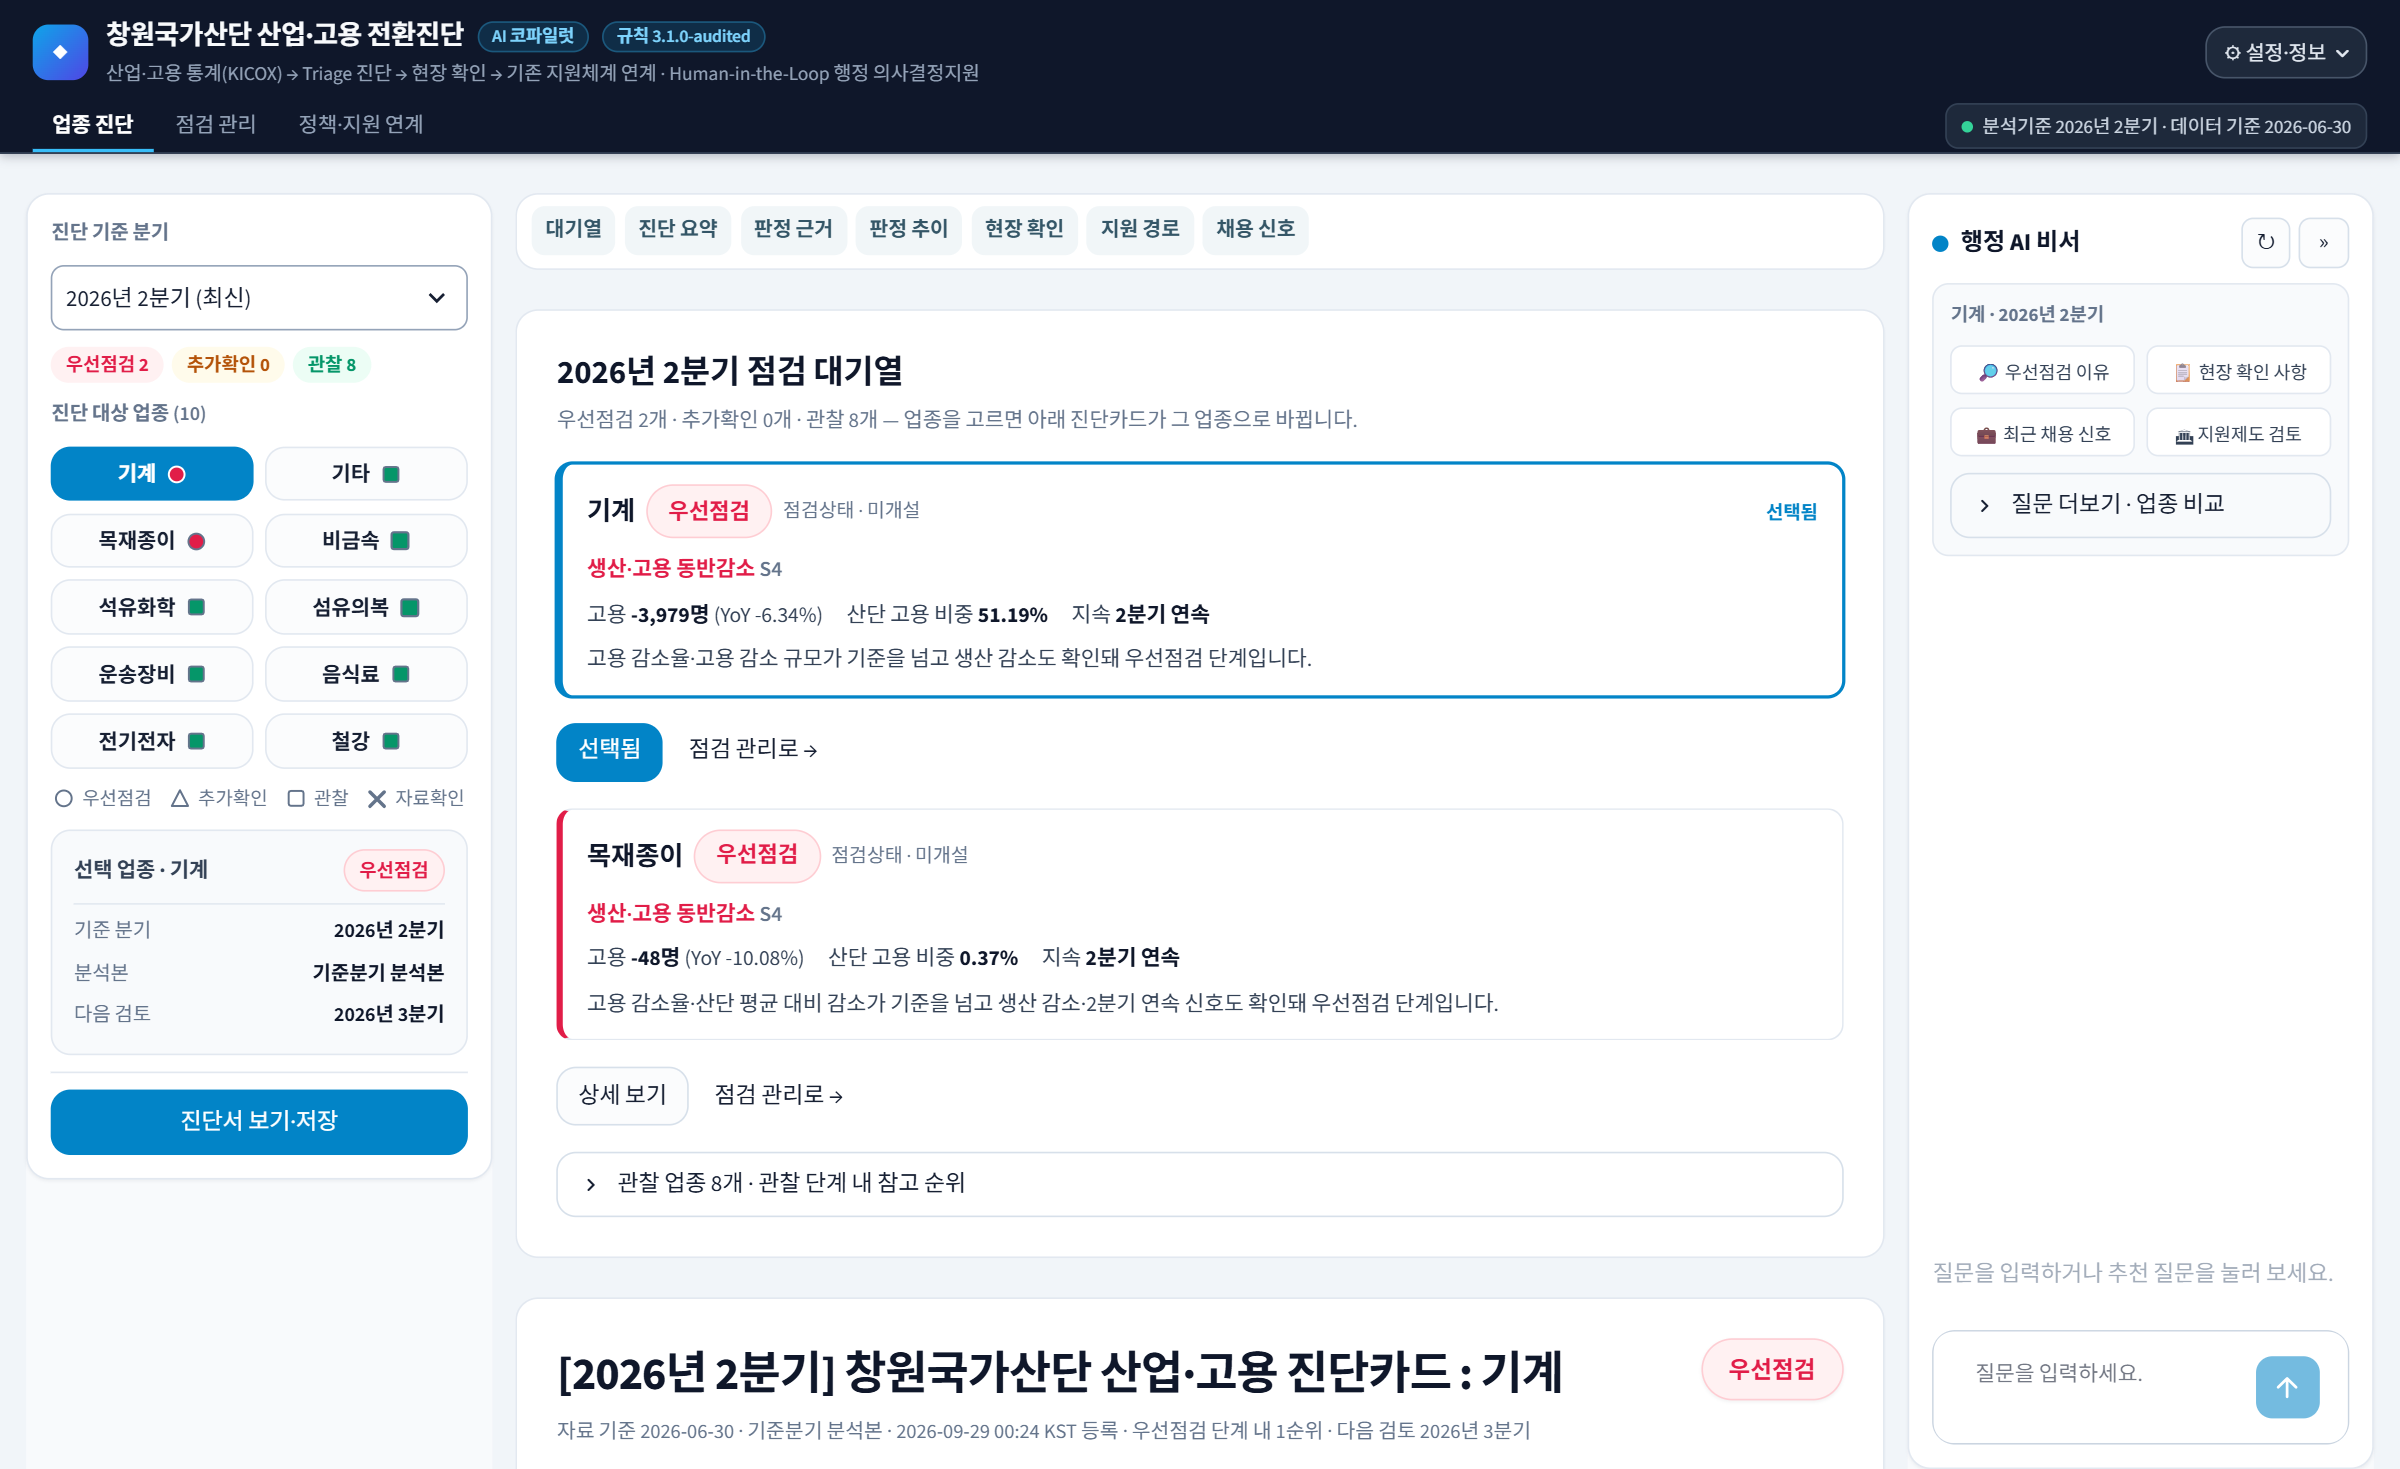

*assets/streamlit-industry-diagnosis-2026Q2-final.png*

In [45]:
# 배포 화면의 2026Q2 점검 대기열·진단카드 캡처
show_image('assets/streamlit-industry-diagnosis-2026Q2-final.png', width=1000)

**화면의 단계와 신호 값은 분석본에 저장된 값을 그대로 보여준다.** 화면 캡처 한 장으로 담당자가 실제로 어떤 순서로 쓰는지는 알 수 없다.

## 판정 근거 화면

- **E·R·A·P 신호마다 현재값, 진입·상위경계, 통과 여부가 표로 나온다.**
- 경계값이 법정 기준이나 최적값이 아니라는 문구가 함께 표시된다.

아래 그림은 기계 2026년 2분기 상세 진단카드의 판정 근거 영역이다.

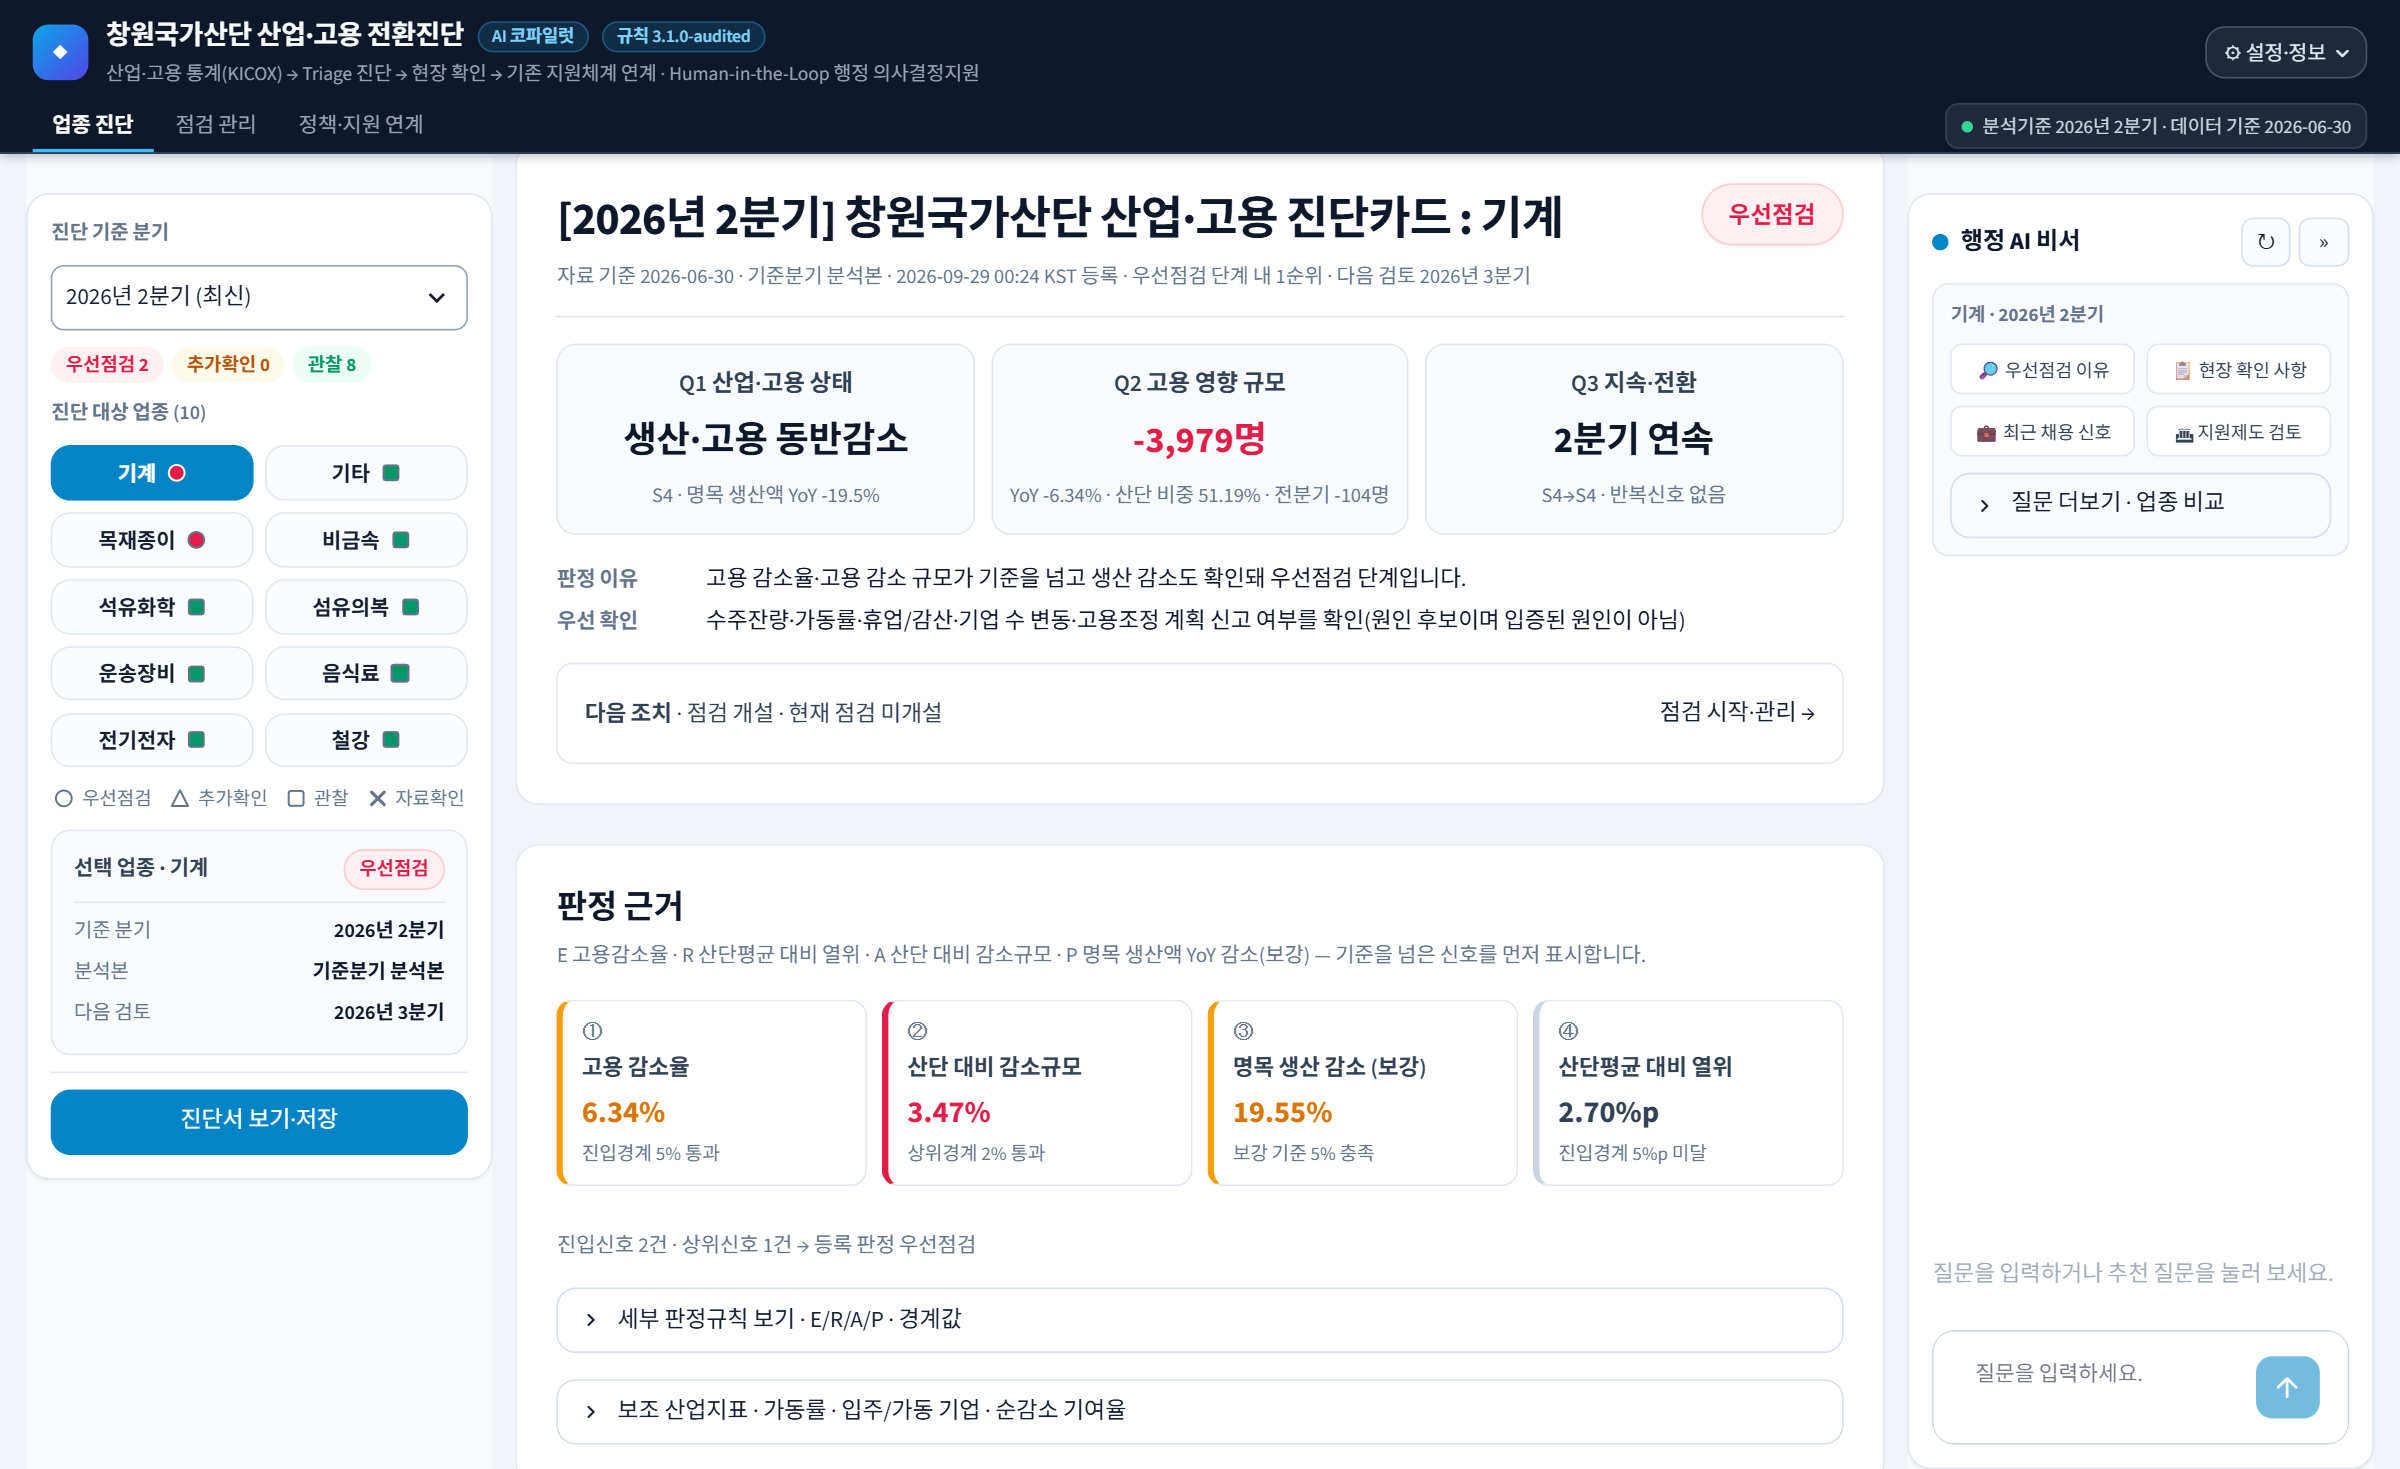

*assets/streamlit-industry-diagnosis-2026Q2-evidence.png*

In [46]:
# 배포 화면의 기계 2026Q2 상세 진단카드 판정 근거 영역 캡처
show_image('assets/streamlit-industry-diagnosis-2026Q2-evidence.png', width=1000)

**화면은 기계가 A 상위경계와 생산 보강으로 우선점검이 됐다는 §9의 규칙을 그대로 표시한다.** 화면 표시가 규칙과 같다는 것이 규칙의 타당성을 뜻하지는 않는다.

## 결과와 해석 범위

**시스템은 분석 결과를 다시 계산하지 않고 전달·기록·인계하는 역할만 한다.** 판정은 분석본에 고정되고, 담당자 기록은 점검 건·인계·감사 로그로 남는다.

시스템 구현을 운영 효과의 증거로 읽지 않는다. 현재 배포본은 인증이 없는 프로토타입이고, 담당자 사용 결과는 아직 없다.

§1~§13은 자료에서 판정, 검증, 인계까지를 차례로 보여준다. 다음 §14에서는 무엇이 확인되었고 무엇이 확인되지 않았는지를 한 번에 정리한다. 시스템 상세는 Appendix J에 둔다.

Source

- `src/export/snapshot.py`
- `src/app/view_models.py`
- `src/policy/decision_support.py`
- `src/workflow/service.py`
- `src/workflow/catalog.py`
- `src/workflow/models.py`
- `src/policy/rag.py`
- `src/copilot/guardrails.py`
- `snapshots/registry.json`
- `assets/streamlit-industry-diagnosis-2026Q2-final.png`
- `assets/streamlit-industry-diagnosis-2026Q2-evidence.png`

# 14. 종합

| 단계 | 질문 | 핵심 결과 | 해석 범위 |
|---|---|---|---|
| **Q1 상태** | 같은 고용 변화라도 생산 방향은 다른가? | 고용 감소 89건 중 43건(48.3%)은 명목 생산 증가 | 명목 기준. 물량·원인 아님 |
| **Q2 규모** | 고용 변화는 어느 업종에 몰려 있는가? | 2026년 2분기 순감소 4,332명 중 기계 3,979명(91.85%) | 10업종 합계 기준. 산술 분해 |
| **Q3 시간** | 그 국면이 이어지는가, 바뀌는가? | 인접쌍 67.7% 유지, 최장 7분기 | 관측 빈도. 우측절단 |
| **Triage** | 이번 분기에 무엇을 먼저 확인할까? | 180행: 관찰 128·추가확인 35·우선점검 17. 2026년 2분기 기계·목재종이 | 임계값에 조건부. 예측 아님 |

### 데이터가 직접 보여주는 것

- **고용 감소 신호 안에 명목 생산이 늘어난 관측과 줄어든 관측이 거의 반씩 섞여 있다(§3, §4).**
- 2026년 2분기 고용 감소는 기계 한 업종에 몰려 있고, 비례기대치보다 1,697명 더 줄었다(§5).
- 국면이 오래 이어져도 고용 진입신호가 없으면 단계가 오르지 않는다. 철강 S2 4분기가 그 예다(§7, §9).
- 규칙을 다시 실행하면 저장된 판정과 15개 사양 결과가 모두 재현된다(§10).
- 보조모형 35행 중 29행은 파라미터에 민감하고, UNDETERMINED 4행은 생산 자료 결측에서 생긴다(§12).

### 가능한 해석

S2(생산 증가·고용 감소)가 반복되는 업종은 인력 구조가 바뀌고 있을 가능성이 있다. 다만 명목 생산에는 가격이 섞여 있고 PPI 조정 후 부호가 바뀌는 행도 있다(§11). 자동화·외주화·숙련 불일치가 고용 감소를 낳았다는 경로는 이 분석이 직접 확인한 경로가 아니다.

### 이 분석만으로 확정할 수 없는 것

- 생산과 고용이 함께 줄어든 업종에서 생산 감소가 고용 감소의 원인인지 확인하지 않았다(§4).
- **2분기 뒤 고용위축 대리지표로 사후 점검했을 때 Triage와 ELECTRE 모두 뚜렷한 구분력을 보이지 않았다(BA 0.47, 0.44)(§10).**
- 임계값이 정책적으로 적절한지는 현장 확인 결과가 쌓이기 전까지 판단할 수 없다(§9, §10).
- 업종 결과가 개별 기업의 상태와 같은지는 확인할 수 없다(§1, §12).

### 시스템이 제공하는 것

- 판정을 다시 계산하지 않고 분석본에 고정된 값을 보여준다(§13).
- 점검 건, 현장 확인, 지원 필요 기능, 인계·회신·종결을 기록하고 감사 로그를 남긴다(§13).
- AI 비서 문장은 수치·단계·인용 검사를 통과해야 표시된다(§13).

# 15. 한계

- 업종 집계 자료다. 업종 안 기업 간 차이와 기업 단위 원인은 확인할 수 없다(§1).
- 관찰 자료다. 생산·고용의 인과관계를 추정하지 않았다(§3, §4).
- 임계값은 운영 규칙이다. A 1%·2%와 R 상위 10%p는 조문 근거가 없는 OWN이고, 나머지도 제도 원리를 옮긴 값이다(§9).
- 표본이 10업종×18분기 180행이다. 우선점검은 17행이고 같은 업종이 반복 관측된다(§9, §10).
- 생산은 명목 금액이다. PPI 조정 시 부호가 바뀌는 행이 11개다(§11).
- 외부자료는 공간·업종 단위가 산단 업종×분기와 다르다(§11).
- 시점분리 검증에서 두 모형 모두 대리지표를 뚜렷하게 구분하지 못했다. 대리지표도 같은 KICOX 계열이다(§10).
- 300인 gate는 소규모 업종의 recall을 낮추고(32% 대 64%) FPR도 낮춘다(70.37% 대 85.19%). 득실은 함께 봐야 한다(§10).
- 과거 분기 판정은 현재 규칙으로 다시 만든 후향 재구성이다. 분기 갱신 때 분석본 버전을 새로 발급해 이전 판정을 덮어쓰지 않아야 한다(§9, §13).

# 16. 교수님 검토 필요사항

1. 상태·규모·시간을 분리한 뒤 명시적 Triage 규칙으로 묶는 구조가 적절한가.
2. Triage를 주모형, ELECTRE TRI-B와 SMAA-TRI를 추가확인 35건의 보조 재검토로 둔 역할 분담이 적절한가.
3. A 1%·2%, R 상위 10%p, 규모 게이트 300인 등 운영 경계값의 공개·보정 원칙이 충분한가.
4. 규모 게이트가 소규모 업종의 과도한 비율 신호를 제한하는 장치로 적절한가.
5. 명목 생산 P를 보강신호로 쓰되 PPI를 제한적 검증자료로만 둔 범위가 적절한가.
6. BA 0.47·0.44 결과를 고려할 때 모형 목적을 ‘미래 예측’이 아닌 ‘이번 분기 확인 순서 결정’으로 제한한 설명이 충분한가.
7. 외부근거를 판정 입력이 아니라 현장 확인용 보조정보로 둔 원칙이 적절한가.
8. 업종 판정에서 담당자 확인과 기존 지원체계 연결로 넘어가는 논리에 비약이 없는가.


# Appendix. 검증 근거와 상세 산출물 위치

교수님 검토 흐름을 위해 행 단위 전체표, 파라미터 조합표, 내부 감사표와 파일 해시 목록은 본 노트북 출력에서 제외했다. 기존 분석 결과와 원자료는 변경하지 않았으며, 아래 파일에서 동일한 상세 기록을 확인할 수 있다.


## A. 데이터 QA와 변수 정의

- 핵심 데이터 QA는 FAIL 없이 완료되었고, 정보성 항목은 2023년 4분기 업종별 생산 비공개와 그 영향으로 2024년 4분기 전년동기 비교가 불가능한 구조적 결측을 기록한다.
- Q1~Q3와 Triage 변수 정의는 `data/README.md`, `reports/final_methodology.md`, `outputs/final_model/README.md`에 정리되어 있다.
- 전체 제외·검토 기록과 자료 개정폭은 `logs/validation/preprocessing/`에서 확인할 수 있다.


## B. Q1 Q2 Q3와 Triage 상세표

- 업종×분기 국면, 지속기간, 고용 증감 전체표는 `outputs/final_model/01_core/tables/`에 보존되어 있다.
- 180개 Triage 행과 판정 이유는 `outputs/final_model/02_triage/tables/triage_panel.csv`에, 민감도 변경 행은 `logs/validation/triage/sensitivity_changed_rows.csv`에 있다.
- 본문에는 전체 행을 반복하지 않고 핵심 결과와 대표 사례만 제시했다.


## C. ELECTRE TRI-B와 SMAA-TRI 보조 검증

- 추가확인 35건과 보조모형 재검토 대상은 동일하며, 보조모형 결과가 원래 Triage 단계를 바꾼 사례는 없다.
- ELECTRE 기준 시나리오와 레거시 단순규칙은 177/180건이 같지만, 최종 Triage와 ELECTRE 대표 배정의 일치는 102/180건이다. 따라서 ELECTRE를 최종 주모형과 대부분 동일한 모형으로 설명하지 않는다.
- 추가확인 35건 중 29건은 SMAA-TRI 파라미터 표집에서 배정이 달라졌고, UNDETERMINED 4건은 생산 기준 결측 사례다.
- 상세 파라미터·감사·비교표는 `logs/experiments/archived_outputs/`와 `outputs/final_model/03_electre_smaa/tables/`에 보존되어 있다.


## D. 시점분리 검증과 해석

- 2분기 뒤 고용위축 대리지표에 대한 Balanced Accuracy는 Triage 0.47, ELECTRE 0.44로 두 방법 모두 뚜렷한 예측 구분력을 보이지 않았다.
- 이번 평가에서는 이 구조를 미래 예측모형으로 사용할 만한 성능을 확인하지 못했다. 현재의 산업·고용 변화를 구조화하여 먼저 확인할 업종을 정하는 스크리닝 역할과는 구분한다.
- 프로토콜과 전체 결과는 `logs/validation/outputs/rolling_backtest/`와 `logs/validation/outputs/rolling_backtest_protocol/`에 있다.


## E. 외부근거와 시스템 검증

- PPI와 고용보험 자료는 제한적 교차검증, 수출·전력·BSI·노동이동·채용공고는 판정 이후 확인 질문을 구체화하는 맥락자료로 사용한다.
- 고용24 채용공고는 2026년 2분기 Triage 입력이 아니며, 수집시점과 산단 소재 확인 범위의 한계 때문에 현재 시점 참고자료로만 표시한다.
- 시스템 기능·분석본 등록·AI 비서 검사 규칙의 상세 로그는 `snapshots/`, `outputs/final_model/06_report_assets/qa/`, `src/workflow/`, `src/copilot/`에 보존되어 있다.


## F. 재현성

- 핵심 입력과 core·Triage 산출물의 저장 해시가 기록값과 일치하며 Triage 실행에는 무작위성이 없다.
- 파일별 해시, 실행 메타데이터, 보호 파일 분류는 `reports/final_qa_summary.md`, `outputs/final_model/qa_summary.json`, `outputs/final_model/06_report_assets/qa/`에서 확인할 수 있다.


# 17. 교수님 피드백 반영 결과

이 절은 별도 Python 모듈 `src/review/professor_feedback.py`가 만든 저장 산출물을 읽는다. Triage 단계 산식은 변경하지 않았고, ELECTRE/SMAA는 추가확인군 보조 재검토 역할을 유지한다. 서술은 최종 분석보고서의 표현(분기 표기 ‘2026년 2분기’, 용어 띄어쓰기, 해석 수위)에 맞췄다.

## 17.1 목재종이 수준 급변 QA

정본에서 2024년 4분기→2025년 1분기 고용 214→479명, 명목 생산 62.71→183.70억 원, 가동업체 44→45개를 확인했다. 2022년 3분기→4분기 생산도 137.54→69.14억 원으로 줄었고, 2022년 4분기~2023년 3분기 생산 YoY는 -45.75~-52.43%였다. 분기별 원본에서도 같은 수치를 확인해 전처리 과정에서 새로 발생한 값은 아닌 것으로 보았다. KICOX의 2025년 1분기 공표와 2022년 10월~2025년 1분기 연간보정본, 공공데이터포털의 분기별 원본도 대조했다. 다만 공개 업종 집계표에는 기업 편입·업종 재분류·집계기준 변경을 식별할 주석이 없어 급증 원인은 확인하지 못했다. 2026년 2분기는 44개 가동업체·428명에서 48명이 감소해 한두 기업 집중 여부를 현장에서 확인한다. 직접 확인된 값, 가능한 집계·분류·기업구성 변화, 확인하지 못한 원인을 분리한다. 아래 QA는 유효 구간 |QoQ| 95백분위와 업체 수 변화 중앙값을 사용하며(분류단절 전후 제외, 180행 중 15행 표시) 오류를 확정하지 않는다.

In [ ]:
feedback_table = pd.read_csv(ROOT / 'outputs/final_model/06_report_assets/professor_feedback/tables/wood_paper_source_audit.csv')
show_table(feedback_table)

industry,quarter,employment,employment_lag1,emp_qoq_pct,production,production_lag1,production_qoq_pct,production_yoy,firms_in,firms_op,firms_op_lag1,audit_focus,directly_verified,possible_explanation,not_confirmed,employment_source,employment_note,classification_break
목재종이,2022Q4,263.0,267.0,-1.498127,69.14125,137.536667,-49.728860,-49.854040,45.0,40.0,39.0,2022Q4 생산 급감 및 2022Q4~2023Q3 생산감소 경로,정본 값·원천구분·분류단절 플래그,"집계 개정, 업종분류 또는 사업체 구성 변화 가능성","저장소 내 공식 주석만으로 급변 원인, 특정 대형 사업체 편입 여부, 2026Q2 감소가 한두 기업에 집중됐는지 확인 불가",kicox_annual_revision,보정본: 월별: 분기말 값,0
목재종이,2023Q1,258.0,263.0,-1.901141,68.37000,69.141250,-1.115470,-49.380553,44.0,39.0,40.0,2022Q4 생산 급감 및 2022Q4~2023Q3 생산감소 경로,정본 값·원천구분·분류단절 플래그,"집계 개정, 업종분류 또는 사업체 구성 변화 가능성","저장소 내 공식 주석만으로 급변 원인, 특정 대형 사업체 편입 여부, 2026Q2 감소가 한두 기업에 집중됐는지 확인 불가",kicox_annual_revision,보정본: 월별: 분기말 값,0
목재종이,2023Q2,258.0,258.0,0.000000,64.20500,68.370000,-6.091853,-52.430170,44.0,39.0,39.0,2022Q4 생산 급감 및 2022Q4~2023Q3 생산감소 경로,정본 값·원천구분·분류단절 플래그,"집계 개정, 업종분류 또는 사업체 구성 변화 가능성","저장소 내 공식 주석만으로 급변 원인, 특정 대형 사업체 편입 여부, 2026Q2 감소가 한두 기업에 집중됐는지 확인 불가",kicox_annual_revision,보정본: 월별: 분기말 값,0
목재종이,2023Q3,252.0,258.0,-2.325581,74.61500,64.205000,16.213691,-45.749012,48.0,43.0,39.0,2022Q4 생산 급감 및 2022Q4~2023Q3 생산감소 경로,정본 값·원천구분·분류단절 플래그,"집계 개정, 업종분류 또는 사업체 구성 변화 가능성","저장소 내 공식 주석만으로 급변 원인, 특정 대형 사업체 편입 여부, 2026Q2 감소가 한두 기업에 집중됐는지 확인 불가",kicox_annual_revision,보정본: 월별: 분기말 값,0
목재종이,2024Q4,214.0,211.0,1.421801,62.71000,78.030000,-19.633474,NaN,50.0,44.0,44.0,급변 직전 기준 수준,정본 값·원천구분·분류단절 플래그,"집계 개정, 업종분류 또는 사업체 구성 변화 가능성","저장소 내 공식 주석만으로 급변 원인, 특정 대형 사업체 편입 여부, 2026Q2 감소가 한두 기업에 집중됐는지 확인 불가",kicox_annual_revision,보정본: 분기공표,0
목재종이,2025Q1,479.0,214.0,123.831776,183.70000,62.710000,192.935736,129.152373,50.0,45.0,44.0,2024Q4→2025Q1 고용·생산 수준 급증 및 2025년 S1 기저효과 가능성,정본 값·원천구분·분류단절 플래그,"집계 개정, 업종분류 또는 사업체 구성 변화 가능성","저장소 내 공식 주석만으로 급변 원인, 특정 대형 사업체 편입 여부, 2026Q2 감소가 한두 기업에 집중됐는지 확인 불가",kicox_annual_revision,보정본: 분기공표,0
목재종이,2026Q2,428.0,428.0,0.000000,165.87000,157.450000,5.347729,-12.897128,48.0,44.0,46.0,44개 가동업체·428명 규모에서 48명 YoY 감소의 기업 집중 가능성,정본 값·원천구분·분류단절 플래그,"집계 개정, 업종분류 또는 사업체 구성 변화 가능성","저장소 내 공식 주석만으로 급변 원인, 특정 대형 사업체 편입 여부, 2026Q2 감소가 한두 기업에 집중됐는지 확인 불가",kicox_annual_revision,보정본: 분기공표,0


In [ ]:
feedback_table = pd.read_csv(ROOT / 'outputs/final_model/06_report_assets/professor_feedback/tables/qa_level_shift_cases.csv')[['industry', 'quarter', 'emp_qoq_pct', 'production_qoq_pct', 'firms_op_qoq_delta', 'qa_level_shift_flag', 'qa_level_shift_reason']]
show_table(feedback_table)

industry,quarter,emp_qoq_pct,production_qoq_pct,firms_op_qoq_delta,qa_level_shift_flag,qa_level_shift_reason
섬유의복,2022Q2,0.000000,60.000000,-1.0,True,전분기 수준변화가 유효분포 95백분위 이상이지만 운영업체 수 변화는 중앙값 이하 — 집계·분류·사업체 구성 확인
기타,2022Q4,-18.556701,-26.123829,0.0,True,전분기 수준변화가 유효분포 95백분위 이상이지만 운영업체 수 변화는 중앙값 이하 — 집계·분류·사업체 구성 확인
목재종이,2022Q4,-1.498127,-49.728860,1.0,True,전분기 수준변화가 유효분포 95백분위 이상이지만 운영업체 수 변화는 중앙값 이하 — 집계·분류·사업체 구성 확인
석유화학,2022Q4,8.253359,34.766297,1.0,True,전분기 수준변화가 유효분포 95백분위 이상이지만 운영업체 수 변화는 중앙값 이하 — 집계·분류·사업체 구성 확인
섬유의복,2022Q4,64.102564,303.114478,0.0,True,전분기 수준변화가 유효분포 95백분위 이상이지만 운영업체 수 변화는 중앙값 이하 — 집계·분류·사업체 구성 확인
음식료,2022Q4,20.000000,22.647803,-1.0,True,전분기 수준변화가 유효분포 95백분위 이상이지만 운영업체 수 변화는 중앙값 이하 — 집계·분류·사업체 구성 확인
섬유의복,2023Q1,-17.187500,-40.655669,-1.0,True,전분기 수준변화가 유효분포 95백분위 이상이지만 운영업체 수 변화는 중앙값 이하 — 집계·분류·사업체 구성 확인
전기전자,2023Q1,18.514253,24.912934,-1.0,True,전분기 수준변화가 유효분포 95백분위 이상이지만 운영업체 수 변화는 중앙값 이하 — 집계·분류·사업체 구성 확인
기타,2025Q1,-25.000000,1.998336,0.0,True,전분기 수준변화가 유효분포 95백분위 이상이지만 운영업체 수 변화는 중앙값 이하 — 집계·분류·사업체 구성 확인
목재종이,2025Q1,123.831776,192.935736,1.0,True,전분기 수준변화가 유효분포 95백분위 이상이지만 운영업체 수 변화는 중앙값 이하 — 집계·분류·사업체 구성 확인


### 수준변화를 분리한 전년동기 변화(기저효과 점검)

전년동기 차이는 직전 4개 분기 전분기 차이의 합이므로, 비교창 안에 있는 QA 급변 분기의 한 분기 변화를 분리하면 나머지 변화의 방향을 볼 수 있다. 2025년 네 분기는 2025년 1분기 급증을 분리하면 고용 −2.4~−11.0%, 생산 −12.7~−25.8%로 모두 **생산↓·고용↓** 방향이다. 따라서 2025년 S1(동반확대) 관찰은 앞서 확인한 급증의 영향을 받았을 가능성을 고려해야 한다. 2023년 1~3분기 생산 −45.7~−52.4%도 2022년 4분기 수준 하락을 분리하면 −1.8~+4.0%에 그쳐, 매 분기 새 급락이 아니라 2022년 4분기 한 번의 수준 하락이 전년동기 비교에 이어진 결과다. 이 분해는 해석용이며 국면·단계를 재분류하지 않는다.

In [ ]:
feedback_table = pd.read_csv(ROOT / 'outputs/final_model/06_report_assets/professor_feedback/tables/wood_paper_level_shift_decomposition.csv')[['quarter', 'q1_state', 'stage', 'emp_yoy_pct', 'emp_level_shift_component', 'emp_yoy_pct_excluding_shift', 'prod_yoy_pct', 'prod_level_shift_component', 'prod_yoy_pct_excluding_shift', 'direction_excluding_shift']]
show_table(feedback_table)

quarter,q1_state,stage,emp_yoy_pct,emp_level_shift_component,emp_yoy_pct_excluding_shift,prod_yoy_pct,prod_level_shift_component,prod_yoy_pct_excluding_shift,direction_excluding_shift
2022Q4,S4,관찰,-1.498127,-4.0,0.000000,-49.854040,-68.395417,-0.249009,생산↓·고용0
2023Q1,S4,관찰,-3.370787,-4.0,-1.872659,-49.380553,-68.395417,1.257712,생산↑·고용↓
2023Q2,S4,관찰,-3.370787,-4.0,-1.872659,-52.430170,-68.395417,-1.755637,생산↓·고용↓
2023Q3,S4,추가확인,-5.617978,-4.0,-4.119850,-45.749012,-68.395417,3.979848,생산↑·고용↓
2025Q1,S1,관찰,100.418410,265.0,-10.460251,129.152373,120.990000,-21.773841,생산↓·고용↓
2025Q2,S1,관찰,100.843882,265.0,-10.970464,135.462133,120.990000,-14.139104,생산↓·고용↓
2025Q3,S1,관찰,123.222749,265.0,-2.369668,129.232347,120.990000,-25.823401,생산↓·고용↓
2025Q4,S1,관찰,120.093458,265.0,-3.738318,180.210493,120.990000,-12.725243,생산↓·고용↓


## 17.2 기계 고용 감소: YoY와 QoQ 병기

2026년 2분기 전년동기 감소 3,979명과 순감소 기여율 91.85%는 그대로 제시한다. 동시에 2025년 2분기 고용 62,763명, 2026년 1분기 58,888명, 2026년 2분기 58,784명과 최근 QoQ −104명을 함께 보면, 최근 한 분기의 급격한 신규 감소보다 2023년 이후 고점인 2025년 2분기 이후의 완만한 조정이 YoY에 크게 포착된 측면을 확인할 수 있다. 기존 `qoq_yoy_comparison`의 `qoq_recovery_while_yoy_below`는 False이므로 전분기 대비 회복은 아니지만 감소폭은 작다. 따라서 기계의 현장 확인 질문은 급감 원인보다 조정의 지속 여부와 기업 단위 감원 여부에 맞춘다.

In [ ]:
feedback_table = pd.read_csv(ROOT / 'outputs/final_model/06_report_assets/professor_feedback/tables/machine_yoy_qoq_interpretation.csv')
show_table(feedback_table)

industry,quarter,employment_2025Q2,employment_2026Q1,employment_2026Q2,yoy_change,qoq_change,yoy_pct,qoq_pct,qoq_recovery_while_yoy_below,peak_since_2023_quarter,peak_since_2023_employment,comparison_is_peak_since_2023,manufacturing_yoy_change,contribution_pct,interpretation,trend_check_question
기계,2026Q2,62763.0,58888.0,58784.0,-3979.0,-104.0,-6.339722,-0.176606,False,2025Q2,62763.0,True,-4332.0,91.851339,"전년동기 대비 감소는 크지만 최근 전분기 감소는 상대적으로 작다. 비교기준 고점 이후 조정, 최근 안정화, 기업 단위 감원 지속 여부를 현장에서 구분해야 한다.","전년동기 대비 3,979명 감소했지만 최근 전분기 변화는 -104명입니다. 비교기준 고점 이후 조정인지, 최근 안정화인지, 기업 단위 감원이 계속되는지 확인합니다."


### 우선점검 17행의 비교기준 고점 여부

같은 점검을 우선점검 전체에 적용했다. 비교기준 분기(4분기 전)가 그 앞 8개 분기 중 최고 고용이었던 행은 2026년 2분기 기계, 2026년 1분기 목재종이, 2025년 4분기 음식료의 3건이다. 2026년 2분기 기계는 전년동기 감소 3,979명 중 최근 1분기 변화가 104명(2.6%)이어서, 감소의 대부분은 2025년 2분기 고점 이후 앞선 분기들에 누적됐다. 반면 2023년 1분기 기계는 최근 1분기 변화가 전년동기 감소의 63.8%로, 해당 분기 자체의 감소가 컸다.

In [ ]:
feedback_table = pd.read_csv(ROOT / 'outputs/final_model/06_report_assets/professor_feedback/tables/priority_base_peak_check.csv')[['industry', 'quarter', 'base_quarter', 'base_employment', 'employment', 'yoy_delta', 'qoq_delta', 'latest_quarter_share_of_yoy_pct', 'max_employment_prior_8q', 'base_is_prior_8q_peak']]
show_table(feedback_table)

industry,quarter,base_quarter,base_employment,employment,yoy_delta,qoq_delta,latest_quarter_share_of_yoy_pct,max_employment_prior_8q,base_is_prior_8q_peak
기계,2022Q1,2021Q1,65199.0,62805.0,-2394.0,-729.0,30.451128,74052.0,False
기계,2022Q2,2021Q2,64728.0,62203.0,-2525.0,-602.0,23.841584,71754.0,False
기계,2022Q3,2021Q3,64112.0,61680.0,-2432.0,-523.0,21.504934,70727.0,False
기계,2022Q4,2021Q4,63534.0,60589.0,-2945.0,-1091.0,37.045840,65635.0,False
기계,2023Q1,2022Q1,62805.0,56683.0,-6122.0,-3906.0,63.802679,65199.0,False
기계,2023Q2,2022Q2,62203.0,56736.0,-5467.0,53.0,-0.969453,64728.0,False
기계,2023Q3,2022Q3,61680.0,56526.0,-5154.0,-210.0,4.074505,64112.0,False
기계,2023Q4,2022Q4,60589.0,56487.0,-4102.0,-39.0,0.950756,63534.0,False
기계,2026Q2,2025Q2,62763.0,58784.0,-3979.0,-104.0,2.613722,62763.0,True
목재종이,2026Q1,2025Q1,479.0,428.0,-51.0,-43.0,84.313725,479.0,True


## 17.3 목재종이 E 상위경계 여유

2026년 2분기는 48명 감소로 E=10.084%이며 47명 감소라면 9.874%다. 상위경계 이탈까지 1명이다. 2026년 1분기는 51명 감소로 경계 인원(479명의 10% = 47.9명)보다 3.1명 많고, 감소가 47명 이하였다면(4명 적게) 상위경계를 벗어난다. 현재 고용 428명은 300인 규모 게이트보다 128명 많아, 목재종이의 판정을 좌우하는 경계는 규모 게이트가 아니라 E 10% 상위경계다.

In [ ]:
feedback_table = pd.read_csv(ROOT / 'outputs/final_model/06_report_assets/professor_feedback/tables/wood_paper_boundary_margin.csv')
show_table(feedback_table)

industry,quarter,employment_lag4,employment,emp_delta,E,E_up,E_upper_margin_pp,E_upper_boundary_loss_exact,E_upper_boundary_loss_min_int,E_upper_headcount_margin,E_upper_headcount_to_flip,loss_if_one_fewer,E_if_one_fewer_loss,stage
목재종이,2026Q1,479.0,428.0,-51.0,10.647182,True,0.647182,47.9,48.0,3.1,4.0,50.0,10.438413,우선점검
목재종이,2026Q2,476.0,428.0,-48.0,10.084034,True,0.084034,47.6,48.0,0.4,1.0,47.0,9.873950,우선점검


### 비율 경계의 인원 민감도와 규모 게이트

E 진입(5%)·상위(10%) 충족 여부가 몇 명 차이로 바뀌는지 180행 전체에서 계산했다. 고용 300인 미만 행(66행)은 E 1%p가 중앙값 약 2명에 해당해 2명 이내 변화만으로 E 충족 여부가 바뀌는 행이 27.3%(18행)였던 반면, 300인 이상 행(114행)은 1.8%(2행)에 그쳤다. 소규모 업종의 비율 신호가 한두 명에 좌우되는 이 특성이 우선점검에 최소 고용규모(규모 게이트)를 둔 이유다. 2026년 2분기 목재종이(428명)는 300인 이상이지만 기준 고용 476명으로 E 1%p가 4.8명에 불과해 1명 차이로 상위경계를 통과했다.

In [ ]:
feedback_table = pd.read_csv(ROOT / 'outputs/final_model/06_report_assets/professor_feedback/tables/ratio_boundary_headcount_summary.csv')[['size_group', 'rows', 'median_employment', 'median_persons_per_E_1pp', 'rows_flip_within_2', 'share_flip_within_2_pct']]
show_table(feedback_table)

size_group,rows,median_employment,median_persons_per_E_1pp,rows_flip_within_2,share_flip_within_2_pct
300인 미만,66,180.0,1.955,18,27.272727
300인 이상,114,9740.0,97.400,2,1.754386


In [ ]:
feedback_table = pd.read_csv(ROOT / 'outputs/final_model/06_report_assets/professor_feedback/tables/ratio_boundary_headcount_latest.csv')
show_table(feedback_table)

industry,quarter,employment_lag4,employment,emp_delta,E,persons_per_E_1pp,loss_at_E5,loss_at_E10,min_headcount_to_flip_E_status,size_group,stage
섬유의복,2026Q2,34.0,34.0,0.0,0.000000,0.34,2,4,2.0,300인 미만,관찰
기타,2026Q2,146.0,171.0,25.0,0.000000,1.46,8,15,8.0,300인 미만,관찰
비금속,2026Q2,185.0,183.0,-2.0,1.081081,1.85,10,19,8.0,300인 미만,관찰
목재종이,2026Q2,476.0,428.0,-48.0,10.084034,4.76,24,48,1.0,300인 이상,우선점검
석유화학,2026Q2,565.0,619.0,54.0,0.000000,5.65,29,57,29.0,300인 이상,관찰
음식료,2026Q2,660.0,635.0,-25.0,3.787879,6.60,33,66,8.0,300인 이상,관찰
철강,2026Q2,9801.0,9689.0,-112.0,1.142741,98.01,491,981,379.0,300인 이상,관찰
운송장비,2026Q2,16437.0,16308.0,-129.0,0.784815,164.37,822,1644,693.0,300인 이상,관찰
전기전자,2026Q2,28095.0,27979.0,-116.0,0.412885,280.95,1405,2810,1289.0,300인 이상,관찰
기계,2026Q2,62763.0,58784.0,-3979.0,6.339722,627.63,3139,6277,841.0,300인 이상,우선점검


## 17.4 시점분리 검증의 측정대상

주평가 양성은 2분기 뒤 고용이 더 줄고 전년동기 경로도 악화되는 경우(`u_E<0 and d_E<0`)다. 이 검증은 미래 추가수축 예측을 측정하며, 현시점 점검 우선순위를 정하는 Triage의 운영 목적과 다르다. 균형 정확도(Triage 0.473, ELECTRE 0.445)는 제한적 사후 기술통계로 제시하며, 이번 평가에서는 이를 예측모형으로 사용할 만한 성능을 확인하지 못했다.

In [ ]:
feedback_table = pd.read_csv(ROOT / 'outputs/final_model/06_report_assets/professor_feedback/tables/signal_followup_summary.csv')
show_table(feedback_table)

stage,N,recovery_rate_1q,recovery_rate_2q,additional_contraction_rate_2q,definition
우선점검,13,0.153846,0.153846,0.461538,회복률: 원점 대비 미래 고용 증가(u_E>0); 2분기 추가수축률: 미래 고용도 감소하고 전년동기 경로도 더 악화(u_E<0 and d_E<0)
추가확인,35,0.314286,0.342857,0.285714,회복률: 원점 대비 미래 고용 증가(u_E>0); 2분기 추가수축률: 미래 고용도 감소하고 전년동기 경로도 더 악화(u_E<0 and d_E<0)
관찰,112,0.375000,0.428571,0.455357,회복률: 원점 대비 미래 고용 증가(u_E>0); 2분기 추가수축률: 미래 고용도 감소하고 전년동기 경로도 더 악화(u_E<0 and d_E<0)


In [ ]:
feedback_table = pd.read_csv(ROOT / 'outputs/final_model/06_report_assets/professor_feedback/tables/validation_model_comparison.csv')
show_table(feedback_table)

model,N,positives,negatives,recall,precision,FPR,balanced_accuracy,alert_count,alert_rate,evidence_status,model_role,interpretation
electre_fixed,140,58,82.0,0.413793,0.358209,0.524390,0.444701,67.0,0.478571,DESCRIPTIVE_ONLY_NO_GENERAL_WINNER,보조 비교모형,균형정확도는 기술통계적 비교값이며 표본·사전등록 제약 때문에 우월성·정책효과를 뜻하지 않는다.
triage_final,140,58,82.0,0.275862,0.372093,0.329268,0.473297,43.0,0.307143,DESCRIPTIVE_ONLY_NO_GENERAL_WINNER,주모형,균형정확도는 기술통계적 비교값이며 표본·사전등록 제약 때문에 우월성·정책효과를 뜻하지 않는다.


### 동일 시점 외부 맥락 사례

기업경기실사지수(BSI)·수출·노동이동 자료에서 불리한 신호가 동시에 관측된 우선점검 사례 3개를 제시한다. 이는 맥락·타당성 보강용이며 Triage 단계 재산정에는 사용하지 않는다.

In [ ]:
feedback_table = pd.read_csv(ROOT / 'outputs/final_model/06_report_assets/professor_feedback/tables/external_contemporaneous_cases.csv')
show_table(feedback_table)

industry,quarter,stage,concurrent_adverse_count,bsi_industry_business,trade_export_yoy,mfg_flow_net,insured_yoy,adverse_bsi,adverse_export,adverse_labor_flow,adverse_eis,role_note
기계,2023Q1,우선점검,3,65.34,-4.987984,-83.0,NaN,True,True,True,False,동시기 맥락·해석 보강 전용; Triage 단계 재산정에 사용하지 않음
기계,2022Q4,우선점검,3,74.50,-18.438801,-554.0,NaN,True,True,True,False,동시기 맥락·해석 보강 전용; Triage 단계 재산정에 사용하지 않음
기계,2022Q3,우선점검,3,78.34,-10.269628,-554.0,NaN,True,True,True,False,동시기 맥락·해석 보강 전용; Triage 단계 재산정에 사용하지 않음


### 창원상공회의소 경제동향과의 동일 시점 대조

창원상공회의소 「창원지역 경제동향」의 〔창원국가산업단지 업종별 현황〕 표(2023년 1분기~2024년 1분기, 2025년 2분기~2026년 1분기 전사본, `data/raw/changwon_chamber/`)를 같은 분기 판정 패널과 대조했다. 업종을 따로 공표하는 6개 업종 54행에서 고용 전년동기 방향은 51/54행, **우선점검 9행은 9/9행** 일치했다. 기계가 우선점검이던 2023년 1~4분기에 창원상의도 기계 고용을 −14.4%·−14.1%·−14.4%·−6.8%로 보고했고, 판정이 관찰로 바뀐 2024년 1분기에는 −0.3%였다. 생산 방향은 42/48행 일치했으며, 기계 2023년 1·3분기는 창원상의 표(KICOX 속보치)가 +16.0%·+15.4%, 판정 패널(연간보정본)이 −3.6%·−2.0%로 달랐다. 따라서 해당 분기 P(생산감소) 보강은 연간보정 자료에 근거한다는 점을 함께 밝힌다. 창원상의 2025년 1분기 자료는 목재종이를 ‘기타’에 합쳐 제시해 2025년 목재종이 급증 원인은 독립적으로 확인할 수 없었다. 창원상의 값은 판정 입력이 아니다.

In [ ]:
feedback_table = pd.read_csv(ROOT / 'outputs/final_model/06_report_assets/professor_feedback/tables/cci_concurrent_summary.csv')[['group', 'rows', 'emp_direction_agree', 'prod_direction_agree', 'median_abs_emp_gap_pp']]
show_table(feedback_table)

group,rows,emp_direction_agree,prod_direction_agree,median_abs_emp_gap_pp
전체 대조 행,54,51/54,42/48,0.565550
우선점검 행,9,9/9,6/8,0.431847
기계 2023Q1~2024Q1,5,5/5,2/4,4.652368


In [ ]:
feedback_table = pd.read_csv(ROOT / 'outputs/final_model/06_report_assets/professor_feedback/tables/cci_concurrent_check.csv').query("stage == '우선점검' or (industry == '기계' and quarter <= '2024Q1')")[['industry', 'quarter', 'stage', 'e_yoy', 'cci_emp_yoy', 'emp_direction_agree', 'production_yoy', 'cci_prod_yoy', 'prod_direction_agree', 'cci_export_yoy']]
show_table(feedback_table)

industry,quarter,stage,e_yoy,cci_emp_yoy,emp_direction_agree,production_yoy,cci_prod_yoy,prod_direction_agree,cci_export_yoy
기계,2023Q1,우선점검,-9.747632,-14.40,True,-3.552203,16.0,False,53.3
기계,2023Q2,우선점검,-8.788965,-14.10,True,0.388939,16.9,True,55.5
기계,2023Q3,우선점검,-8.356031,-14.40,True,-2.022210,15.4,False,54.1
기계,2023Q4,우선점검,-6.770206,-6.80,True,NaN,8.5,NaN,10.2
기계,2024Q1,관찰,-0.638639,-0.30,True,15.921484,13.7,True,9.0
석유화학,2025Q2,우선점검,-10.031847,-9.60,True,-50.165702,-54.7,True,-100.0
음식료,2025Q2,우선점검,-30.453109,-27.39,True,-18.541993,-13.9,True,28.7
음식료,2025Q3,우선점검,-28.368018,-28.37,True,-17.463678,-17.5,True,-23.3
음식료,2025Q4,우선점검,-32.610939,-32.60,True,-15.288713,-15.3,True,-25.2
음식료,2026Q1,우선점검,-21.500000,-21.50,True,3.367345,3.4,True,-13.0


### 언론·기관 발표와의 동일 시점 대조

언론·기관 발표 12건을 출처 URL과 함께 수기 근거표(`professor_feedback/sources/press_concurrent_sources.csv`)로 정리하고 판정 결과와 나란히 놓았다. 기계가 우선점검이었던 2022년에는 창원국가산단 고용이 2017년 이후 매년 감소했다는 보도가 있었다. 2026년 2분기 기계 업종과 관련해 살펴본 기계·장비 경기전망지수는 2026년 1분기 96.4, 3분기 84.6으로 기준치를 밑돌았고, 산단 가동률도 2024년 85.3%에서 2026년 1분기 80.3%로 낮아졌다. 2025년에는 산단 내 현대위아 공작기계 사업부 매각에 따른 고용 우려가 제기됐다. 다만 이 자료들만으로 기계 업종의 고용 감소 원인을 확인할 수는 없다.

집계 범위가 달라 판정과 방향이 다른 신호도 있었다. 2026년 상반기 창원시 전역의 ‘기타 기계 및 장비’ 고용은 2.6% 증가해 창원국가산단 기계 업종의 감소율(−6.34%)과 달랐고, 같은 시기 창원시 제조업 신규취업자는 전년 동기보다 11.8% 감소했다. 전기전자 업종은 2026년 관찰로 분류됐지만, LG전자 창원 생산직 희망퇴직과 창원 전기장비 제조업의 고용둔화 지원 대상 지정도 발표됐다. 모집단과 업종 정의가 다르고 일부 발표는 판정 이후에 나왔으므로 이 자료로 Triage 단계를 바꾸지 않으며, 현장 확인에서 고용보험 통계와 기업 발표를 함께 살펴본다.

In [ ]:
feedback_table = pd.read_csv(ROOT / 'outputs/final_model/06_report_assets/professor_feedback/tables/press_concurrent_cases.csv')[['case_id', 'industry', 'quarters', 'panel_stages', 'panel_emp_yoy_range', 'outlet', 'published', 'indicator', 'assessment']]
show_table(feedback_table)

case_id,industry,quarters,panel_stages,panel_emp_yoy_range,outlet,published,indicator,assessment
P01,기계,2022Q1;2022Q2;2022Q3;2022Q4,2022Q1 우선점검 · 2022Q2 우선점검 · 2022Q3 우선점검 · 2022Q4 우선점검,-4.64% ~ -3.67%,경남신문,2024-03-25,고용(산단 전체),일치
P02,기계,2023Q1;2023Q2;2023Q3;2023Q4,2023Q1 우선점검 · 2023Q2 우선점검 · 2023Q3 우선점검 · 2023Q4 우선점검,-9.75% ~ -6.77%,경남신문,2024-03-25,고용(산단 전체),부분일치
P03,기계,2023Q1;2023Q2;2023Q3;2023Q4,2023Q1 우선점검 · 2023Q2 우선점검 · 2023Q3 우선점검 · 2023Q4 우선점검,-9.75% ~ -6.77%,뉴시스,2024-03-17,생산(산단 전체),불일치(생산)
P04,기계,2026Q1,2026Q1 관찰,-1.90% ~ -1.90%,매일신문,2025-12-30,경기전망 BSI(기계·장비),일치(맥락)
P05,기계,2026Q2,2026Q2 우선점검,-6.34% ~ -6.34%,경남도민일보,2026-07-09,가동률(산단 전체),일치(맥락)
P06,기계,2026Q2,2026Q2 우선점검,-6.34% ~ -6.34%,연합뉴스,2026-07-01,경기전망 BSI(기계·장비),일치(맥락)
P07,기계,2026Q2,2026Q2 우선점검,-6.34% ~ -6.34%,노컷뉴스,2026-08-19,제조업 신규취업(고용보험),일치(맥락)
P08,기계,2026Q2,2026Q2 우선점검,-6.34% ~ -6.34%,뉴시스,2026-08-12,고용(고용보험 상시근로자),불일치
P09,기계,2026Q2,2026Q2 우선점검,-6.34% ~ -6.34%,매일경제,2026-09-08,향후 채용 계획,맥락(반대 방향)
P10,전기전자,2025Q2;2025Q4;2026Q1;2026Q2,2025Q2 추가확인 · 2025Q4 추가확인 · 2026Q1 관찰 · 2026Q2 관찰,-4.73% ~ -0.41%,연합뉴스,2026-07-13,고용(고용보험)·정부 지원 지정,부분일치


### 평균회귀 가설의 보강 점검 — 균형 정확도 0.5 미만의 해석

주평가 양성은 ‘고용 수준 감소 AND 전년동기 대비 이동 악화’다. 두 조건을 나누면 우선점검 13건 중 84.6%는 2분기 뒤 고용 수준이 더 줄었지만(관찰 53.6%) 증감률이 악화된 비율은 46.2%에 그쳤고, 현재 증감률과 이후 증감률 변화의 순위상관은 −0.45였다. 고용 인원의 회복보다는, 고용 감소가 이어지는 가운데 전년동기 증감률이 평균 쪽으로 되돌아오는 양상이 관측되었다. 이는 균형 정확도가 0.5 미만으로 나온 결과를 해석할 때 함께 고려할 부분이며, 다른 규칙과의 성능 비교에 쓰지 않는다. 사전등록 주평가(0.447)는 그대로다.

In [ ]:
feedback_table = pd.read_csv(ROOT / 'outputs/final_model/06_report_assets/professor_feedback/tables/mean_reversion_by_stage.csv')[['stage', 'N', 'level_down_rate', 'yoy_worse_rate', 'primary_positive_rate', 'median_d_E_pp']]
show_table(feedback_table)

stage,N,level_down_rate,yoy_worse_rate,primary_positive_rate,median_d_E_pp
우선점검,13,0.846154,0.461538,0.461538,1.541899
추가확인,35,0.400000,0.285714,0.285714,4.530551
관찰,112,0.535714,0.625000,0.455357,-1.593163


In [ ]:
feedback_table = pd.read_csv(ROOT / 'outputs/final_model/06_report_assets/professor_feedback/tables/mean_reversion_by_current_yoy.csv')
show_table(feedback_table)

current_emp_yoy_group,N,median_d_E_pp,yoy_worse_rate,level_down_rate,primary_positive_rate
≤-10%,28,16.372582,0.142857,0.285714,0.142857
-10~-5%,12,1.313423,0.416667,0.750000,0.416667
-5~0%,46,-0.138727,0.565217,0.652174,0.521739
0~5%,38,-0.867188,0.552632,0.552632,0.500000
>5%,36,-5.999933,0.833333,0.472222,0.416667


In [ ]:
feedback_table = pd.read_csv(ROOT / 'outputs/final_model/06_report_assets/professor_feedback/tables/mean_reversion_summary.csv')[['item', 'value', 'note']]
show_table(feedback_table)

item,value,note
현재 고용 증감률과 2분기 뒤 증감률 변화의 순위상관(Spearman),-0.453665,음수면 현재 증감률이 나쁠수록 이후 되돌아옴(증감률의 평균회귀)
"주평가 균형정확도(수준↓ AND 증감률 악화, 사전등록)",0.447360,사전등록 결과 그대로
평가 행 수(h=2 primary 유효·Triage 판정 결합),160.000000,업종·연속 분기로 서로 독립이 아님


## 17.5 보고서 분석 그림

기존 Q1 사분면, Q2 고용 증감·비중, 비례기준선 비교와 새로 저장한 Triage 단계 격자를 본문에 순차 번호로 배치했다. 그림의 분기 표기는 본문과 같이 ‘2026년 2분기’ 형식으로 통일했고, 단계 격자의 열 머리글은 ‘2022년/1분기’처럼 두 줄로 적었다.

![Triage 단계 격자](../outputs/final_model/06_report_assets/professor_feedback/figures/F10_Triage_단계격자.png)

격자는 우선점검이 2022~2023년 기계에, 2025~2026년 일부 업종에 집중된 시점을 한눈에 보여준다. 과거 분기는 후향 재구성이다.

보고서 그림 5(Triage 운영경계 민감도)는 중립구간 국면 민감도(표 4와 같은 내용) 대신, 운영경계를 바꿀 때의 우선점검 건수로 바꿨다. 기준(A 1%/2%·300인) 17건, A 경계 2%/4% 11건, 300인 조건 제거 41건이며 `logs/validation/triage/sensitivity_own_rules.csv`의 15개 사양 재실행 결과를 그린 것이다.

![Triage 운영경계 민감도](../outputs/final_model/06_report_assets/professor_feedback/figures/F11_Triage_운영경계_민감도.png)

## 17.6 서술·용어 정리

단계 명칭은 **우선점검·추가확인·관찰**로 통일했다. Triage는 최초 등장 시 ‘선제점검 단계분류’로, 규모 게이트는 ‘우선점검 진입용 최소 고용규모’로 풀어 쓴다. 분기는 ‘2026년 2분기’처럼 적고, 확인 질문·규모 게이트·균형 정확도·동일 시점·운영 값·범주 수용도 지수의 띄어쓰기를 보고서와 맞췄다. 제한사항은 한계 절에 모으고, 본문은 담당자가 확인할 업종·근거·질문을 좁혀주는 기능을 중심으로 기술한다.

## 17.7 선별효과 표현

2026년 2분기는 업종 수 기준 10개 중 2개를 우선점검으로 선별했다. 두 업종의 고용 비중 합계는 51.56%다. 따라서 업종 수 기준으로 범위를 좁혔지만 고용 규모 기준으로는 전체의 절반 이상을 포함한다고 제시하며, ‘80% 효율 향상·업무 절감’으로 확장하지 않는다. 실제 행정시간 절감률은 시범운영 자료로 평가한다.

## 17.8 검토 패키지와 재현성

검토 패키지는 저장 출력 확인용으로 정의하고 `00_개요.txt`의 목록을 실제 파일과 1:1로 맞췄다. 최종 분석보고서는 패키지 안에서 직접 편집한 문서라 패키지 생성 스크립트가 복사하지 않고 존재 여부만 확인한다. 전체 재실행 기준은 GitHub 저장소이며, 실행 진입점과 최종 노트북 경로를 안내에 명시했다.

## 17.9 Streamlit 화면 반영

업종 이름 바로 옆 표식은 회색 테두리 도형(● 우선점검·▲ 추가확인·■ 관찰·× 자료확인)에 단계별 색을 채우고 같은 도형으로 범례를 붙였으며, 단계명은 마우스 도움말로 보여준다. 대기열에서 선택된 카드 버튼을 주색으로 강조한다. Q1·Q2·Q3 요약은 3개 카드로 정리하고 Q2 카드에 YoY·산단 비중·전분기 변화를 함께 보여준다. 진단카드 제목 아래 기준 정보 줄에는 분석본 성격(기준분기 분석본·후향 재구성)과 분석본 등록일을 함께 적는다. 판정 추이는 `↺` 후향 재구성(빗금), `×` 핵심자료 미확인(흐림·점선 테두리)을 구분하고 단계 색은 유지한다. 채용카드는 실제 포함관계(목록 ⊇ 현재 유효 ⊇ 그중 상세 검증) 순서로 배치했다. 제안된 순서(목록→상세 검증→현재 유효)는 기계의 상세 검증 134건 중 2건이 현재 유효 밖에 있어 포함관계가 성립하지 않았다. 상단에는 섹션 바로가기를 둔다. 화면 표기는 보고서와 같이 ‘우선점검’으로 통일했다.

## 17.10 분석본 등록 시점 표기

2026년 2분기 분석본은 2026년 2분기까지의 자료로 2026년 9월에 산출·등록했다. 분기 자료는 분기가 끝난 뒤 공표되므로 ‘그 분기에 실행해 등록한 분석본(당시 분석본)’이라는 이전 표현은 등록 기록과 맞지 않았다. 이를 ‘기준분기 분석본’으로 바꾸고, 화면에는 실제 등록일을 함께 표시한다. 개발 중 등록한 초안 분석본은 제출 전 정리했으며 현재 분석본은 첫 공식본(v1)이다. 2022년 1분기~2026년 1분기는 각 분기에 저장된 판정본이 없어 현재 확보한 자료와 현행 규칙으로 후향 재구성한 값이므로, 당시 실제로 산출·활용한 판정으로 해석하지 않는다.